In [1]:
# import sys
# import platform
# import importlib
# import subprocess

# print("=" * 70)
# print("ENVIRONMENT INFORMATION")
# print("=" * 70)

# print(f"Python:        {sys.version.split()[0]}")
# print(f"OS:            {platform.platform()}")
# print(f"Processor:     {platform.processor()}")

# print("\n" + "=" * 70)
# print("PACKAGE VERSIONS")
# print("=" * 70)

# packages = {
#     "torch": "PyTorch",
#     "numpy": "NumPy",
#     "pandas": "Pandas",
#     "sklearn": "Scikit-learn",
#     "scipy": "SciPy",
#     "matplotlib": "Matplotlib",
#     "seaborn": "Seaborn",
#     "tqdm": "tqdm",
# }

# for module_name, display_name in packages.items():
#     try:
#         module = importlib.import_module(module_name)
#         version = getattr(module, "__version__", "Unknown")
#         print(f"{display_name:18}: {version}")
#     except ImportError:
#         print(f"{display_name:18}: Not installed")

# print("\n" + "=" * 70)
# print("PYTORCH / CUDA")
# print("=" * 70)

# try:
#     import torch

#     print(f"PyTorch:       {torch.__version__}")
#     print(f"CUDA available:{torch.cuda.is_available()}")
#     print(f"CUDA version:  {torch.version.cuda}")
#     print(f"cuDNN version: {torch.backends.cudnn.version()}")

#     if torch.cuda.is_available():
#         print(f"GPU count:     {torch.cuda.device_count()}")

#         for i in range(torch.cuda.device_count()):
#             print(f"GPU {i}:         {torch.cuda.get_device_name(i)}")

# except ImportError:
#     print("PyTorch not installed.")

# print("\n" + "=" * 70)
# print("NVIDIA INFORMATION")
# print("=" * 70)

# try:
#     result = subprocess.run(
#         ["nvidia-smi", "--query-gpu=name,driver_version,memory.total",
#          "--format=csv,noheader"],
#         capture_output=True,
#         text=True
#     )

#     if result.returncode == 0:
#         print(result.stdout.strip())
#     else:
#         print("nvidia-smi not available.")

# except Exception:
#     print("nvidia-smi not available.")

# print("\n" + "=" * 70)

ENVIRONMENT INFORMATION
Python:        3.11.11
OS:            Linux-6.12.90+-x86_64-with-glibc2.35
Processor:     x86_64

PACKAGE VERSIONS
PyTorch           : 2.6.0+cu124
NumPy             : 1.26.4
Pandas            : 2.2.3
Scikit-learn      : 1.2.2
SciPy             : 1.15.2
Matplotlib        : 3.7.2
Seaborn           : 0.12.2
tqdm              : 4.67.1

PYTORCH / CUDA
PyTorch:       2.6.0+cu124
CUDA available:True
CUDA version:  12.4
cuDNN version: 90300
GPU count:     2
GPU 0:         Tesla T4
GPU 1:         Tesla T4

NVIDIA INFORMATION
Tesla T4, 580.159.04, 15360 MiB
Tesla T4, 580.159.04, 15360 MiB



In [ ]:
SEEDS = [42, 123, 2024, 3407, 7777]

In [2]:
import matplotlib.pyplot as plt

import numpy as np

import os

import os

# os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"   # see issue #152

# os.environ["CUDA_VISIBLE_DEVICES"]="0"

import pandas as pd

import seaborn as sns

import time



import torch

from torch.utils.data import DataLoader

import torch.utils.data as data_utils

import matplotlib.pyplot as plt

import numpy as np

import os



import pandas as pd

from sklearn import preprocessing

from sklearn.metrics import f1_score

import torch

from torch.utils.data import Dataset

In [ ]:
import os

import pandas as pd



# Set the path to the directory containing the datasets

dataset_path = '/kaggle/input/fault-detection'



# Get the list of files in the directory

files = os.listdir(dataset_path)



# Initialize an empty list to store DataFrames

dfs = []



# Loop through the files and read them into DataFrames

for file in files[:3]:  

    file_path = os.path.join(dataset_path, file)

    df= pd.read_csv(file_path)

    dfs.append(df)



# Concatenate all DataFrames into one

final_df = pd.concat(dfs, ignore_index=True)



final_df


,norm_t,mean_t,std_t,skew_t,kurt_t,max_t,norm_f,mean_f,std_f,skew_f,...,max_a5_db4,max_cd1_db4,max_cd2_db4,max_cd3_db4,max_cd4_db4,max_cd5_db4,locLabel,measloc,resistance,faultLabel
0,0.000438,-0.022042,0.019590,-0.979555,1.005862,0.010152,0.000454,0.016955,0.021353,1.036937,...,0.000105,2.274616e-08,8.531768e-07,4.657510e-07,0.000001,0.000007,1,1,0.0010,ABCG
1,0.129230,-0.326141,0.392308,-1.081040,1.010600,0.243330,0.121197,0.323990,0.348179,0.941886,...,0.059927,5.211159e-07,1.146017e-04,1.097209e-04,0.000280,0.000216,1,1,0.0273,ABCG
2,0.292590,-0.440137,0.632733,-1.060412,0.969647,0.409214,0.258202,0.512369,0.507552,0.901947,...,0.169775,1.610872e-06,3.983491e-04,3.796074e-04,0.001021,0.000791,1,1,0.0535,ABCG
3,0.001950,-3.374825,0.040920,-0.028003,0.005230,0.015670,0.002217,0.016758,0.110095,5.090591,...,0.043128,5.107586e-04,9.973887e-05,6.676336e-05,0.000894,0.001020,1,2,0.0010,ABCG
4,0.001950,-3.374825,0.040920,-0.028003,0.005230,0.015670,0.002217,0.016758,0.110095,5.090591,...,0.043128,5.107586e-04,9.973887e-05,6.676336e-05,0.000894,0.001020,1,2,0.0273,ABCG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11611,0.852278,-1.320850,0.702879,-0.598063,0.870597,1.133930,1.048940,0.485097,1.033184,1.215652,...,1.314887,7.049712e-01,7.305406e-02,1.133269e+01,1.057026,9.706355,4,3,2.0000,CG
11612,0.388596,-1.050649,0.426651,-0.231337,0.277760,0.225217,0.518506,0.177879,0.751787,1.456125,...,0.590762,1.713605e-07,2.735332e-05,1.153053e-04,0.001300,0.005047,4,4,0.4737,CG
11613,0.400514,-1.065550,0.433902,-0.230251,0.277691,0.228783,0.533988,0.178701,0.762976,1.455101,...,0.609823,1.774937e-07,3.015753e-05,1.266783e-04,0.001439,0.005262,4,4,0.5000,CG
11614,0.533584,-1.201280,0.520200,-0.247300,0.284531,0.264447,0.698794,0.234556,0.872186,1.429447,...,0.815078,2.339514e-03,3.537845e-03,2.185118e-02,0.062731,0.174924,4,4,1.0000,CG


In [4]:
final_df.to_csv('new_data.csv', index=False)

In [5]:
# Path of the dataset

datasetPath = '/content/drive/MyDrive/Dataset.csv'



# Path of the model (saved/to save)

modelPath = '/content/new-RNN (3).pth'



# When True, retrain the whole model

retrain = False



# Size of the split

trainSize = 0.8

# valSize = 0.05

testSize = 0.2



# Specify number of seconds for the window. Default: 16

window_size = 12



# Model hyper-parameters

batch_size = 4

learning_rate = 1e-3

num_epochs = 50

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Seed for reproducibility

seed = 42

torch.manual_seed(seed)



# When True create graphs (takes more time)

makeGraphs = False

In [6]:
os.environ['PYTHONHASHSEED'] = str(seed)


In [7]:
import torch

import numpy as np

from torch import nn

import random

# Set random seeds for reproducibility
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


In [7]:
import numpy as np
import pandas as pd
import torch
import random

from torch.utils.data import Dataset, DataLoader
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from collections import Counter


# ============================================================
# SETTINGS
# ============================================================

FILE_PATH = "/kaggle/working/new_data.csv"

WINDOW_SIZE = window_size
TRAIN_SIZE = trainSize

SPLIT_SEED = 42

TARGET_COL = "locLabel"

# EXACT original setup
classes_to_drop = ["faultLabel", "locLabel"]


# ============================================================
# SEEDS
# ============================================================

np.random.seed(SPLIT_SEED)
random.seed(SPLIT_SEED)

torch.manual_seed(SPLIT_SEED)
torch.cuda.manual_seed(SPLIT_SEED)
torch.cuda.manual_seed_all(SPLIT_SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ============================================================
# LOAD RAW EVENTS
# ============================================================

raw_df = pd.read_csv(FILE_PATH)

# Give every original event a unique identifier.
# This is only for verifying leakage.
raw_df["_event_id"] = np.arange(len(raw_df))


print("=" * 80)
print("FAULT-ZONE PREPROCESSING")
print("=" * 80)

print("Total raw events:", len(raw_df))

print(
    "Fault-zone classes:",
    sorted(raw_df["locLabel"].unique())
)


# ============================================================
# RANDOM STRATIFIED EVENT-LEVEL SPLIT
#
# CRITICAL:
# Split the RAW EVENTS before overlapping windows are created.
# ============================================================

train_df, test_df = train_test_split(
    raw_df,
    train_size=TRAIN_SIZE,
    random_state=SPLIT_SEED,
    shuffle=True,
    stratify=raw_df[TARGET_COL]
)

train_df = train_df.copy()
test_df = test_df.copy()


print("\nRaw event split:")
print("Train events:", len(train_df))
print("Test events :", len(test_df))


# ============================================================
# VERIFY RAW EVENT DISJOINTNESS
# ============================================================

train_event_ids = set(
    train_df["_event_id"].tolist()
)

test_event_ids = set(
    test_df["_event_id"].tolist()
)

shared_events = (
    train_event_ids
    .intersection(test_event_ids)
)


print(
    "Raw events present in BOTH sets:",
    len(shared_events)
)

assert len(shared_events) == 0

print(
    "PASS: raw train/test events are disjoint."
)


# ============================================================
# FEATURE COLUMNS
#
# Fault-zone configuration:
# classes_to_drop = ['faultLabel', 'locLabel']
#
# Therefore:
#   locLabel    = target
#   faultLabel  = excluded from the inputs
# ============================================================

exclude_columns = set(
    classes_to_drop
    + ["_event_id"]
)

feature_cols = [
    col
    for col in raw_df.columns
    if col not in exclude_columns
]


assert "faultLabel" not in feature_cols
assert "locLabel" not in feature_cols
assert "_event_id" not in feature_cols


print(
    "\nInput features:",
    feature_cols
)

print(
    "faultLabel excluded:",
    "faultLabel" not in feature_cols
)

print(
    "locLabel excluded from inputs:",
    "locLabel" not in feature_cols
)


# ============================================================
# NORMALIZATION
#
# IMPORTANT:
#
# Both label columns are excluded from the input features.
# Normalization is applied to all remaining feature columns.
# ============================================================

normalization_cols = feature_cols.copy()


NORMALIZE = True
NORMALIZE_METHOD = "mean_std"


if NORMALIZE:

    if NORMALIZE_METHOD == "mean_std":

        # Fit ONLY on training events
        train_mean = (
            train_df[normalization_cols]
            .mean()
        )

        train_std = (
            train_df[normalization_cols]
            .std()
        )

        train_std = train_std.replace(
            0,
            1.0
        )


        # Train
        train_df.loc[
            :,
            normalization_cols
        ] = (
            train_df[normalization_cols]
            - train_mean
        ) / train_std


        # Test uses TRAIN statistics
        test_df.loc[
            :,
            normalization_cols
        ] = (
            test_df[normalization_cols]
            - train_mean
        ) / train_std


    elif NORMALIZE_METHOD == "min_max":

        train_min = (
            train_df[normalization_cols]
            .min()
        )

        train_max = (
            train_df[normalization_cols]
            .max()
        )

        train_range = (
            train_max
            - train_min
        )

        train_range = train_range.replace(
            0,
            1.0
        )


        train_df.loc[
            :,
            normalization_cols
        ] = (
            train_df[normalization_cols]
            - train_min
        ) / train_range


        test_df.loc[
            :,
            normalization_cols
        ] = (
            test_df[normalization_cols]
            - train_min
        ) / train_range


# ============================================================
# LABEL ENCODER
# ============================================================

label_encoder = (
    preprocessing.LabelEncoder()
)

label_encoder.fit(
    train_df[TARGET_COL]
)


print(
    "\nClasses:",
    list(label_encoder.classes_)
)


# ============================================================
# DATASET
# ============================================================

class FaultZoneDataset(Dataset):

    def __init__(
        self,
        dataframe,
        feature_cols,
        label_encoder,
        window_size=12
    ):

        self._window_size = window_size
        self._stride = int(window_size / 2)

        self._feature_cols = feature_cols

        df = dataframe.copy()


        X = []
        y = []

        self.window_event_ids = []


        # ====================================================
        # PROCESS EACH FAULT ZONE SEPARATELY
        # ====================================================

        for class_value in sorted(
            df["locLabel"].unique()
        ):

            class_df = (
                df[
                    df["locLabel"]
                    == class_value
                ]
                .copy()
            )


            # ------------------------------------------------
            # Random split already selected independent events.
            #
            # We now make their ordering deterministic.
            #
            # This does NOT create leakage because train/test
            # have already been separated.
            # ------------------------------------------------

            class_df = (
                class_df
                .sort_values(
                    "_event_id"
                )
                .reset_index(drop=True)
            )


            n_samples = len(class_df)


            # ------------------------------------------------
            # Match original idea:
            # remove remainder so class size is divisible
            # by window size.
            # ------------------------------------------------

            to_drop = (
                n_samples
                % self._window_size
            )


            if to_drop > 0:

                class_df = (
                    class_df
                    .iloc[to_drop:]
                    .reset_index(drop=True)
                )


            n_samples = len(class_df)


            # =================================================
            # 50% OVERLAPPING WINDOWS
            #
            # Same as original:
            #
            # window = 12
            # stride = 6
            # =================================================

            for start in range(
                0,
                n_samples,
                self._stride
            ):

                end = (
                    start
                    + self._window_size
                )


                if end > n_samples:
                    continue


                window_df = (
                    class_df.iloc[
                        start:end
                    ]
                )


                # =============================================
                # INPUT
                # =============================================

                x_window = (
                    window_df[
                        feature_cols
                    ]
                    .to_numpy(
                        dtype=np.float32
                    )
                )


                # =============================================
                # TARGET
                # =============================================

                encoded_label = (
                    label_encoder
                    .transform(
                        [class_value]
                    )[0]
                )


                X.append(
                    x_window
                )

                y.append(
                    encoded_label
                )


                # =============================================
                # EVENT IDs FOR LEAKAGE CHECK
                # =============================================

                self.window_event_ids.append(
                    window_df[
                        "_event_id"
                    ]
                    .to_numpy(
                        dtype=np.int64
                    )
                )


        self._X = np.asarray(
            X,
            dtype=np.float32
        )


        self._y = torch.as_tensor(
            y,
            dtype=torch.long
        )


        assert len(self._X) == len(self._y)


    def __len__(self):

        return len(self._X)


    def __getitem__(self, index):

        return (
            torch.FloatTensor(
                self._X[index]
            ),

            self._y[index]
        )


# ============================================================
# BUILD WINDOWS SEPARATELY
# ============================================================

train_dataset = FaultZoneDataset(
    dataframe=train_df,
    feature_cols=feature_cols,
    label_encoder=label_encoder,
    window_size=WINDOW_SIZE
)


test_dataset = FaultZoneDataset(
    dataframe=test_df,
    feature_cols=feature_cols,
    label_encoder=label_encoder,
    window_size=WINDOW_SIZE
)


# ============================================================
# VERIFY THAT WINDOWS SHARE ZERO RAW EVENTS ACROSS SETS
# ============================================================

train_window_events = set()

for ids in train_dataset.window_event_ids:

    train_window_events.update(
        ids.tolist()
    )


test_window_events = set()

for ids in test_dataset.window_event_ids:

    test_window_events.update(
        ids.tolist()
    )


shared_window_events = (
    train_window_events
    .intersection(
        test_window_events
    )
)


print(
    "\nEvents shared between "
    "train/test WINDOWS:",
    len(shared_window_events)
)


assert len(shared_window_events) == 0


print(
    "PASS: no raw event occurs in "
    "both training and test windows."
)


# ============================================================
# CLASS COUNTS
# ============================================================

train_counts = Counter(
    int(train_dataset[i][1])
    for i in range(len(train_dataset))
)


test_counts = Counter(
    int(test_dataset[i][1])
    for i in range(len(test_dataset))
)


print(
    "\nTrain windows per class:"
)

print(
    dict(train_counts)
)


print(
    "\nTest windows per class:"
)

print(
    dict(test_counts)
)


# ============================================================
# DATA LOADERS
# ============================================================

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=4,
    shuffle=True,
    drop_last=True
)


test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=4,
    shuffle=False,
    drop_last=False
)


# ============================================================
# ORIGINAL VARIABLE
# ============================================================

target_classes = raw_df[
    ["locLabel"]
]


# ============================================================
# FINAL CHECK
# ============================================================

x_batch, y_batch = next(
    iter(train_loader)
)


print(
    "\n"
    + "=" * 80
)

print(
    "FINAL CHECK"
)

print(
    "=" * 80
)


print(
    "Train windows:",
    len(train_dataset)
)

print(
    "Test windows:",
    len(test_dataset)
)

print(
    "Input shape:",
    x_batch.shape
)

print(
    "Number of features:",
    x_batch.shape[-1]
)

print(
    "Number of classes:",
    len(label_encoder.classes_)
)

print(
    "Cross-set shared events:",
    len(shared_window_events)
)

FAULT-ZONE PREPROCESSING
Total raw events: 11616
Fault-zone classes: [1, 2, 3, 4]

Raw event split:
Train events: 9292
Test events : 2324
Raw events present in BOTH sets: 0
PASS: raw train/test events are disjoint.

Input features: ['norm_t', 'mean_t', 'std_t', 'skew_t', 'kurt_t', 'max_t', 'norm_f', 'mean_f', 'std_f', 'skew_f', 'kurt_f', 'max_f', 'norm_a5_db4', 'norm_cd1_db4', 'norm_cd2_db4', 'norm_cd3_db4', 'norm_cd4_db4', 'norm_cd5_db4', 'mean_a5_db4', 'mean_cd1_db4', 'mean_cd2_db4', 'mean_cd3_db4', 'mean_cd4_db4', 'mean_cd5_db4', 'std_a5_db4', 'std_cd1_db4', 'std_cd2_db4', 'std_cd3_db4', 'std_cd4_db4', 'std_cd5_db4', 'skew_a5_db4', 'skew_cd1_db4', 'skew_cd2_db4', 'skew_cd3_db4', 'skew_cd4_db4', 'skew_cd5_db4', 'kurt_a5_db4', 'kurt_cd1_db4', 'kurt_cd2_db4', 'kurt_cd3_db4', 'kurt_cd4_db4', 'kurt_cd5_db4', 'max_a5_db4', 'max_cd1_db4', 'max_cd2_db4', 'max_cd3_db4', 'max_cd4_db4', 'max_cd5_db4', 'measloc', 'resistance']
faultLabel excluded: True
locLabel excluded from inputs: True

Class

/tmp/ipykernel_39/3679979831.py:203: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 1.35054989 -0.44349008  0.45352991 ... -1.34051007 -1.34051007
  1.35054989]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train_df.loc[
/tmp/ipykernel_39/3679979831.py:213: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.44349008 -0.44349008  0.45352991 ... -1.34051007  0.45352991
 -1.34051007]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test_df.loc[



Events shared between train/test WINDOWS: 0
PASS: no raw event occurs in both training and test windows.

Train windows per class:
{0: 385, 1: 385, 2: 385, 3: 385}

Test windows per class:
{0: 95, 1: 95, 2: 95, 3: 95}

FINAL CHECK
Train windows: 1540
Test windows: 380
Input shape: torch.Size([4, 12, 50])
Number of features: 50
Number of classes: 4
Cross-set shared events: 0


In [10]:
# Set random seeds for reproducibility
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
class RNN(torch.nn.Module):
    def __init__(self, batch_size, window_size, num_features):
        super(RNN, self).__init__()
        self.rnn1 = torch.nn.GRU(num_features, 150, batch_first=True, bidirectional=True)
        self.dropout = torch.nn.Dropout(p=0.3)
        self.fc = torch.nn.Linear(300, 4)  # Output 11 classes

    def forward(self, x):
        rnn1_out, _ = self.rnn1(x)
        rnn1_out1 = self.dropout(rnn1_out)
        fc_out = self.fc(rnn1_out1[:, -1, :])  # Take last time step
        return fc_out  # No Softmax! 

# Model instance
inputs, classes = next(iter(train_loader))
model5 = RNN(inputs.shape[0], inputs.shape[1], inputs.shape[2])


In [10]:
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model5 = model5.to(device)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model5.parameters(), lr=0.001)


n_epochs = 50
start_time = time.time()
for epoch in range(n_epochs):
    train_loss = 0.0
    train_acc = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        # Reset gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model5(inputs)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Update metrics
        train_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        train_acc += torch.sum(preds == labels.data)

    # Calculate metrics for the epoch
    train_loss /= len(train_loader.dataset)
    train_acc = train_acc.double() / len(train_loader.dataset)

    print(f"Epoch {epoch+1}/{n_epochs} -- Train Loss: {train_loss:.4f} -- Train Accuracy: {train_acc:.4f}")
end_time = time.time()
training_time = end_time - start_time
print(training_time)
total_params = sum(p.numel() for p in model5.parameters())
print(f"Total Model Parameters: {total_params}")

Epoch 1/50 -- Train Loss: 0.8946 -- Train Accuracy: 0.6201
Epoch 2/50 -- Train Loss: 0.4747 -- Train Accuracy: 0.8305
Epoch 3/50 -- Train Loss: 0.3218 -- Train Accuracy: 0.8786
Epoch 4/50 -- Train Loss: 0.2848 -- Train Accuracy: 0.9045
Epoch 5/50 -- Train Loss: 0.2417 -- Train Accuracy: 0.9078
Epoch 6/50 -- Train Loss: 0.1970 -- Train Accuracy: 0.9266
Epoch 7/50 -- Train Loss: 0.1664 -- Train Accuracy: 0.9331
Epoch 8/50 -- Train Loss: 0.1614 -- Train Accuracy: 0.9338
Epoch 9/50 -- Train Loss: 0.1575 -- Train Accuracy: 0.9409
Epoch 10/50 -- Train Loss: 0.1276 -- Train Accuracy: 0.9558
Epoch 11/50 -- Train Loss: 0.1285 -- Train Accuracy: 0.9494
Epoch 12/50 -- Train Loss: 0.1124 -- Train Accuracy: 0.9571
Epoch 13/50 -- Train Loss: 0.1170 -- Train Accuracy: 0.9578
Epoch 14/50 -- Train Loss: 0.0932 -- Train Accuracy: 0.9675
Epoch 15/50 -- Train Loss: 0.1075 -- Train Accuracy: 0.9584
Epoch 16/50 -- Train Loss: 0.1047 -- Train Accuracy: 0.9636
Epoch 17/50 -- Train Loss: 0.0855 -- Train Accura

In [11]:
from sklearn.metrics import f1_score, precision_score, recall_score

model5.eval()

correct_original = 0
total = 0

all_preds = []
all_labels = []

# Iterate over the test set
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Forward pass on the original input
        outputs_original = model5(inputs)
        _, predicted_original = torch.max(outputs_original, 1)

        # Update accuracy metrics
        total += labels.size(0)
        correct_original += (predicted_original == labels).sum().item()

        # Store predictions and labels for F1, precision, recall
        all_preds.extend(predicted_original.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Accuracy
accuracy_original = correct_original / total

# Weighted metrics
weighted_f1 = f1_score(
    all_labels,
    all_preds,
    average="weighted",
    zero_division=0
)

weighted_precision = precision_score(
    all_labels,
    all_preds,
    average="weighted",
    zero_division=0
)

weighted_recall = recall_score(
    all_labels,
    all_preds,
    average="weighted",
    zero_division=0
)

# Macro F1
macro_f1 = f1_score(
    all_labels,
    all_preds,
    average="macro",
    zero_division=0
)

print(f"Accuracy on Original Data: {accuracy_original * 100:.2f}%")
print(f"Weighted F1: {weighted_f1:.4f}")
print(f"Weighted Precision: {weighted_precision:.4f}")
print(f"Weighted Recall: {weighted_recall:.4f}")
print(f"Macro F1: {macro_f1:.4f}")

Accuracy on Original Data: 90.26%
Weighted F1: 0.9028
Weighted Precision: 0.9036
Weighted Recall: 0.9026
Macro F1: 0.9028


Accuracy on Original Data: 90.26%
Weighted F1: 0.9028
Weighted Precision: 0.9036
Weighted Recall: 0.9026
Macro F1: 0.9028

Accuracy on Original Data: 90.79%
Weighted F1: 0.9082
Weighted Precision: 0.9092
Weighted Recall: 0.9079
Macro F1: 0.9082

Accuracy on Original Data: 88.42%
Weighted F1: 0.8846
Weighted Precision: 0.8855
Weighted Recall: 0.8842
Macro F1: 0.8846


Accuracy on Original Data: 88.68%
Weighted F1: 0.8867
Weighted Precision: 0.8885
Weighted Recall: 0.8868
Macro F1: 0.8867

Accuracy on Original Data: 89.74%
Weighted F1: 0.8974
Weighted Precision: 0.8998
Weighted Recall: 0.8974
Macro F1: 0.8974

# Cumulative 

In [ ]:
import numpy as np
import random
import torch

from torch.utils.data import Subset, DataLoader
from sklearn.metrics import f1_score, precision_score, recall_score


# Set random seeds for reproducibility
seed = 42
np.random.seed(seed)
random.seed(seed)

torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False  # Ensure reproducibility


# Define RNN Model with Expandable Output Layer
class RNN(torch.nn.Module):
    def __init__(self, batch_size, window_size, num_features, num_classes):
        super(RNN, self).__init__()

        self.rnn1 = torch.nn.GRU(
            num_features,
            150,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = torch.nn.Dropout(p=0.3)
        self.fc = torch.nn.Linear(300, num_classes)

    def forward(self, x):
        rnn1_out, _ = self.rnn1(x)
        rnn1_out1 = self.dropout(rnn1_out)

        fc_out = self.fc(rnn1_out1[:, -1, :])

        return fc_out

    def expand_output_layer(self, new_num_classes):
        """
        Expands the output layer while retaining previous weights.
        """

        old_fc = self.fc
        old_num_classes = old_fc.out_features

        new_fc = torch.nn.Linear(300, new_num_classes)

        with torch.no_grad():
            new_fc.weight[:old_num_classes, :] = old_fc.weight
            new_fc.bias[:old_num_classes] = old_fc.bias

            # Properly initialize new class weights
            torch.nn.init.xavier_uniform_(new_fc.weight[old_num_classes:])
            new_fc.bias[old_num_classes:].zero_()

        self.fc = new_fc


# Evaluation Function
def evaluate(model, test_loader, device):
    model.eval()

    test_loss = 0.0
    test_acc = 0.0

    criterion = torch.nn.CrossEntropyLoss()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            test_loss += loss.item() * inputs.size(0)

            _, preds = torch.max(outputs, 1)
            test_acc += torch.sum(preds == labels.data)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_loss /= len(test_loader.dataset)
    test_acc = test_acc.double() / len(test_loader.dataset)

    weighted_f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_precision = precision_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_recall = recall_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    )


# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Task setup: First 2 classes, then 1 class per task
num_classes = 4

tasks = [list(range(2))]

for i in range(2, num_classes, 1):
    tasks.append([i])

print("Tasks:", tasks)



batch_size = 4
n_epochs = 50

criterion = torch.nn.CrossEntropyLoss()


# Initialize model with first 2 classes
inputs, classes = next(iter(train_loader))

model5 = RNN(
    batch_size=inputs.shape[0],
    window_size=inputs.shape[1],
    num_features=inputs.shape[2],
    num_classes=len(tasks[0])
)

model5.to(device)


# Training with dynamic output expansion
all_train_data = []
all_test_data = []

optimizer = torch.optim.Adam(model5.parameters(), lr=0.001)


for task_id, classes in enumerate(tasks):

    print(f"\n=== Training on Task {task_id + 1}: Classes {classes} ===")
    start_time = time.time()

    # Expand output layer if needed
    if task_id == 0:
        new_num_classes = len(classes)
    else:
        new_num_classes = model5.fc.out_features + len(classes)

    if new_num_classes > model5.fc.out_features:
        model5.expand_output_layer(new_num_classes)
        model5.to(device)

        fc_params = [
            p for n, p in model5.named_parameters()
            if n.startswith("fc.")
        ]

        tracked_param_ids = {
            id(p)
            for group in optimizer.param_groups
            for p in group["params"]
        }

        new_params_to_add = [
            p for p in fc_params
            if id(p) not in tracked_param_ids
        ]

        if new_params_to_add:
            optimizer.add_param_group({
                "params": new_params_to_add,
                "lr": 1e-3
            })

    # Prepare cumulative training data
    task_indices = [
        i for i, (_, label) in enumerate(train_dataset)
        if int(label) in classes
    ]

    all_train_data.extend(task_indices)

    cumulative_dataset = Subset(train_dataset, all_train_data)

    train_loader = DataLoader(
        cumulative_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    # Check labels in cumulative training data
    all_labels = [
        int(label)
        for _, label in cumulative_dataset
    ]

    unique_labels = sorted(set(all_labels))

    print(f"Task {task_id + 1} - Unique Labels in Training Data: {unique_labels}")

    # Train the model
    for epoch in range(n_epochs):

        model5.train()

        train_loss = 0.0
        train_acc = 0.0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model5(inputs)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)

            _, preds = torch.max(outputs, 1)
            train_acc += torch.sum(preds == labels.data)

        train_loss /= len(train_loader.dataset)
        train_acc = train_acc.double() / len(train_loader.dataset)

        print(
            f"Epoch {epoch + 1}/{n_epochs} -- "
            f"Train Loss: {train_loss:.4f} -- "
            f"Train Accuracy: {train_acc:.4f}"
        )
        
    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f"Training Time for Task {task_id + 1}: {elapsed_time:.2f} seconds")
    
    # Prepare cumulative test data
    test_indices = [
        i for i, (_, label) in enumerate(test_dataset)
        if int(label) in classes
    ]

    all_test_data.extend(test_indices)

    cumulative_test_dataset = Subset(test_dataset, all_test_data)

    test_loader = DataLoader(
        cumulative_test_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    # Evaluate model after each task
    (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    ) = evaluate(model5, test_loader, device)

    print(
        f"Test Loss: {test_loss:.4f} -- "
        f"Test Accuracy: {test_acc:.4f} -- "
        f"Weighted F1: {weighted_f1:.4f} -- "
        f"Weighted Precision: {weighted_precision:.4f} -- "
        f"Weighted Recall: {weighted_recall:.4f} -- "
        f"Macro F1: {macro_f1:.4f}"
    )


# Final evaluation on full test set
final_test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

(
    final_test_loss,
    final_test_acc,
    final_weighted_f1,
    final_weighted_precision,
    final_weighted_recall,
    final_macro_f1
) = evaluate(model5, final_test_loader, device)

print(
    f"\nFinal Evaluation on Entire Test Set -> "
    f"Test Loss: {final_test_loss:.4f} -- "
    f"Test Accuracy: {final_test_acc:.4f} -- "
    f"Weighted F1: {final_weighted_f1:.4f} -- "
    f"Weighted Precision: {final_weighted_precision:.4f} -- "
    f"Weighted Recall: {final_weighted_recall:.4f} -- "
    f"Macro F1: {final_macro_f1:.4f}"
)

Tasks: [[0, 1], [2], [3]]

=== Training on Task 1: Classes [0, 1] ===
Task 1 - Unique Labels in Training Data: [0, 1]
Epoch 1/50 -- Train Loss: 0.3346 -- Train Accuracy: 0.8377
Epoch 2/50 -- Train Loss: 0.1087 -- Train Accuracy: 0.9701
Epoch 3/50 -- Train Loss: 0.0675 -- Train Accuracy: 0.9753
Epoch 4/50 -- Train Loss: 0.0786 -- Train Accuracy: 0.9688
Epoch 5/50 -- Train Loss: 0.0548 -- Train Accuracy: 0.9818
Epoch 6/50 -- Train Loss: 0.0263 -- Train Accuracy: 0.9935
Epoch 7/50 -- Train Loss: 0.0218 -- Train Accuracy: 0.9909
Epoch 8/50 -- Train Loss: 0.0290 -- Train Accuracy: 0.9883
Epoch 9/50 -- Train Loss: 0.0295 -- Train Accuracy: 0.9870
Epoch 10/50 -- Train Loss: 0.0157 -- Train Accuracy: 0.9948
Epoch 11/50 -- Train Loss: 0.0105 -- Train Accuracy: 0.9974
Epoch 12/50 -- Train Loss: 0.0105 -- Train Accuracy: 0.9974
Epoch 13/50 -- Train Loss: 0.0197 -- Train Accuracy: 0.9922
Epoch 14/50 -- Train Loss: 0.0049 -- Train Accuracy: 0.9987
Epoch 15/50 -- Train Loss: 0.0109 -- Train Accuracy

Test Loss: 0.7752 -- Test Accuracy: 0.8395 -- Weighted F1: 0.8408 -- Weighted Precision: 0.8518 -- Weighted Recall: 0.8395 -- Macro F1: 0.8408

Test Loss: 0.3273 -- Test Accuracy: 0.9237 -- Weighted F1: 0.9237 -- Weighted Precision: 0.9241 -- Weighted Recall: 0.9237 -- Macro F1: 0.9237

Test Loss: 0.4685 -- Test Accuracy: 0.9105 -- Weighted F1: 0.9108 -- Weighted Precision: 0.9115 -- Weighted Recall: 0.9105 -- Macro F1: 0.9108

Test Loss: 0.3546 -- Test Accuracy: 0.9158 -- Weighted F1: 0.9161 -- Weighted Precision: 0.9181 -- Weighted Recall: 0.9158 -- Macro F1: 0.9161

Test Loss: 0.4559 -- Test Accuracy: 0.8921 -- Weighted F1: 0.8925 -- Weighted Precision: 0.8965 -- Weighted Recall: 0.8921 -- Macro F1: 0.8925


# DPDMR

In [ ]:
# ============================================================
# DPDMR baseline adapted to ProDER Scenario 4:
# class-incremental FAULT-ZONE classification
# ============================================================

import math
import random
import time

import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Subset, DataLoader, TensorDataset

from sklearn.cluster import KMeans
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score
)


# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

seed = 7777

np.random.seed(seed)
random.seed(seed)

torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ============================================================
# 2. DPDMR / FAIR-COMPARISON PARAMETERS
# ============================================================

# Same as ProDER
MEMORY_SIZE = 242
REPLAY_RATIO = 0.5

batch_size = 4
n_epochs = 50
LEARNING_RATE = 1e-3

# DPDMR paper uses a triplet objective.
# 1.0 is the conventional TripletMarginLoss margin.
TRIPLET_MARGIN = 1.0

# Equation (4) in DPDMR combines:
# classification + prototype + triplet.
#
# No explicit lambda coefficients are shown in Eq. (4),
# therefore use equal weighting for the baseline.
PROTO_WEIGHT = 1.0
TRIPLET_WEIGHT = 1.0

# DPDMR hyperparameter n_k:
# number of nearest neighbours retained around each K-Means center.
NK = 15

# DPDMR Algorithms 1-2 treat n_clusters as an explicit input.
# The paper does not report a tuned/fixed n_clusters value in its
# hyperparameter-optimization table.
N_CLUSTERS = 8

STRICT_REPLAY_COUNT = False


task_times = []


# ============================================================
# 3. SAME GRU BACKBONE AS PRODER
# ============================================================

class DPDMR_RNN(nn.Module):

    def __init__(self, num_features, num_classes):
        super(DPDMR_RNN, self).__init__()

        self.rnn1 = nn.GRU(
            num_features,
            150,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(p=0.3)

        # Bi-GRU: 150 forward + 150 backward = 300
        self.fc = nn.Linear(300, num_classes)


    def forward(self, x, return_features=False):

        rnn_out, _ = self.rnn1(x)

        rnn_out = self.dropout(rnn_out)

        # Same feature representation used in ProDER
        features = rnn_out[:, -1, :]

        logits = self.fc(features)

        if return_features:
            return logits, features

        return logits


    def expand_output_layer(self, new_num_classes):

        old_fc = self.fc
        old_num_classes = old_fc.out_features

        if new_num_classes <= old_num_classes:
            return

        new_fc = nn.Linear(
            old_fc.in_features,
            new_num_classes
        ).to(old_fc.weight.device)

        with torch.no_grad():

            # Preserve previously learned classifier weights
            new_fc.weight[:old_num_classes] = old_fc.weight
            new_fc.bias[:old_num_classes] = old_fc.bias

            # Initialize newly arriving classes
            nn.init.xavier_uniform_(
                new_fc.weight[old_num_classes:]
            )

            new_fc.bias[old_num_classes:].zero_()

        self.fc = new_fc


# ============================================================
# 4. BATCH-HARD TRIPLET LOSS
# ============================================================
#
# DPDMR uses:
#
# max(0,
#     ||anchor-positive||^2
#     - ||anchor-negative||^2
#     + margin)
#
# A negative can represent another class / characteristic.
#
# For our GRU mini-batch implementation we use a standard
# batch-hard realization:
#
#   positive = farthest same-class sample
#   negative = closest different-class sample
#
# If a batch does not contain a valid positive/negative pair,
# that anchor is simply skipped.
# ============================================================

def dpdmr_triplet_loss(
    features,
    labels,
    margin=1.0
):

    n = features.size(0)

    if n < 3:
        return features.new_tensor(0.0)

    # Squared Euclidean distance, matching DPDMR formulation
    dists = torch.cdist(
        features,
        features,
        p=2
    ).pow(2)

    losses = []

    for i in range(n):

        same_class = labels == labels[i]
        different_class = labels != labels[i]

        # Do not use anchor itself as positive
        same_class[i] = False

        if not torch.any(same_class):
            continue

        if not torch.any(different_class):
            continue

        # Batch-hard positive
        hardest_positive = dists[i][same_class].max()

        # Batch-hard negative
        hardest_negative = dists[i][different_class].min()

        loss_i = F.relu(
            hardest_positive
            - hardest_negative
            + margin
        )

        losses.append(loss_i)

    if len(losses) == 0:
        return features.new_tensor(0.0)

    return torch.stack(losses).mean()


# ============================================================
# 5. DPDMR PROTOTYPE LOSS
# ============================================================
#
# DPDMR minimizes the distance between an embedding and its
# corresponding prototype.
#
# For old classes:
#   use the MULTIPLE K-Means prototypes stored by DPDMR.
#
# For a newly arriving class that has not yet entered memory:
#   use its current mini-batch class centroid.
#
# This lets prototype learning operate from Task 1 while
# preserving DPDMR's multi-prototype memory representation
# for previously learned classes.
# ============================================================

def dpdmr_prototype_loss(
    features,
    labels,
    stored_prototypes
):

    losses = []

    unique_labels = torch.unique(labels)

    for c_tensor in unique_labels:

        c = int(c_tensor.item())

        mask = labels == c_tensor
        class_features = features[mask]

        if class_features.size(0) == 0:
            continue

        # ----------------------------------------------------
        # Previously seen class:
        # pull towards nearest stored DPDMR sub-prototype
        # ----------------------------------------------------

        if (
            stored_prototypes is not None
            and c in stored_prototypes
            and stored_prototypes[c] is not None
            and len(stored_prototypes[c]) > 0
        ):

            prototypes = stored_prototypes[c].to(
                features.device
            )

            # [num_samples, num_prototypes]
            dists = torch.cdist(
                class_features,
                prototypes,
                p=2
            ).pow(2)

            nearest_proto_dist = dists.min(dim=1).values

            losses.append(
                nearest_proto_dist.mean()
            )

        # ----------------------------------------------------
        # Newly arriving class:
        # use current batch centroid
        # ----------------------------------------------------

        elif class_features.size(0) >= 2:

            proto = class_features.mean(
                dim=0,
                keepdim=True
            ).detach()

            loss_c = (
                (class_features - proto).pow(2)
            ).sum(dim=1).mean()

            losses.append(loss_c)

    if len(losses) == 0:
        return features.new_tensor(0.0)

    return torch.stack(losses).mean()


# ============================================================
# 6. FEATURE EXTRACTION HELPER
# ============================================================

def extract_features_from_samples(
    model,
    samples,
    device,
    feature_batch_size=64
):
    """
    samples:
        list of (x_tensor, label)

    Returns:
        features: numpy array [N, feature_dim]
        labels:   numpy array [N]
    """

    if len(samples) == 0:
        return (
            np.empty((0, 300), dtype=np.float32),
            np.empty((0,), dtype=np.int64)
        )

    xs = torch.stack([
        s[0].detach().cpu()
        for s in samples
    ])

    ys = torch.tensor(
        [int(s[1]) for s in samples],
        dtype=torch.long
    )

    dataset = TensorDataset(xs, ys)

    loader = DataLoader(
        dataset,
        batch_size=feature_batch_size,
        shuffle=False
    )

    all_features = []
    all_labels = []

    model.eval()

    with torch.no_grad():

        for x_batch, y_batch in loader:

            x_batch = x_batch.to(device)

            _, features = model(
                x_batch,
                return_features=True
            )

            all_features.append(
                features.cpu()
            )

            all_labels.append(
                y_batch.cpu()
            )

    features = torch.cat(
        all_features,
        dim=0
    ).numpy()

    labels = torch.cat(
        all_labels,
        dim=0
    ).numpy()

    return features, labels


# ============================================================
# 7. DPDMR DYNAMIC PROTOTYPE-GUIDED REPLAY MEMORY
# ============================================================
# Following DPDMR Algorithm 1, memory construction itself
# is NOT forced into equal per-class capacities.
#
# Current-task K-Means representatives are appended to the
# existing memory and the oldest entries are removed only
# when the fixed global memory budget is exceeded.
#
# The shared replay-retrieval mechanism remains unchanged.
# ============================================================

class DPDMRReplayBuffer:

    def __init__(
        self,
        memory_size=242,
        nk=10,
        n_clusters=5,
        seed=42,
        strict_replay_count=False
    ):

        self.memory_size = memory_size
        self.nk = nk
        self.n_clusters = n_clusters
        self.seed = seed

        self.strict_replay_count = strict_replay_count

        # class_id -> [(sample, label), ...]
        #
        # This class-indexed view is retained ONLY because the
        # shared replay-retrieval function below expects it.
        self.memory = {}

        # DPDMR Algorithm 1 requires chronological memory:
        # append new prototype-guided representatives, then
        # remove the oldest entries if M_size is exceeded.
        self._memory_sequence = []

        # class_id -> Tensor[n_prototypes, feature_dim]
        # Multiple class-wise K-Means prototypes from Algorithm 2.
        self.prototypes = {}


    def __len__(self):

        return sum(
            len(v)
            for v in self.memory.values()
        )


    # --------------------------------------------------------
    # Replay sampling
    # --------------------------------------------------------

    def get_replay_samples(
        self,
        num_samples
    ):

        replay_samples = []

        if len(self.memory) == 0:
            return replay_samples

        classes = sorted(self.memory.keys())

        # ----------------------------------------------------
        # Mode 1:
        # reproduce current ProDER replay-sampling behaviour
        # ----------------------------------------------------

        if not self.strict_replay_count:

            num_classes = len(classes)

            samples_per_class = max(
                1,
                num_samples // num_classes
            )

            for c in classes:

                entries = self.memory[c]

                k = min(
                    samples_per_class,
                    len(entries)
                )

                if k > 0:
                    replay_samples.extend(
                        random.sample(
                            entries,
                            k
                        )
                    )

            return replay_samples


        # ----------------------------------------------------
        # Mode 2:
        # ----------------------------------------------------

        if num_samples <= 0:
            return []

        available = {
            c: list(self.memory[c])
            for c in classes
        }

        for c in classes:
            random.shuffle(available[c])

        class_order = classes.copy()
        random.shuffle(class_order)

        ptr = {
            c: 0
            for c in classes
        }

        while len(replay_samples) < num_samples:

            added = False

            for c in class_order:

                if len(replay_samples) >= num_samples:
                    break

                if ptr[c] < len(available[c]):

                    replay_samples.append(
                        available[c][ptr[c]]
                    )

                    ptr[c] += 1
                    added = True

            if not added:
                break

        return replay_samples


    # --------------------------------------------------------
    # Rebuild the class-indexed replay view from the
    # chronological DPDMR memory.
    # --------------------------------------------------------

    def _rebuild_memory_by_class(self):

        rebuilt = {}

        for sample, label in self._memory_sequence:

            label = int(label)

            rebuilt.setdefault(
                label,
                []
            ).append(
                (
                    sample,
                    label
                )
            )

        self.memory = rebuilt


    # --------------------------------------------------------
    # DPDMR Algorithm 1:
    # current-task embeddings -> K-Means ->
    # n_k nearest neighbours around every cluster center.
    # --------------------------------------------------------

    def _select_current_task_memory(
        self,
        entries,
        features
    ):

        if len(entries) == 0:
            return []

        n_clusters = min(
            max(1, int(self.n_clusters)),
            len(entries)
        )

        if n_clusters == 1:

            centers = features.mean(
                axis=0,
                keepdims=True
            )

        else:

            kmeans = KMeans(
                n_clusters=n_clusters,
                random_state=self.seed,
                n_init=10
            )

            kmeans.fit(features)

            centers = kmeans.cluster_centers_


        selected_entries = []

        # Paper Algorithm 1:
        # for each center c_j, find n_k nearest neighbours in Z.
        for center in centers:

            dists = np.sum(
                (
                    features
                    - center[None, :]
                ) ** 2,
                axis=1
            )

            nearest_indices = np.argsort(
                dists
            )[
                :min(
                    self.nk,
                    len(entries)
                )
            ]

            # Do NOT impose per-class quotas.
            # Corresponding labels simply travel with the selected
            # samples, exactly as Algorithm 1 describes.
            for idx in nearest_indices:

                idx = int(idx)

                selected_entries.append(
                    entries[idx]
                )

        return selected_entries


    # --------------------------------------------------------
    # DPDMR Algorithm 2:
    # multiple K-Means prototypes WITHIN each class.
    # --------------------------------------------------------

    def _extract_class_prototypes(
        self,
        entries,
        features
    ):

        class_prototypes = {}

        labels = np.asarray(
            [
                int(entry[1])
                for entry in entries
            ],
            dtype=np.int64
        )

        for c in sorted(
            np.unique(labels).tolist()
        ):

            class_indices = np.where(
                labels == c
            )[0]

            class_features = features[
                class_indices
            ]

            if len(class_features) == 0:
                continue

            n_clusters_c = min(
                max(1, int(self.n_clusters)),
                len(class_features)
            )

            if n_clusters_c == 1:

                centers = class_features.mean(
                    axis=0,
                    keepdims=True
                )

            else:

                kmeans = KMeans(
                    n_clusters=n_clusters_c,
                    random_state=(
                        self.seed
                        + int(c)
                    ),
                    n_init=10
                )

                kmeans.fit(
                    class_features
                )

                centers = (
                    kmeans.cluster_centers_
                )

            class_prototypes[c] = torch.tensor(
                centers,
                dtype=torch.float32
            )

        return class_prototypes


    # --------------------------------------------------------
    # Dynamic memory update after each task
    # --------------------------------------------------------

    def update(
        self,
        model,
        current_task_loader,
        seen_classes,
        device
    ):
        """
        Paper-faithful DPDMR memory construction:

        1. Use the CURRENT support/task data.
        2. Compute current embeddings Z.
        3. K-Means cluster Z.
        4. Take n_k nearest samples around every cluster center.
        5. Append those new representatives to existing memory.
        6. If memory exceeds M_size, remove the oldest entries.

        No equal per-class memory allocation is used.

        IMPORTANT:
        get_replay_samples() is intentionally unchanged.
        """

        # ----------------------------------------------------
        # Current support set only
        # ----------------------------------------------------

        current_entries = []

        for x_batch, y_batch in current_task_loader:

            for i in range(
                x_batch.size(0)
            ):

                current_entries.append(
                    (
                        x_batch[i]
                        .detach()
                        .cpu(),
                        int(
                            y_batch[i]
                            .item()
                        )
                    )
                )


        if len(current_entries) == 0:

            print(
                f"DPDMR Memory: "
                f"{len(self)}/"
                f"{self.memory_size}"
            )

            return


        # ----------------------------------------------------
        # Algorithm 1, Step 1:
        # Z = proto_net(X)
        # ----------------------------------------------------

        current_features, _ = (
            extract_features_from_samples(
                model,
                current_entries,
                device=device
            )
        )


        # ----------------------------------------------------
        # Algorithm 1, Steps 2-4:
        # K-Means -> centers -> n_k nearest representatives
        # ----------------------------------------------------

        new_entries = (
            self._select_current_task_memory(
                entries=current_entries,
                features=current_features
            )
        )


        # ----------------------------------------------------
        # Algorithm 2:
        # construct multiple prototypes within each class.
        # These feed the existing prototype loss.
        # ----------------------------------------------------

        current_prototypes = (
            self._extract_class_prototypes(
                entries=current_entries,
                features=current_features
            )
        )

        self.prototypes.update(
            current_prototypes
        )


        # ----------------------------------------------------
        # Algorithm 1, Step 5:
        # concatenate with old memory and remove oldest
        # entries if the global memory budget is exceeded.
        # ----------------------------------------------------

        self._memory_sequence.extend(
            new_entries
        )

        if (
            len(self._memory_sequence)
            > self.memory_size
        ):

            self._memory_sequence = (
                self._memory_sequence[
                    -self.memory_size:
                ]
            )


        # Replay sampling still uses the original class-indexed
        # dictionary, so rebuild only that VIEW of the same memory.
        self._rebuild_memory_by_class()


        print(
            f"DPDMR Memory: "
            f"{len(self)}/"
            f"{self.memory_size}"
        )

        print(
            "Memory per class:",
            {
                c: len(v)
                for c, v in sorted(
                    self.memory.items()
                )
            }
        )

        print(
            "Sub-prototypes per class:",
            {
                c: len(v)
                for c, v in sorted(
                    self.prototypes.items()
                )
            }
        )



# ============================================================
# 8. EVALUATION
# ============================================================

def evaluate_dpdmr(
    model,
    loader,
    device
):

    model.eval()

    criterion = nn.CrossEntropyLoss()

    loss_total = 0.0
    correct = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for inputs, labels in loader:

            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            loss = criterion(
                outputs,
                labels
            )

            loss_total += (
                loss.item()
                * inputs.size(0)
            )

            preds = outputs.argmax(
                dim=1
            )

            correct += (
                preds == labels
            ).sum().item()

            all_preds.extend(
                preds.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )


    loss_total /= len(loader.dataset)

    acc = (
        correct
        / len(loader.dataset)
    )

    weighted_f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_precision = precision_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_recall = recall_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return (
        loss_total,
        acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    )


# ============================================================
# 9. MAIN DPDMR SCENARIO 4 FAULT-ZONE EXPERIMENT
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)


# ------------------------------------------------------------
# SAME Scenario 4 class-incremental FAULT-ZONE task sequence
# as the current ProDER setup.
#
# Task 1: fault-zone classes 0,1
# Task 2: fault-zone class   2
# Task 3: fault-zone class   3
# ------------------------------------------------------------

num_classes = 4

tasks = [
    [0, 1],
    [2],
    [3]
]

print("Fault-zone tasks:", tasks)

# Verify the updated locLabel preprocessing produced the expected
# four encoded fault-zone classes for Scenario 4.
dataset_labels = sorted(
    set(
        int(label)
        for _, label in train_dataset
    )
)

expected_labels = list(range(num_classes))

print("Encoded fault-zone labels:", dataset_labels)

assert dataset_labels == expected_labels, (
    "Scenario 4 expects four encoded fault-zone classes [0, 1, 2, 3], "
    f"but found {dataset_labels}."
)


criterion = nn.CrossEntropyLoss()


# ------------------------------------------------------------
# Initialize DPDMR memory
# ------------------------------------------------------------

replay_buffer = DPDMRReplayBuffer(
    memory_size=MEMORY_SIZE,
    nk=NK,
    n_clusters=N_CLUSTERS,
    seed=seed,
    strict_replay_count=STRICT_REPLAY_COUNT
)


# ------------------------------------------------------------
# Initialize SAME GRU architecture
# ------------------------------------------------------------

inputs_example, _ = next(
    iter(
        DataLoader(
            train_dataset,
            batch_size=1
        )
    )
)

model = DPDMR_RNN(
    num_features=inputs_example.shape[2],
    num_classes=len(tasks[0])
)

model = model.to(device)


optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)


# Optional result storage
dpdmr_task_results = []


# ============================================================
# CONTINUAL TRAINING
# ============================================================

for task_id, classes in enumerate(tasks):

    print(
        f"\n{'=' * 70}"
    )

    print(
        f"DPDMR - Fault-Zone Task {task_id + 1}: "
        f"Classes {classes}"
    )

    print(
        f"{'=' * 70}"
    )


    start_time = time.time()


    # --------------------------------------------------------
    # Expand classifier for newly arriving classes
    # --------------------------------------------------------

    if task_id == 0:

        new_num_classes = len(
            classes
        )

    else:

        new_num_classes = (
            model.fc.out_features
            + len(classes)
        )


    if new_num_classes > model.fc.out_features:

        model.expand_output_layer(
            new_num_classes
        )

        model.to(device)


        # Match the optimizer treatment used by the ProDER cell:
        # add the replacement classifier parameters without
        # resetting the backbone Adam states.

        tracked_param_ids = {
            id(p)
            for group in optimizer.param_groups
            for p in group["params"]
        }

        new_fc_params = [
            p
            for p in model.fc.parameters()
            if id(p) not in tracked_param_ids
        ]

        if len(new_fc_params) > 0:

            optimizer.add_param_group(
                {
                    "params": new_fc_params,
                    "lr": LEARNING_RATE
                }
            )


    # --------------------------------------------------------
    # Current task dataset
    # --------------------------------------------------------

    task_indices = [
        i
        for i, (_, label)
        in enumerate(train_dataset)
        if int(label) in classes
    ]

    task_subset = Subset(
        train_dataset,
        task_indices
    )

    task_loader = DataLoader(
        task_subset,
        batch_size=batch_size,
        shuffle=True
    )


    unique_labels = sorted(
        set(
            int(label)
            for _, label
            in task_subset
        )
    )

    print(
        "Current fault-zone labels:",
        unique_labels
    )


    # ========================================================
    # TRAIN CURRENT TASK
    # ========================================================

    for epoch in range(n_epochs):

        model.train()

        train_loss = 0.0
        train_acc = 0.0
        total_samples = 0

        epoch_ce = 0.0
        epoch_proto = 0.0
        epoch_triplet = 0.0

        n_batches = 0


        for inputs, labels in task_loader:

            inputs = inputs.to(device)
            labels = labels.to(device)


            # ------------------------------------------------
            # Replay old DPDMR prototypes/exemplars
            # ------------------------------------------------

            requested_replay = int(
                REPLAY_RATIO
                * len(inputs)
            )

            replay_samples = (
                replay_buffer.get_replay_samples(
                    requested_replay
                )
            )


            if (
                task_id > 0
                and len(replay_samples) > 0
            ):

                replay_inputs = torch.stack(
                    [
                        s[0]
                        for s in replay_samples
                    ]
                ).to(device)

                replay_labels = torch.tensor(
                    [
                        int(s[1])
                        for s in replay_samples
                    ],
                    dtype=torch.long,
                    device=device
                )


                all_inputs = torch.cat(
                    (
                        inputs,
                        replay_inputs
                    ),
                    dim=0
                )

                all_labels = torch.cat(
                    (
                        labels,
                        replay_labels
                    ),
                    dim=0
                )

            else:

                all_inputs = inputs
                all_labels = labels


            optimizer.zero_grad()


            outputs, features = model(
                all_inputs,
                return_features=True
            )


            # =================================================
            # DPDMR LOSS 1:
            # CLASSIFICATION
            # =================================================

            loss_ce = criterion(
                outputs,
                all_labels
            )


            # =================================================
            # DPDMR LOSS 2:
            # MULTI-PROTOTYPE COMPACTNESS
            # =================================================

            loss_proto = dpdmr_prototype_loss(
                features,
                all_labels,
                replay_buffer.prototypes
            )


            # =================================================
            # DPDMR LOSS 3:
            # DISENTANGLED TRIPLET REPRESENTATION
            # =================================================

            loss_triplet = dpdmr_triplet_loss(
                features,
                all_labels,
                margin=TRIPLET_MARGIN
            )


            # =================================================
            # DPDMR COMPOSITE OBJECTIVE
            #
            # L =
            #     L_classification
            #   + L_prototype
            #   + L_triplet
            #
            # Equation (4) of DPDMR
            # =================================================

            loss = (
                loss_ce
                + PROTO_WEIGHT * loss_proto
                + TRIPLET_WEIGHT * loss_triplet
            )


            loss.backward()

            # # Optional stability measure.
            # # Does not alter the DPDMR objective.
            # torch.nn.utils.clip_grad_norm_(
            #     model.parameters(),
            #     max_norm=10.0
            # )

            optimizer.step()


            # ------------------------------------------------
            # Training statistics
            # ------------------------------------------------

            batch_n = all_inputs.size(0)

            train_loss += (
                loss.item()
                * batch_n
            )

            preds = outputs.argmax(
                dim=1
            )

            train_acc += (
                preds == all_labels
            ).sum().item()

            total_samples += batch_n


            epoch_ce += loss_ce.item()
            epoch_proto += loss_proto.item()
            epoch_triplet += loss_triplet.item()

            n_batches += 1


        train_loss /= max(
            total_samples,
            1
        )

        train_acc /= max(
            total_samples,
            1
        )


        # Do not print every epoch unless useful
        if (
            epoch == 0
            or (epoch + 1) % 10 == 0
            or epoch == n_epochs - 1
        ):

            print(
                f"Epoch {epoch + 1:02d}/{n_epochs} | "
                f"Loss={train_loss:.4f} | "
                f"Acc={train_acc:.4f} | "
                f"CE={epoch_ce/max(n_batches,1):.4f} | "
                f"Proto={epoch_proto/max(n_batches,1):.4f} | "
                f"Triplet={epoch_triplet/max(n_batches,1):.4f}"
            )


    # ========================================================
    # DYNAMIC MEMORY UPDATE
    # ========================================================

    task_memory_loader = DataLoader(
        task_subset,
        batch_size=64,
        shuffle=False
    )


    seen_classes = [
        cls
        for t in tasks[:task_id + 1]
        for cls in t
    ]


    replay_buffer.update(
        model=model,
        current_task_loader=task_memory_loader,
        seen_classes=seen_classes,
        device=device
    )


    # --------------------------------------------------------
    # Runtime
    # --------------------------------------------------------

    elapsed_time = (
        time.time()
        - start_time
    )

    task_times.append(
        elapsed_time
    )

    print(
        f"Training Time Task {task_id + 1}: "
        f"{elapsed_time:.2f} seconds"
    )


    # ========================================================
    # EVALUATE ON ALL SEEN CLASSES
    # ========================================================

    test_indices = [
        i
        for i, (_, label)
        in enumerate(test_dataset)
        if int(label) in seen_classes
    ]

    test_subset = Subset(
        test_dataset,
        test_indices
    )

    test_loader = DataLoader(
        test_subset,
        batch_size=batch_size,
        shuffle=False
    )


    (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    ) = evaluate_dpdmr(
        model,
        test_loader,
        device
    )


    result = {
        "task": task_id + 1,
        "classes": classes,
        "seen_classes": seen_classes.copy(),
        "loss": test_loss,
        "accuracy": test_acc,
        "weighted_f1": weighted_f1,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "macro_f1": macro_f1,
        "memory_size": len(replay_buffer),
        "training_time": elapsed_time
    }

    dpdmr_task_results.append(
        result
    )


    print(
        f"\nSeen-class Evaluation after Task {task_id + 1}\n"
        f"Loss:               {test_loss:.4f}\n"
        f"Accuracy:           {test_acc:.4f}\n"
        f"Weighted F1:        {weighted_f1:.4f}\n"
        f"Weighted Precision: {weighted_precision:.4f}\n"
        f"Weighted Recall:    {weighted_recall:.4f}\n"
        f"Macro F1:           {macro_f1:.4f}"
    )


# ============================================================
# 10. FINAL EVALUATION ON ENTIRE TEST SET
# ============================================================

final_test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)


(
    final_test_loss,
    final_test_acc,
    final_weighted_f1,
    final_weighted_precision,
    final_weighted_recall,
    final_macro_f1
) = evaluate_dpdmr(
    model,
    final_test_loader,
    device
)


print(
    "\n"
    + "=" * 70
)

print(
    "FINAL DPDMR EVALUATION"
)

print(
    "=" * 70
)

print(
    f"Test Loss:          {final_test_loss:.4f}"
)

print(
    f"Test Accuracy:      {final_test_acc:.4f}"
)

print(
    f"Weighted F1:        {final_weighted_f1:.4f}"
)

print(
    f"Weighted Precision: {final_weighted_precision:.4f}"
)

print(
    f"Weighted Recall:    {final_weighted_recall:.4f}"
)

print(
    f"Macro F1:           {final_macro_f1:.4f}"
)


print(
    "\nTraining Time Per Task:"
)

for i, t in enumerate(task_times):

    print(
        f"Task {i + 1}: "
        f"{t:.2f} seconds"
    )


print(
    f"\nFinal replay memory: "
    f"{len(replay_buffer)}/{MEMORY_SIZE}"
)


print(
    "\nDPDMR per-task summary:"
)

for r in dpdmr_task_results:

    print(
        f"Task {r['task']} | "
        f"Acc={r['accuracy']:.4f} | "
        f"W-F1={r['weighted_f1']:.4f} | "
        f"Macro-F1={r['macro_f1']:.4f} | "
        f"Memory={r['memory_size']} | "
        f"Time={r['training_time']:.2f}s"
    )

Device: cuda
Fault-zone tasks: [[0, 1], [2], [3]]
Encoded fault-zone labels: [0, 1, 2, 3]

DPDMR - Fault-Zone Task 1: Classes [0, 1]
Current fault-zone labels: [0, 1]
Epoch 01/50 | Loss=9.1114 | Acc=0.6766 | CE=0.6302 | Proto=3.8025 | Triplet=4.6563
Epoch 10/50 | Loss=0.4962 | Acc=0.9909 | CE=0.0573 | Proto=0.2997 | Triplet=0.1391
Epoch 20/50 | Loss=0.3704 | Acc=0.9948 | CE=0.0277 | Proto=0.2410 | Triplet=0.1007
Epoch 30/50 | Loss=0.2867 | Acc=0.9909 | CE=0.0221 | Proto=0.1920 | Triplet=0.0722
Epoch 40/50 | Loss=0.2166 | Acc=0.9974 | CE=0.0065 | Proto=0.1712 | Triplet=0.0386
Epoch 50/50 | Loss=0.2407 | Acc=0.9974 | CE=0.0073 | Proto=0.1862 | Triplet=0.0465
DPDMR Memory: 120/242
Memory per class: {0: 60, 1: 60}
Sub-prototypes per class: {0: 8, 1: 8}
Training Time Task 1: 81.87 seconds

Seen-class Evaluation after Task 1
Loss:               0.0098
Accuracy:           0.9947
Weighted F1:        0.9947
Weighted Precision: 0.9948
Weighted Recall:    0.9947
Macro F1:           0.9947

DPDMR 

Test Loss:          0.7913
Test Accuracy:      0.8079
Weighted F1:        0.8077
Weighted Precision: 0.8416
Weighted Recall:    0.8079
Macro F1:           0.8077

Test Loss:          0.7280
Test Accuracy:      0.8342
Weighted F1:        0.8386
Weighted Precision: 0.8740
Weighted Recall:    0.8342
Macro F1:           0.8386

Test Loss:          0.4321
Test Accuracy:      0.8684
Weighted F1:        0.8684
Weighted Precision: 0.8864
Weighted Recall:    0.8684
Macro F1:           0.8684

Test Loss:          0.6829
Test Accuracy:      0.8289
Weighted F1:        0.8293
Weighted Precision: 0.8662
Weighted Recall:    0.8289
Macro F1:           0.8293

Test Loss:          0.8090
Test Accuracy:      0.7895
Weighted F1:        0.7906
Weighted Precision: 0.8258
Weighted Recall:    0.7895
Macro F1:           0.7906


In [ ]:
# ============================================================
# DPDMR baseline adapted to ProDER Scenario 4:
# class-incremental FAULT-ZONE classification
# ============================================================

import math
import random
import time

import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Subset, DataLoader, TensorDataset

from sklearn.cluster import KMeans
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score
)


# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

seed = 42

np.random.seed(seed)
random.seed(seed)

torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ============================================================
# 2. DPDMR / FAIR-COMPARISON PARAMETERS
# ============================================================

# Same as ProDER
MEMORY_SIZE = 363
REPLAY_RATIO = 0.5

batch_size = 4
n_epochs = 50
LEARNING_RATE = 1e-3

# DPDMR paper uses a triplet objective.
# 1.0 is the conventional TripletMarginLoss margin.
TRIPLET_MARGIN = 1.0

# Equation (4) in DPDMR combines:
# classification + prototype + triplet.
#
# No explicit lambda coefficients are shown in Eq. (4),
# therefore use equal weighting for the baseline.
PROTO_WEIGHT = 1.0
TRIPLET_WEIGHT = 1.0

# DPDMR hyperparameter n_k:
# number of nearest neighbours retained around each K-Means center.
# The paper's reported optimized value is n_k = 10.
NK = 15

# DPDMR Algorithms 1-2 treat n_clusters as an explicit input.
# The paper does not report a tuned/fixed n_clusters value in its
# hyperparameter-optimization table.
N_CLUSTERS = 8

STRICT_REPLAY_COUNT = False


task_times = []


# ============================================================
# 3. SAME GRU BACKBONE AS PRODER
# ============================================================

class DPDMR_RNN(nn.Module):

    def __init__(self, num_features, num_classes):
        super(DPDMR_RNN, self).__init__()

        self.rnn1 = nn.GRU(
            num_features,
            150,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(p=0.3)

        # Bi-GRU: 150 forward + 150 backward = 300
        self.fc = nn.Linear(300, num_classes)


    def forward(self, x, return_features=False):

        rnn_out, _ = self.rnn1(x)

        rnn_out = self.dropout(rnn_out)

        # Same feature representation used in ProDER
        features = rnn_out[:, -1, :]

        logits = self.fc(features)

        if return_features:
            return logits, features

        return logits


    def expand_output_layer(self, new_num_classes):

        old_fc = self.fc
        old_num_classes = old_fc.out_features

        if new_num_classes <= old_num_classes:
            return

        new_fc = nn.Linear(
            old_fc.in_features,
            new_num_classes
        ).to(old_fc.weight.device)

        with torch.no_grad():

            # Preserve previously learned classifier weights
            new_fc.weight[:old_num_classes] = old_fc.weight
            new_fc.bias[:old_num_classes] = old_fc.bias

            # Initialize newly arriving classes
            nn.init.xavier_uniform_(
                new_fc.weight[old_num_classes:]
            )

            new_fc.bias[old_num_classes:].zero_()

        self.fc = new_fc


# ============================================================
# 4. BATCH-HARD TRIPLET LOSS
# ============================================================
#
# DPDMR uses:
#
# max(0,
#     ||anchor-positive||^2
#     - ||anchor-negative||^2
#     + margin)
#
# A negative can represent another class / characteristic.
#
# For our GRU mini-batch implementation we use a standard
# batch-hard realization:
#
#   positive = farthest same-class sample
#   negative = closest different-class sample
#
# If a batch does not contain a valid positive/negative pair,
# that anchor is simply skipped.
# ============================================================

def dpdmr_triplet_loss(
    features,
    labels,
    margin=1.0
):

    n = features.size(0)

    if n < 3:
        return features.new_tensor(0.0)

    # Squared Euclidean distance, matching DPDMR formulation
    dists = torch.cdist(
        features,
        features,
        p=2
    ).pow(2)

    losses = []

    for i in range(n):

        same_class = labels == labels[i]
        different_class = labels != labels[i]

        # Do not use anchor itself as positive
        same_class[i] = False

        if not torch.any(same_class):
            continue

        if not torch.any(different_class):
            continue

        # Batch-hard positive
        hardest_positive = dists[i][same_class].max()

        # Batch-hard negative
        hardest_negative = dists[i][different_class].min()

        loss_i = F.relu(
            hardest_positive
            - hardest_negative
            + margin
        )

        losses.append(loss_i)

    if len(losses) == 0:
        return features.new_tensor(0.0)

    return torch.stack(losses).mean()


# ============================================================
# 5. DPDMR PROTOTYPE LOSS
# ============================================================
#
# DPDMR minimizes the distance between an embedding and its
# corresponding prototype.
#
# For old classes:
#   use the MULTIPLE K-Means prototypes stored by DPDMR.
#
# For a newly arriving class that has not yet entered memory:
#   use its current mini-batch class centroid.
#
# This lets prototype learning operate from Task 1 while
# preserving DPDMR's multi-prototype memory representation
# for previously learned classes.
# ============================================================

def dpdmr_prototype_loss(
    features,
    labels,
    stored_prototypes
):

    losses = []

    unique_labels = torch.unique(labels)

    for c_tensor in unique_labels:

        c = int(c_tensor.item())

        mask = labels == c_tensor
        class_features = features[mask]

        if class_features.size(0) == 0:
            continue

        # ----------------------------------------------------
        # Previously seen class:
        # pull towards nearest stored DPDMR sub-prototype
        # ----------------------------------------------------

        if (
            stored_prototypes is not None
            and c in stored_prototypes
            and stored_prototypes[c] is not None
            and len(stored_prototypes[c]) > 0
        ):

            prototypes = stored_prototypes[c].to(
                features.device
            )

            # [num_samples, num_prototypes]
            dists = torch.cdist(
                class_features,
                prototypes,
                p=2
            ).pow(2)

            nearest_proto_dist = dists.min(dim=1).values

            losses.append(
                nearest_proto_dist.mean()
            )

        # ----------------------------------------------------
        # Newly arriving class:
        # use current batch centroid
        # ----------------------------------------------------

        elif class_features.size(0) >= 2:

            proto = class_features.mean(
                dim=0,
                keepdim=True
            ).detach()

            loss_c = (
                (class_features - proto).pow(2)
            ).sum(dim=1).mean()

            losses.append(loss_c)

    if len(losses) == 0:
        return features.new_tensor(0.0)

    return torch.stack(losses).mean()


# ============================================================
# 6. FEATURE EXTRACTION HELPER
# ============================================================

def extract_features_from_samples(
    model,
    samples,
    device,
    feature_batch_size=64
):
    """
    samples:
        list of (x_tensor, label)

    Returns:
        features: numpy array [N, feature_dim]
        labels:   numpy array [N]
    """

    if len(samples) == 0:
        return (
            np.empty((0, 300), dtype=np.float32),
            np.empty((0,), dtype=np.int64)
        )

    xs = torch.stack([
        s[0].detach().cpu()
        for s in samples
    ])

    ys = torch.tensor(
        [int(s[1]) for s in samples],
        dtype=torch.long
    )

    dataset = TensorDataset(xs, ys)

    loader = DataLoader(
        dataset,
        batch_size=feature_batch_size,
        shuffle=False
    )

    all_features = []
    all_labels = []

    model.eval()

    with torch.no_grad():

        for x_batch, y_batch in loader:

            x_batch = x_batch.to(device)

            _, features = model(
                x_batch,
                return_features=True
            )

            all_features.append(
                features.cpu()
            )

            all_labels.append(
                y_batch.cpu()
            )

    features = torch.cat(
        all_features,
        dim=0
    ).numpy()

    labels = torch.cat(
        all_labels,
        dim=0
    ).numpy()

    return features, labels


# ============================================================
# 7. DPDMR DYNAMIC PROTOTYPE-GUIDED REPLAY MEMORY
# ============================================================
# Following DPDMR Algorithm 1, memory construction itself
# is NOT forced into equal per-class capacities.
#
# Current-task K-Means representatives are appended to the
# existing memory and the oldest entries are removed only
# when the fixed global memory budget is exceeded.
#
# The shared replay-retrieval mechanism remains unchanged.
# ============================================================

class DPDMRReplayBuffer:

    def __init__(
        self,
        memory_size=242,
        nk=10,
        n_clusters=5,
        seed=42,
        strict_replay_count=False
    ):

        self.memory_size = memory_size
        self.nk = nk
        self.n_clusters = n_clusters
        self.seed = seed

        self.strict_replay_count = strict_replay_count

        # class_id -> [(sample, label), ...]
        #
        # This class-indexed view is retained ONLY because the
        # shared replay-retrieval function below expects it.
        self.memory = {}

        # DPDMR Algorithm 1 requires chronological memory:
        # append new prototype-guided representatives, then
        # remove the oldest entries if M_size is exceeded.
        self._memory_sequence = []

        # class_id -> Tensor[n_prototypes, feature_dim]
        # Multiple class-wise K-Means prototypes from Algorithm 2.
        self.prototypes = {}


    def __len__(self):

        return sum(
            len(v)
            for v in self.memory.values()
        )


    # --------------------------------------------------------
    # Replay sampling
    # --------------------------------------------------------

    def get_replay_samples(
        self,
        num_samples
    ):

        replay_samples = []

        if len(self.memory) == 0:
            return replay_samples

        classes = sorted(self.memory.keys())

        # ----------------------------------------------------
        # Mode 1:
        # reproduce current ProDER replay-sampling behaviour
        # ----------------------------------------------------

        if not self.strict_replay_count:

            num_classes = len(classes)

            samples_per_class = max(
                1,
                num_samples // num_classes
            )

            for c in classes:

                entries = self.memory[c]

                k = min(
                    samples_per_class,
                    len(entries)
                )

                if k > 0:
                    replay_samples.extend(
                        random.sample(
                            entries,
                            k
                        )
                    )

            return replay_samples


        # ----------------------------------------------------
        # Mode 2:
        # ----------------------------------------------------

        if num_samples <= 0:
            return []

        available = {
            c: list(self.memory[c])
            for c in classes
        }

        for c in classes:
            random.shuffle(available[c])

        class_order = classes.copy()
        random.shuffle(class_order)

        ptr = {
            c: 0
            for c in classes
        }

        while len(replay_samples) < num_samples:

            added = False

            for c in class_order:

                if len(replay_samples) >= num_samples:
                    break

                if ptr[c] < len(available[c]):

                    replay_samples.append(
                        available[c][ptr[c]]
                    )

                    ptr[c] += 1
                    added = True

            if not added:
                break

        return replay_samples


    # --------------------------------------------------------
    # Rebuild the class-indexed replay view from the
    # chronological DPDMR memory.
    # --------------------------------------------------------

    def _rebuild_memory_by_class(self):

        rebuilt = {}

        for sample, label in self._memory_sequence:

            label = int(label)

            rebuilt.setdefault(
                label,
                []
            ).append(
                (
                    sample,
                    label
                )
            )

        self.memory = rebuilt


    # --------------------------------------------------------
    # DPDMR Algorithm 1:
    # current-task embeddings -> K-Means ->
    # n_k nearest neighbours around every cluster center.
    # --------------------------------------------------------

    def _select_current_task_memory(
        self,
        entries,
        features
    ):

        if len(entries) == 0:
            return []

        n_clusters = min(
            max(1, int(self.n_clusters)),
            len(entries)
        )

        if n_clusters == 1:

            centers = features.mean(
                axis=0,
                keepdims=True
            )

        else:

            kmeans = KMeans(
                n_clusters=n_clusters,
                random_state=self.seed,
                n_init=10
            )

            kmeans.fit(features)

            centers = kmeans.cluster_centers_


        selected_entries = []

        # Paper Algorithm 1:
        # for each center c_j, find n_k nearest neighbours in Z.
        for center in centers:

            dists = np.sum(
                (
                    features
                    - center[None, :]
                ) ** 2,
                axis=1
            )

            nearest_indices = np.argsort(
                dists
            )[
                :min(
                    self.nk,
                    len(entries)
                )
            ]

            # Do NOT impose per-class quotas.
            # Corresponding labels simply travel with the selected
            # samples, exactly as Algorithm 1 describes.
            for idx in nearest_indices:

                idx = int(idx)

                selected_entries.append(
                    entries[idx]
                )

        return selected_entries


    # --------------------------------------------------------
    # DPDMR Algorithm 2:
    # multiple K-Means prototypes WITHIN each class.
    # --------------------------------------------------------

    def _extract_class_prototypes(
        self,
        entries,
        features
    ):

        class_prototypes = {}

        labels = np.asarray(
            [
                int(entry[1])
                for entry in entries
            ],
            dtype=np.int64
        )

        for c in sorted(
            np.unique(labels).tolist()
        ):

            class_indices = np.where(
                labels == c
            )[0]

            class_features = features[
                class_indices
            ]

            if len(class_features) == 0:
                continue

            n_clusters_c = min(
                max(1, int(self.n_clusters)),
                len(class_features)
            )

            if n_clusters_c == 1:

                centers = class_features.mean(
                    axis=0,
                    keepdims=True
                )

            else:

                kmeans = KMeans(
                    n_clusters=n_clusters_c,
                    random_state=(
                        self.seed
                        + int(c)
                    ),
                    n_init=10
                )

                kmeans.fit(
                    class_features
                )

                centers = (
                    kmeans.cluster_centers_
                )

            class_prototypes[c] = torch.tensor(
                centers,
                dtype=torch.float32
            )

        return class_prototypes


    # --------------------------------------------------------
    # Dynamic memory update after each task
    # --------------------------------------------------------

    def update(
        self,
        model,
        current_task_loader,
        seen_classes,
        device
    ):
        """
        Paper-faithful DPDMR memory construction:

        1. Use the CURRENT support/task data.
        2. Compute current embeddings Z.
        3. K-Means cluster Z.
        4. Take n_k nearest samples around every cluster center.
        5. Append those new representatives to existing memory.
        6. If memory exceeds M_size, remove the oldest entries.

        No equal per-class memory allocation is used.

        IMPORTANT:
        get_replay_samples() is intentionally unchanged.
        """

        # ----------------------------------------------------
        # Current support set only
        # ----------------------------------------------------

        current_entries = []

        for x_batch, y_batch in current_task_loader:

            for i in range(
                x_batch.size(0)
            ):

                current_entries.append(
                    (
                        x_batch[i]
                        .detach()
                        .cpu(),
                        int(
                            y_batch[i]
                            .item()
                        )
                    )
                )


        if len(current_entries) == 0:

            print(
                f"DPDMR Memory: "
                f"{len(self)}/"
                f"{self.memory_size}"
            )

            return


        # ----------------------------------------------------
        # Algorithm 1, Step 1:
        # Z = proto_net(X)
        # ----------------------------------------------------

        current_features, _ = (
            extract_features_from_samples(
                model,
                current_entries,
                device=device
            )
        )


        # ----------------------------------------------------
        # Algorithm 1, Steps 2-4:
        # K-Means -> centers -> n_k nearest representatives
        # ----------------------------------------------------

        new_entries = (
            self._select_current_task_memory(
                entries=current_entries,
                features=current_features
            )
        )


        # ----------------------------------------------------
        # Algorithm 2:
        # construct multiple prototypes within each class.
        # These feed the existing prototype loss.
        # ----------------------------------------------------

        current_prototypes = (
            self._extract_class_prototypes(
                entries=current_entries,
                features=current_features
            )
        )

        self.prototypes.update(
            current_prototypes
        )


        # ----------------------------------------------------
        # Algorithm 1, Step 5:
        # concatenate with old memory and remove oldest
        # entries if the global memory budget is exceeded.
        # ----------------------------------------------------

        self._memory_sequence.extend(
            new_entries
        )

        if (
            len(self._memory_sequence)
            > self.memory_size
        ):

            self._memory_sequence = (
                self._memory_sequence[
                    -self.memory_size:
                ]
            )


        # Replay sampling still uses the original class-indexed
        # dictionary, so rebuild only that VIEW of the same memory.
        self._rebuild_memory_by_class()


        print(
            f"DPDMR Memory: "
            f"{len(self)}/"
            f"{self.memory_size}"
        )

        print(
            "Memory per class:",
            {
                c: len(v)
                for c, v in sorted(
                    self.memory.items()
                )
            }
        )

        print(
            "Sub-prototypes per class:",
            {
                c: len(v)
                for c, v in sorted(
                    self.prototypes.items()
                )
            }
        )



# ============================================================
# 8. EVALUATION
# ============================================================

def evaluate_dpdmr(
    model,
    loader,
    device
):

    model.eval()

    criterion = nn.CrossEntropyLoss()

    loss_total = 0.0
    correct = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for inputs, labels in loader:

            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            loss = criterion(
                outputs,
                labels
            )

            loss_total += (
                loss.item()
                * inputs.size(0)
            )

            preds = outputs.argmax(
                dim=1
            )

            correct += (
                preds == labels
            ).sum().item()

            all_preds.extend(
                preds.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )


    loss_total /= len(loader.dataset)

    acc = (
        correct
        / len(loader.dataset)
    )

    weighted_f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_precision = precision_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_recall = recall_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return (
        loss_total,
        acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    )


# ============================================================
# 9. MAIN DPDMR SCENARIO 4 FAULT-ZONE EXPERIMENT
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)


# ------------------------------------------------------------
# SAME Scenario 4 class-incremental FAULT-ZONE task sequence
# as the current ProDER setup.
#
# Task 1: fault-zone classes 0,1
# Task 2: fault-zone class   2
# Task 3: fault-zone class   3
# ------------------------------------------------------------

num_classes = 4

tasks = [
    [0, 1],
    [2],
    [3]
]

print("Fault-zone tasks:", tasks)

# Verify the updated locLabel preprocessing produced the expected
# four encoded fault-zone classes for Scenario 4.
dataset_labels = sorted(
    set(
        int(label)
        for _, label in train_dataset
    )
)

expected_labels = list(range(num_classes))

print("Encoded fault-zone labels:", dataset_labels)

assert dataset_labels == expected_labels, (
    "Scenario 4 expects four encoded fault-zone classes [0, 1, 2, 3], "
    f"but found {dataset_labels}."
)


criterion = nn.CrossEntropyLoss()


# ------------------------------------------------------------
# Initialize DPDMR memory
# ------------------------------------------------------------

replay_buffer = DPDMRReplayBuffer(
    memory_size=MEMORY_SIZE,
    nk=NK,
    n_clusters=N_CLUSTERS,
    seed=seed,
    strict_replay_count=STRICT_REPLAY_COUNT
)


# ------------------------------------------------------------
# Initialize SAME GRU architecture
# ------------------------------------------------------------

inputs_example, _ = next(
    iter(
        DataLoader(
            train_dataset,
            batch_size=1
        )
    )
)

model = DPDMR_RNN(
    num_features=inputs_example.shape[2],
    num_classes=len(tasks[0])
)

model = model.to(device)


optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)


# Optional result storage
dpdmr_task_results = []


# ============================================================
# CONTINUAL TRAINING
# ============================================================

for task_id, classes in enumerate(tasks):

    print(
        f"\n{'=' * 70}"
    )

    print(
        f"DPDMR - Fault-Zone Task {task_id + 1}: "
        f"Classes {classes}"
    )

    print(
        f"{'=' * 70}"
    )


    start_time = time.time()


    # --------------------------------------------------------
    # Expand classifier for newly arriving classes
    # --------------------------------------------------------

    if task_id == 0:

        new_num_classes = len(
            classes
        )

    else:

        new_num_classes = (
            model.fc.out_features
            + len(classes)
        )


    if new_num_classes > model.fc.out_features:

        model.expand_output_layer(
            new_num_classes
        )

        model.to(device)


        # Match the optimizer treatment used by the ProDER cell:
        # add the replacement classifier parameters without
        # resetting the backbone Adam states.

        tracked_param_ids = {
            id(p)
            for group in optimizer.param_groups
            for p in group["params"]
        }

        new_fc_params = [
            p
            for p in model.fc.parameters()
            if id(p) not in tracked_param_ids
        ]

        if len(new_fc_params) > 0:

            optimizer.add_param_group(
                {
                    "params": new_fc_params,
                    "lr": LEARNING_RATE
                }
            )


    # --------------------------------------------------------
    # Current task dataset
    # --------------------------------------------------------

    task_indices = [
        i
        for i, (_, label)
        in enumerate(train_dataset)
        if int(label) in classes
    ]

    task_subset = Subset(
        train_dataset,
        task_indices
    )

    task_loader = DataLoader(
        task_subset,
        batch_size=batch_size,
        shuffle=True
    )


    unique_labels = sorted(
        set(
            int(label)
            for _, label
            in task_subset
        )
    )

    print(
        "Current fault-zone labels:",
        unique_labels
    )


    # ========================================================
    # TRAIN CURRENT TASK
    # ========================================================

    for epoch in range(n_epochs):

        model.train()

        train_loss = 0.0
        train_acc = 0.0
        total_samples = 0

        epoch_ce = 0.0
        epoch_proto = 0.0
        epoch_triplet = 0.0

        n_batches = 0


        for inputs, labels in task_loader:

            inputs = inputs.to(device)
            labels = labels.to(device)


            # ------------------------------------------------
            # Replay old DPDMR prototypes/exemplars
            # ------------------------------------------------

            requested_replay = int(
                REPLAY_RATIO
                * len(inputs)
            )

            replay_samples = (
                replay_buffer.get_replay_samples(
                    requested_replay
                )
            )


            if (
                task_id > 0
                and len(replay_samples) > 0
            ):

                replay_inputs = torch.stack(
                    [
                        s[0]
                        for s in replay_samples
                    ]
                ).to(device)

                replay_labels = torch.tensor(
                    [
                        int(s[1])
                        for s in replay_samples
                    ],
                    dtype=torch.long,
                    device=device
                )


                all_inputs = torch.cat(
                    (
                        inputs,
                        replay_inputs
                    ),
                    dim=0
                )

                all_labels = torch.cat(
                    (
                        labels,
                        replay_labels
                    ),
                    dim=0
                )

            else:

                all_inputs = inputs
                all_labels = labels


            optimizer.zero_grad()


            outputs, features = model(
                all_inputs,
                return_features=True
            )


            # =================================================
            # DPDMR LOSS 1:
            # CLASSIFICATION
            # =================================================

            loss_ce = criterion(
                outputs,
                all_labels
            )


            # =================================================
            # DPDMR LOSS 2:
            # MULTI-PROTOTYPE COMPACTNESS
            # =================================================

            loss_proto = dpdmr_prototype_loss(
                features,
                all_labels,
                replay_buffer.prototypes
            )


            # =================================================
            # DPDMR LOSS 3:
            # DISENTANGLED TRIPLET REPRESENTATION
            # =================================================

            loss_triplet = dpdmr_triplet_loss(
                features,
                all_labels,
                margin=TRIPLET_MARGIN
            )


            # =================================================
            # DPDMR COMPOSITE OBJECTIVE
            #
            # L =
            #     L_classification
            #   + L_prototype
            #   + L_triplet
            #
            # Equation (4) of DPDMR
            # =================================================

            loss = (
                loss_ce
                + PROTO_WEIGHT * loss_proto
                + TRIPLET_WEIGHT * loss_triplet
            )


            loss.backward()

            # # Optional stability measure.
            # # Does not alter the DPDMR objective.
            # torch.nn.utils.clip_grad_norm_(
            #     model.parameters(),
            #     max_norm=10.0
            # )

            optimizer.step()


            # ------------------------------------------------
            # Training statistics
            # ------------------------------------------------

            batch_n = all_inputs.size(0)

            train_loss += (
                loss.item()
                * batch_n
            )

            preds = outputs.argmax(
                dim=1
            )

            train_acc += (
                preds == all_labels
            ).sum().item()

            total_samples += batch_n


            epoch_ce += loss_ce.item()
            epoch_proto += loss_proto.item()
            epoch_triplet += loss_triplet.item()

            n_batches += 1


        train_loss /= max(
            total_samples,
            1
        )

        train_acc /= max(
            total_samples,
            1
        )


        # Do not print every epoch unless useful
        if (
            epoch == 0
            or (epoch + 1) % 10 == 0
            or epoch == n_epochs - 1
        ):

            print(
                f"Epoch {epoch + 1:02d}/{n_epochs} | "
                f"Loss={train_loss:.4f} | "
                f"Acc={train_acc:.4f} | "
                f"CE={epoch_ce/max(n_batches,1):.4f} | "
                f"Proto={epoch_proto/max(n_batches,1):.4f} | "
                f"Triplet={epoch_triplet/max(n_batches,1):.4f}"
            )


    # ========================================================
    # DYNAMIC MEMORY UPDATE
    # ========================================================

    task_memory_loader = DataLoader(
        task_subset,
        batch_size=64,
        shuffle=False
    )


    seen_classes = [
        cls
        for t in tasks[:task_id + 1]
        for cls in t
    ]


    replay_buffer.update(
        model=model,
        current_task_loader=task_memory_loader,
        seen_classes=seen_classes,
        device=device
    )


    # --------------------------------------------------------
    # Runtime
    # --------------------------------------------------------

    elapsed_time = (
        time.time()
        - start_time
    )

    task_times.append(
        elapsed_time
    )

    print(
        f"Training Time Task {task_id + 1}: "
        f"{elapsed_time:.2f} seconds"
    )


    # ========================================================
    # EVALUATE ON ALL SEEN CLASSES
    # ========================================================

    test_indices = [
        i
        for i, (_, label)
        in enumerate(test_dataset)
        if int(label) in seen_classes
    ]

    test_subset = Subset(
        test_dataset,
        test_indices
    )

    test_loader = DataLoader(
        test_subset,
        batch_size=batch_size,
        shuffle=False
    )


    (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    ) = evaluate_dpdmr(
        model,
        test_loader,
        device
    )


    result = {
        "task": task_id + 1,
        "classes": classes,
        "seen_classes": seen_classes.copy(),
        "loss": test_loss,
        "accuracy": test_acc,
        "weighted_f1": weighted_f1,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "macro_f1": macro_f1,
        "memory_size": len(replay_buffer),
        "training_time": elapsed_time
    }

    dpdmr_task_results.append(
        result
    )


    print(
        f"\nSeen-class Evaluation after Task {task_id + 1}\n"
        f"Loss:               {test_loss:.4f}\n"
        f"Accuracy:           {test_acc:.4f}\n"
        f"Weighted F1:        {weighted_f1:.4f}\n"
        f"Weighted Precision: {weighted_precision:.4f}\n"
        f"Weighted Recall:    {weighted_recall:.4f}\n"
        f"Macro F1:           {macro_f1:.4f}"
    )


# ============================================================
# 10. FINAL EVALUATION ON ENTIRE TEST SET
# ============================================================

final_test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)


(
    final_test_loss,
    final_test_acc,
    final_weighted_f1,
    final_weighted_precision,
    final_weighted_recall,
    final_macro_f1
) = evaluate_dpdmr(
    model,
    final_test_loader,
    device
)


print(
    "\n"
    + "=" * 70
)

print(
    "FINAL DPDMR EVALUATION"
)

print(
    "=" * 70
)

print(
    f"Test Loss:          {final_test_loss:.4f}"
)

print(
    f"Test Accuracy:      {final_test_acc:.4f}"
)

print(
    f"Weighted F1:        {final_weighted_f1:.4f}"
)

print(
    f"Weighted Precision: {final_weighted_precision:.4f}"
)

print(
    f"Weighted Recall:    {final_weighted_recall:.4f}"
)

print(
    f"Macro F1:           {final_macro_f1:.4f}"
)


print(
    "\nTraining Time Per Task:"
)

for i, t in enumerate(task_times):

    print(
        f"Task {i + 1}: "
        f"{t:.2f} seconds"
    )


print(
    f"\nFinal replay memory: "
    f"{len(replay_buffer)}/{MEMORY_SIZE}"
)


print(
    "\nDPDMR per-task summary:"
)

for r in dpdmr_task_results:

    print(
        f"Task {r['task']} | "
        f"Acc={r['accuracy']:.4f} | "
        f"W-F1={r['weighted_f1']:.4f} | "
        f"Macro-F1={r['macro_f1']:.4f} | "
        f"Memory={r['memory_size']} | "
        f"Time={r['training_time']:.2f}s"
    )

Device: cuda
Fault-zone tasks: [[0, 1], [2], [3]]
Encoded fault-zone labels: [0, 1, 2, 3]

DPDMR - Fault-Zone Task 1: Classes [0, 1]
Current fault-zone labels: [0, 1]
Epoch 01/50 | Loss=8.6896 | Acc=0.7052 | CE=0.6344 | Proto=3.7188 | Triplet=4.3185
Epoch 10/50 | Loss=0.6256 | Acc=0.9831 | CE=0.0756 | Proto=0.3485 | Triplet=0.2012
Epoch 20/50 | Loss=0.3898 | Acc=0.9857 | CE=0.0345 | Proto=0.2329 | Triplet=0.1215
Epoch 30/50 | Loss=0.3141 | Acc=0.9870 | CE=0.0305 | Proto=0.2073 | Triplet=0.0755
Epoch 40/50 | Loss=0.2545 | Acc=0.9948 | CE=0.0132 | Proto=0.1916 | Triplet=0.0489
Epoch 50/50 | Loss=0.2524 | Acc=0.9922 | CE=0.0195 | Proto=0.1775 | Triplet=0.0548
DPDMR Memory: 120/363
Memory per class: {0: 42, 1: 78}
Sub-prototypes per class: {0: 8, 1: 8}
Training Time Task 1: 77.32 seconds

Seen-class Evaluation after Task 1
Loss:               0.0647
Accuracy:           0.9895
Weighted F1:        0.9895
Weighted Precision: 0.9897
Weighted Recall:    0.9895
Macro F1:           0.9895

DPDMR 

Test Loss:          0.7913
Test Accuracy:      0.8079
Weighted F1:        0.8077
Weighted Precision: 0.8416
Weighted Recall:    0.8079
Macro F1:           0.8077

Test Loss:          0.7280
Test Accuracy:      0.8342
Weighted F1:        0.8386
Weighted Precision: 0.8740
Weighted Recall:    0.8342
Macro F1:           0.8386

Test Loss:          0.4321
Test Accuracy:      0.8684
Weighted F1:        0.8684
Weighted Precision: 0.8864
Weighted Recall:    0.8684
Macro F1:           0.8684

Test Loss:          0.6829
Test Accuracy:      0.8289
Weighted F1:        0.8293
Weighted Precision: 0.8662
Weighted Recall:    0.8289
Macro F1:           0.8293

Test Loss:          0.8090
Test Accuracy:      0.7895
Weighted F1:        0.7906
Weighted Precision: 0.8258
Weighted Recall:    0.7895
Macro F1:           0.7906


# Fine-tuning

In [ ]:
import numpy as np
import random
import torch

from torch.utils.data import Subset, DataLoader
from sklearn.metrics import f1_score, precision_score, recall_score


# Set random seeds for reproducibility
seed = 42
np.random.seed(seed)
random.seed(seed)

torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False  # Ensure reproducibility


# Define RNN Model with Expandable Output Layer
class RNN(torch.nn.Module):
    def __init__(self, batch_size, window_size, num_features, num_classes):
        super(RNN, self).__init__()

        self.rnn1 = torch.nn.GRU(
            num_features,
            150,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = torch.nn.Dropout(p=0.3)
        self.fc = torch.nn.Linear(300, num_classes)

    def forward(self, x):
        rnn1_out, _ = self.rnn1(x)
        rnn1_out1 = self.dropout(rnn1_out)

        fc_out = self.fc(rnn1_out1[:, -1, :])

        return fc_out

    def expand_output_layer(self, new_num_classes):
        """
        Expands the output layer while retaining previous weights.
        """

        old_fc = self.fc
        old_num_classes = old_fc.out_features

        new_fc = torch.nn.Linear(300, new_num_classes)

        with torch.no_grad():
            new_fc.weight[:old_num_classes, :] = old_fc.weight
            new_fc.bias[:old_num_classes] = old_fc.bias

            # Initialize new class weights
            torch.nn.init.xavier_uniform_(new_fc.weight[old_num_classes:])
            new_fc.bias[old_num_classes:].zero_()

        self.fc = new_fc


# Evaluation Function
def evaluate(model, test_loader, device):
    model.eval()

    test_loss = 0.0
    test_acc = 0.0

    criterion = torch.nn.CrossEntropyLoss()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            test_loss += loss.item() * inputs.size(0)

            _, preds = torch.max(outputs, 1)
            test_acc += torch.sum(preds == labels.data)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_loss /= len(test_loader.dataset)
    test_acc = test_acc.double() / len(test_loader.dataset)

    weighted_f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_precision = precision_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_recall = recall_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    )


# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Task setup: First 2 classes, then 1 class per task
num_classes = 4

tasks = [list(range(2))]

for i in range(2, num_classes, 1):
    tasks.append([i])

print("Tasks:", tasks)



batch_size = 4
n_epochs = 50

criterion = torch.nn.CrossEntropyLoss()


# Initialize model with first 2 classes
inputs, classes = next(iter(train_loader))

model5 = RNN(
    batch_size=inputs.shape[0],
    window_size=inputs.shape[1],
    num_features=inputs.shape[2],
    num_classes=len(tasks[0])
)

model5.to(device)


# Optimizer
optimizer = torch.optim.Adam(model5.parameters(), lr=0.001)


# Fine-tuning with dynamic output expansion
seen_classes = set()


for task_id, classes in enumerate(tasks):

    print(f"\n=== Training on Task {task_id + 1}: Classes {classes} ===")
    start_time = time.time()

    seen_classes.update(classes)

    # Expand output layer if needed
    if task_id == 0:
        new_num_classes = len(classes)
    else:
        new_num_classes = model5.fc.out_features + len(classes)

    if new_num_classes > model5.fc.out_features:
        model5.expand_output_layer(new_num_classes)
        model5.to(device)

        fc_params = [
            p for n, p in model5.named_parameters()
            if n.startswith("fc.")
        ]

        tracked_param_ids = {
            id(p)
            for group in optimizer.param_groups
            for p in group["params"]
        }

        new_params_to_add = [
            p for p in fc_params
            if id(p) not in tracked_param_ids
        ]

        if new_params_to_add:
            optimizer.add_param_group({
                "params": new_params_to_add,
                "lr": 1e-3
            })

    # Prepare current task data
    # Fine-tuning version: train only on current task data
    task_indices = [
        i for i, (_, label) in enumerate(train_dataset)
        if int(label) in classes
    ]

    current_task_dataset = Subset(train_dataset, task_indices)

    train_loader = DataLoader(
        current_task_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    # Check labels in training data
    all_labels = [
        int(label)
        for _, label in current_task_dataset
    ]

    unique_labels = sorted(set(all_labels))

    print(f"Task {task_id + 1} - Unique Labels in Training Data: {unique_labels}")

    # Train the model
    for epoch in range(n_epochs):

        model5.train()

        train_loss = 0.0
        train_acc = 0.0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model5(inputs)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)

            _, preds = torch.max(outputs, 1)
            train_acc += torch.sum(preds == labels.data)

        train_loss /= len(train_loader.dataset)
        train_acc = train_acc.double() / len(train_loader.dataset)

        print(
            f"Epoch {epoch + 1}/{n_epochs} -- "
            f"Train Loss: {train_loss:.4f} -- "
            f"Train Accuracy: {train_acc:.4f}"
        )

    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f"Training Time for Task {task_id + 1}: {elapsed_time:.2f} seconds")
    # Evaluate on all seen classes so far
    cumulative_test_indices = [
        i for i, (_, label) in enumerate(test_dataset)
        if int(label) in seen_classes
    ]

    cumulative_test_dataset = Subset(test_dataset, cumulative_test_indices)

    test_loader = DataLoader(
        cumulative_test_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    ) = evaluate(model5, test_loader, device)

    print(
        f"Test Loss: {test_loss:.4f} -- "
        f"Test Accuracy: {test_acc:.4f} -- "
        f"Weighted F1: {weighted_f1:.4f} -- "
        f"Weighted Precision: {weighted_precision:.4f} -- "
        f"Weighted Recall: {weighted_recall:.4f} -- "
        f"Macro F1: {macro_f1:.4f}"
    )


# Final evaluation on full test set
final_test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

(
    final_test_loss,
    final_test_acc,
    final_weighted_f1,
    final_weighted_precision,
    final_weighted_recall,
    final_macro_f1
) = evaluate(model5, final_test_loader, device)

print(
    f"\nFinal Evaluation on Entire Test Set -> "
    f"Test Loss: {final_test_loss:.4f} -- "
    f"Test Accuracy: {final_test_acc:.4f} -- "
    f"Weighted F1: {final_weighted_f1:.4f} -- "
    f"Weighted Precision: {final_weighted_precision:.4f} -- "
    f"Weighted Recall: {final_weighted_recall:.4f} -- "
    f"Macro F1: {final_macro_f1:.4f}"
)

Tasks: [[0, 1], [2], [3]]

=== Training on Task 1: Classes [0, 1] ===
Task 1 - Unique Labels in Training Data: [0, 1]
Epoch 1/50 -- Train Loss: 0.3346 -- Train Accuracy: 0.8377
Epoch 2/50 -- Train Loss: 0.1087 -- Train Accuracy: 0.9701
Epoch 3/50 -- Train Loss: 0.0675 -- Train Accuracy: 0.9753
Epoch 4/50 -- Train Loss: 0.0786 -- Train Accuracy: 0.9688
Epoch 5/50 -- Train Loss: 0.0548 -- Train Accuracy: 0.9818
Epoch 6/50 -- Train Loss: 0.0263 -- Train Accuracy: 0.9935
Epoch 7/50 -- Train Loss: 0.0218 -- Train Accuracy: 0.9909
Epoch 8/50 -- Train Loss: 0.0290 -- Train Accuracy: 0.9883
Epoch 9/50 -- Train Loss: 0.0295 -- Train Accuracy: 0.9870
Epoch 10/50 -- Train Loss: 0.0157 -- Train Accuracy: 0.9948
Epoch 11/50 -- Train Loss: 0.0105 -- Train Accuracy: 0.9974
Epoch 12/50 -- Train Loss: 0.0105 -- Train Accuracy: 0.9974
Epoch 13/50 -- Train Loss: 0.0197 -- Train Accuracy: 0.9922
Epoch 14/50 -- Train Loss: 0.0049 -- Train Accuracy: 0.9987
Epoch 15/50 -- Train Loss: 0.0109 -- Train Accuracy

Test Loss: 10.1884 -- Test Accuracy: 0.2526 -- Weighted F1: 0.1054 -- Weighted Precision: 0.3127 -- Weighted Recall: 0.2526 -- Macro F1: 0.1054

Test Loss: 10.4079 -- Test Accuracy: 0.2553 -- Weighted F1: 0.1107 -- Weighted Precision: 0.3128 -- Weighted Recall: 0.2553 -- Macro F1: 0.1107

Test Loss: 9.9620 -- Test Accuracy: 0.2579 -- Weighted F1: 0.1159 -- Weighted Precision: 0.3130 -- Weighted Recall: 0.2579 -- Macro F1: 0.1159

Test Loss: 10.6341 -- Test Accuracy: 0.2553 -- Weighted F1: 0.1107 -- Weighted Precision: 0.3128 -- Weighted Recall: 0.2553 -- Macro F1: 0.1107

Test Loss: 10.5594 -- Test Accuracy: 0.2579 -- Weighted F1: 0.1159 -- Weighted Precision: 0.3130 -- Weighted Recall: 0.2579 -- Macro F1: 0.1159



# Experience Replay ER

In [ ]:
import numpy as np
import random
import torch

from torch.utils.data import Subset, DataLoader
from sklearn.metrics import f1_score, precision_score, recall_score


# Set random seeds for reproducibility
seed = 7777
np.random.seed(seed)
random.seed(seed)

torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# Experience Replay Parameters
MEMORY_SIZE = 242
REPLAY_RATIO = 0.5


class ExperienceReplay:
    def __init__(self, memory_size=242):
        self.memory_size = memory_size
        self.memory = {}
        self.num_seen_samples = 0

    def add_samples(self, samples):
        for sample, label in samples:
            self.num_seen_samples += 1

            total_stored = sum(
                len(entries)
                for entries in self.memory.values()
            )

            if total_stored < self.memory_size:
                if label not in self.memory:
                    self.memory[label] = []

                self.memory[label].append((sample, label))

            else:
                replacement_index = random.randint(
                    0,
                    self.num_seen_samples - 1
                )

                if replacement_index < self.memory_size:
                    running_index = 0

                    for stored_label in list(self.memory.keys()):
                        entries = self.memory[stored_label]

                        if replacement_index < running_index + len(entries):
                            local_index = replacement_index - running_index
                            entries.pop(local_index)

                            if len(entries) == 0:
                                del self.memory[stored_label]

                            break

                        running_index += len(entries)

                    if label not in self.memory:
                        self.memory[label] = []

                    self.memory[label].append((sample, label))

    def get_replay_samples(self, num_samples):
        replay_samples = []

        if not self.memory:
            return replay_samples

        num_classes = len(self.memory)
        samples_per_class = max(1, num_samples // num_classes)

        for label in self.memory:
            replay_samples.extend(
                random.sample(
                    self.memory[label],
                    min(samples_per_class, len(self.memory[label]))
                )
            )

        return replay_samples


# Define RNN Model with Expandable Output Layer
class RNN(torch.nn.Module):
    def __init__(self, num_features, num_classes):
        super(RNN, self).__init__()

        self.rnn1 = torch.nn.GRU(
            num_features,
            150,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = torch.nn.Dropout(p=0.3)
        self.fc = torch.nn.Linear(300, num_classes)

    def forward(self, x):
        rnn1_out, _ = self.rnn1(x)
        rnn1_out1 = self.dropout(rnn1_out)

        fc_out = self.fc(rnn1_out1[:, -1, :])

        return fc_out

    def expand_output_layer(self, new_num_classes):
        """
        Expands the output layer while retaining previous weights.
        """

        old_fc = self.fc
        old_num_classes = old_fc.out_features

        new_fc = torch.nn.Linear(300, new_num_classes)

        with torch.no_grad():
            new_fc.weight[:old_num_classes, :] = old_fc.weight
            new_fc.bias[:old_num_classes] = old_fc.bias

            # Properly initialize new class weights
            torch.nn.init.xavier_uniform_(new_fc.weight[old_num_classes:])
            new_fc.bias[old_num_classes:].zero_()

        self.fc = new_fc


# Evaluation Function
def evaluate(model, test_loader, device):
    model.eval()

    test_loss = 0.0
    test_acc = 0.0

    criterion = torch.nn.CrossEntropyLoss()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            test_loss += loss.item() * inputs.size(0)

            _, preds = torch.max(outputs, 1)
            test_acc += torch.sum(preds == labels.data)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_loss /= len(test_loader.dataset)
    test_acc = test_acc.double() / len(test_loader.dataset)

    weighted_f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_precision = precision_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_recall = recall_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    )


# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Task setup: First 2 classes, then 1 class per task
num_classes = 4

tasks = [list(range(2))]

for i in range(2, num_classes, 1):
    tasks.append([i])

print("Tasks:", tasks)



batch_size = 4
n_epochs = 50

criterion = torch.nn.CrossEntropyLoss()


# Initialize model and memory buffer
inputs, _ = next(iter(train_loader))

model = RNN(
    num_features=inputs.shape[2],
    num_classes=len(tasks[0])
)

model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

replay_memory = ExperienceReplay(memory_size=MEMORY_SIZE)

seen_classes = set()


# Training with Experience Replay
for task_id, classes in enumerate(tasks):

    print(f"\n=== Training on Task {task_id + 1}: Classes {classes} ===")
    start_time = time.time()

    seen_classes.update(classes)

    # Expand output layer if needed
    if task_id == 0:
        new_num_classes = len(classes)
    else:
        new_num_classes = model.fc.out_features + len(classes)

    if new_num_classes > model.fc.out_features:
        model.expand_output_layer(new_num_classes)
        model.to(device)

        fc_params = [
            p for n, p in model.named_parameters()
            if n.startswith("fc.")
        ]

        tracked_param_ids = {
            id(p)
            for group in optimizer.param_groups
            for p in group["params"]
        }

        new_params_to_add = [
            p for p in fc_params
            if id(p) not in tracked_param_ids
        ]

        if new_params_to_add:
            optimizer.add_param_group({
                "params": new_params_to_add,
                "lr": 1e-3
            })

    # Current task data
    task_indices = [
        i for i, (_, label) in enumerate(train_dataset)
        if int(label) in classes
    ]

    task_subset = Subset(train_dataset, task_indices)

    task_loader = DataLoader(
        task_subset,
        batch_size=batch_size,
        shuffle=True
    )

    # Check labels in current task
    all_labels = [
        int(label)
        for _, label in task_subset
    ]

    unique_labels = sorted(set(all_labels))

    print(f"Task {task_id + 1} - Unique Labels in Training Data: {unique_labels}")

    # Train the model with experience replay
    for epoch in range(n_epochs):

        model.train()

        train_loss = 0.0
        train_acc = 0.0
        total_samples = 0

        for inputs, labels in task_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Sample from replay memory
            replay_samples = replay_memory.get_replay_samples(
                int(REPLAY_RATIO * batch_size)
            )

            if replay_samples:
                replay_inputs, replay_labels = zip(*replay_samples)

                replay_inputs = torch.stack(replay_inputs).to(device)

                replay_labels = torch.tensor(
                    replay_labels,
                    dtype=torch.long
                ).to(device)

                inputs = torch.cat((inputs, replay_inputs), dim=0)
                labels = torch.cat((labels, replay_labels), dim=0)

            total_samples += inputs.size(0)

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)

            _, preds = torch.max(outputs, 1)
            train_acc += torch.sum(preds == labels.data)

        train_loss /= total_samples
        train_acc = train_acc.double() / total_samples

        print(
            f"Epoch {epoch + 1}/{n_epochs} -- "
            f"Train Loss: {train_loss:.4f} -- "
            f"Train Accuracy: {train_acc:.4f}"
        )
    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f"Training Time for Task {task_id + 1}: {elapsed_time:.2f} seconds")
    
    # Store current task samples in replay memory
    for inputs, labels in task_loader:
        for i in range(len(inputs)):
            replay_memory.add_samples([
                (inputs[i], int(labels[i]))
            ])

    # Evaluate after task on all seen classes
    cumulative_test_indices = [
        i for i, (_, label) in enumerate(test_dataset)
        if int(label) in seen_classes
    ]

    cumulative_test_dataset = Subset(
        test_dataset,
        cumulative_test_indices
    )

    test_loader = DataLoader(
        cumulative_test_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    ) = evaluate(model, test_loader, device)

    print(
        f"Test Loss: {test_loss:.4f} -- "
        f"Test Accuracy: {test_acc:.4f} -- "
        f"Weighted F1: {weighted_f1:.4f} -- "
        f"Weighted Precision: {weighted_precision:.4f} -- "
        f"Weighted Recall: {weighted_recall:.4f} -- "
        f"Macro F1: {macro_f1:.4f}"
    )


# Final evaluation
final_test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

(
    final_test_loss,
    final_test_acc,
    final_weighted_f1,
    final_weighted_precision,
    final_weighted_recall,
    final_macro_f1
) = evaluate(model, final_test_loader, device)

print(
    f"\nFinal Evaluation on Entire Test Set -> "
    f"Test Loss: {final_test_loss:.4f} -- "
    f"Test Accuracy: {final_test_acc:.4f} -- "
    f"Weighted F1: {final_weighted_f1:.4f} -- "
    f"Weighted Precision: {final_weighted_precision:.4f} -- "
    f"Weighted Recall: {final_weighted_recall:.4f} -- "
    f"Macro F1: {final_macro_f1:.4f}"
)

Tasks: [[0, 1], [2], [3]]

=== Training on Task 1: Classes [0, 1] ===
Task 1 - Unique Labels in Training Data: [0, 1]
Epoch 1/50 -- Train Loss: 0.3048 -- Train Accuracy: 0.8701
Epoch 2/50 -- Train Loss: 0.1138 -- Train Accuracy: 0.9610
Epoch 3/50 -- Train Loss: 0.0768 -- Train Accuracy: 0.9714
Epoch 4/50 -- Train Loss: 0.0493 -- Train Accuracy: 0.9818
Epoch 5/50 -- Train Loss: 0.0405 -- Train Accuracy: 0.9870
Epoch 6/50 -- Train Loss: 0.0578 -- Train Accuracy: 0.9766
Epoch 7/50 -- Train Loss: 0.0410 -- Train Accuracy: 0.9870
Epoch 8/50 -- Train Loss: 0.0223 -- Train Accuracy: 0.9896
Epoch 9/50 -- Train Loss: 0.0210 -- Train Accuracy: 0.9909
Epoch 10/50 -- Train Loss: 0.0109 -- Train Accuracy: 0.9974
Epoch 11/50 -- Train Loss: 0.0244 -- Train Accuracy: 0.9870
Epoch 12/50 -- Train Loss: 0.0119 -- Train Accuracy: 0.9974
Epoch 13/50 -- Train Loss: 0.0110 -- Train Accuracy: 0.9948
Epoch 14/50 -- Train Loss: 0.0208 -- Train Accuracy: 0.9935
Epoch 15/50 -- Train Loss: 0.0104 -- Train Accuracy

Test Loss: 0.6956 -- Test Accuracy: 0.8184 -- Weighted F1: 0.8196 -- Weighted Precision: 0.8454 -- Weighted Recall: 0.8184 -- Macro F1: 0.8196

Test Loss: 1.1791 -- Test Accuracy: 0.8053 -- Weighted F1: 0.8104 -- Weighted Precision: 0.8485 -- Weighted Recall: 0.8053 -- Macro F1: 0.8104

Test Loss: 0.9083 -- Test Accuracy: 0.8316 -- Weighted F1: 0.8325 -- Weighted Precision: 0.8517 -- Weighted Recall: 0.8316 -- Macro F1: 0.8325

Test Loss: 1.1108 -- Test Accuracy: 0.8184 -- Weighted F1: 0.8231 -- Weighted Precision: 0.8586 -- Weighted Recall: 0.8184 -- Macro F1: 0.8231

Test Loss: 1.2121 -- Test Accuracy: 0.7921 -- Weighted F1: 0.7954 -- Weighted Precision: 0.8235 -- Weighted Recall: 0.7921 -- Macro F1: 0.7954


In [ ]:
import numpy as np
import random
import torch

from torch.utils.data import Subset, DataLoader
from sklearn.metrics import f1_score, precision_score, recall_score


# Set random seeds for reproducibility
seed = 42
np.random.seed(seed)
random.seed(seed)

torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# Experience Replay Parameters
MEMORY_SIZE = 363
REPLAY_RATIO = 0.5


class ExperienceReplay:
    def __init__(self, memory_size=242):
        self.memory_size = memory_size
        self.memory = {}
        self.num_seen_samples = 0

    def add_samples(self, samples):
        for sample, label in samples:
            self.num_seen_samples += 1

            total_stored = sum(
                len(entries)
                for entries in self.memory.values()
            )

            if total_stored < self.memory_size:
                if label not in self.memory:
                    self.memory[label] = []

                self.memory[label].append((sample, label))

            else:
                replacement_index = random.randint(
                    0,
                    self.num_seen_samples - 1
                )

                if replacement_index < self.memory_size:
                    running_index = 0

                    for stored_label in list(self.memory.keys()):
                        entries = self.memory[stored_label]

                        if replacement_index < running_index + len(entries):
                            local_index = replacement_index - running_index
                            entries.pop(local_index)

                            if len(entries) == 0:
                                del self.memory[stored_label]

                            break

                        running_index += len(entries)

                    if label not in self.memory:
                        self.memory[label] = []

                    self.memory[label].append((sample, label))

    def get_replay_samples(self, num_samples):
        replay_samples = []

        if not self.memory:
            return replay_samples

        num_classes = len(self.memory)
        samples_per_class = max(1, num_samples // num_classes)

        for label in self.memory:
            replay_samples.extend(
                random.sample(
                    self.memory[label],
                    min(samples_per_class, len(self.memory[label]))
                )
            )

        return replay_samples


# Define RNN Model with Expandable Output Layer
class RNN(torch.nn.Module):
    def __init__(self, num_features, num_classes):
        super(RNN, self).__init__()

        self.rnn1 = torch.nn.GRU(
            num_features,
            150,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = torch.nn.Dropout(p=0.3)
        self.fc = torch.nn.Linear(300, num_classes)

    def forward(self, x):
        rnn1_out, _ = self.rnn1(x)
        rnn1_out1 = self.dropout(rnn1_out)

        fc_out = self.fc(rnn1_out1[:, -1, :])

        return fc_out

    def expand_output_layer(self, new_num_classes):
        """
        Expands the output layer while retaining previous weights.
        """

        old_fc = self.fc
        old_num_classes = old_fc.out_features

        new_fc = torch.nn.Linear(300, new_num_classes)

        with torch.no_grad():
            new_fc.weight[:old_num_classes, :] = old_fc.weight
            new_fc.bias[:old_num_classes] = old_fc.bias

            # Properly initialize new class weights
            torch.nn.init.xavier_uniform_(new_fc.weight[old_num_classes:])
            new_fc.bias[old_num_classes:].zero_()

        self.fc = new_fc


# Evaluation Function
def evaluate(model, test_loader, device):
    model.eval()

    test_loss = 0.0
    test_acc = 0.0

    criterion = torch.nn.CrossEntropyLoss()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            test_loss += loss.item() * inputs.size(0)

            _, preds = torch.max(outputs, 1)
            test_acc += torch.sum(preds == labels.data)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_loss /= len(test_loader.dataset)
    test_acc = test_acc.double() / len(test_loader.dataset)

    weighted_f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_precision = precision_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_recall = recall_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    )


# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Task setup: First 2 classes, then 1 class per task
num_classes = 4

tasks = [list(range(2))]

for i in range(2, num_classes, 1):
    tasks.append([i])

print("Tasks:", tasks)



batch_size = 4
n_epochs = 50

criterion = torch.nn.CrossEntropyLoss()


# Initialize model and memory buffer
inputs, _ = next(iter(train_loader))

model = RNN(
    num_features=inputs.shape[2],
    num_classes=len(tasks[0])
)

model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

replay_memory = ExperienceReplay(memory_size=MEMORY_SIZE)

seen_classes = set()


# Training with Experience Replay
for task_id, classes in enumerate(tasks):

    print(f"\n=== Training on Task {task_id + 1}: Classes {classes} ===")
    start_time = time.time()

    seen_classes.update(classes)

    # Expand output layer if needed
    if task_id == 0:
        new_num_classes = len(classes)
    else:
        new_num_classes = model.fc.out_features + len(classes)

    if new_num_classes > model.fc.out_features:
        model.expand_output_layer(new_num_classes)
        model.to(device)

        fc_params = [
            p for n, p in model.named_parameters()
            if n.startswith("fc.")
        ]

        tracked_param_ids = {
            id(p)
            for group in optimizer.param_groups
            for p in group["params"]
        }

        new_params_to_add = [
            p for p in fc_params
            if id(p) not in tracked_param_ids
        ]

        if new_params_to_add:
            optimizer.add_param_group({
                "params": new_params_to_add,
                "lr": 1e-3
            })

    # Current task data
    task_indices = [
        i for i, (_, label) in enumerate(train_dataset)
        if int(label) in classes
    ]

    task_subset = Subset(train_dataset, task_indices)

    task_loader = DataLoader(
        task_subset,
        batch_size=batch_size,
        shuffle=True
    )

    # Check labels in current task
    all_labels = [
        int(label)
        for _, label in task_subset
    ]

    unique_labels = sorted(set(all_labels))

    print(f"Task {task_id + 1} - Unique Labels in Training Data: {unique_labels}")

    # Train the model with experience replay
    for epoch in range(n_epochs):

        model.train()

        train_loss = 0.0
        train_acc = 0.0
        total_samples = 0

        for inputs, labels in task_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Sample from replay memory
            replay_samples = replay_memory.get_replay_samples(
                int(REPLAY_RATIO * batch_size)
            )

            if replay_samples:
                replay_inputs, replay_labels = zip(*replay_samples)

                replay_inputs = torch.stack(replay_inputs).to(device)

                replay_labels = torch.tensor(
                    replay_labels,
                    dtype=torch.long
                ).to(device)

                inputs = torch.cat((inputs, replay_inputs), dim=0)
                labels = torch.cat((labels, replay_labels), dim=0)

            total_samples += inputs.size(0)

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)

            _, preds = torch.max(outputs, 1)
            train_acc += torch.sum(preds == labels.data)

        train_loss /= total_samples
        train_acc = train_acc.double() / total_samples

        print(
            f"Epoch {epoch + 1}/{n_epochs} -- "
            f"Train Loss: {train_loss:.4f} -- "
            f"Train Accuracy: {train_acc:.4f}"
        )
    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f"Training Time for Task {task_id + 1}: {elapsed_time:.2f} seconds")
    
    # Store current task samples in replay memory
    for inputs, labels in task_loader:
        for i in range(len(inputs)):
            replay_memory.add_samples([
                (inputs[i], int(labels[i]))
            ])

    # Evaluate after task on all seen classes
    cumulative_test_indices = [
        i for i, (_, label) in enumerate(test_dataset)
        if int(label) in seen_classes
    ]

    cumulative_test_dataset = Subset(
        test_dataset,
        cumulative_test_indices
    )

    test_loader = DataLoader(
        cumulative_test_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    ) = evaluate(model, test_loader, device)

    print(
        f"Test Loss: {test_loss:.4f} -- "
        f"Test Accuracy: {test_acc:.4f} -- "
        f"Weighted F1: {weighted_f1:.4f} -- "
        f"Weighted Precision: {weighted_precision:.4f} -- "
        f"Weighted Recall: {weighted_recall:.4f} -- "
        f"Macro F1: {macro_f1:.4f}"
    )


# Final evaluation
final_test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

(
    final_test_loss,
    final_test_acc,
    final_weighted_f1,
    final_weighted_precision,
    final_weighted_recall,
    final_macro_f1
) = evaluate(model, final_test_loader, device)

print(
    f"\nFinal Evaluation on Entire Test Set -> "
    f"Test Loss: {final_test_loss:.4f} -- "
    f"Test Accuracy: {final_test_acc:.4f} -- "
    f"Weighted F1: {final_weighted_f1:.4f} -- "
    f"Weighted Precision: {final_weighted_precision:.4f} -- "
    f"Weighted Recall: {final_weighted_recall:.4f} -- "
    f"Macro F1: {final_macro_f1:.4f}"
)

Tasks: [[0, 1], [2], [3]]

=== Training on Task 1: Classes [0, 1] ===
Task 1 - Unique Labels in Training Data: [0, 1]
Epoch 1/50 -- Train Loss: 0.3346 -- Train Accuracy: 0.8377
Epoch 2/50 -- Train Loss: 0.1087 -- Train Accuracy: 0.9701
Epoch 3/50 -- Train Loss: 0.0675 -- Train Accuracy: 0.9753
Epoch 4/50 -- Train Loss: 0.0786 -- Train Accuracy: 0.9688
Epoch 5/50 -- Train Loss: 0.0548 -- Train Accuracy: 0.9818
Epoch 6/50 -- Train Loss: 0.0263 -- Train Accuracy: 0.9935
Epoch 7/50 -- Train Loss: 0.0218 -- Train Accuracy: 0.9909
Epoch 8/50 -- Train Loss: 0.0290 -- Train Accuracy: 0.9883
Epoch 9/50 -- Train Loss: 0.0295 -- Train Accuracy: 0.9870
Epoch 10/50 -- Train Loss: 0.0157 -- Train Accuracy: 0.9948
Epoch 11/50 -- Train Loss: 0.0105 -- Train Accuracy: 0.9974
Epoch 12/50 -- Train Loss: 0.0105 -- Train Accuracy: 0.9974
Epoch 13/50 -- Train Loss: 0.0197 -- Train Accuracy: 0.9922
Epoch 14/50 -- Train Loss: 0.0049 -- Train Accuracy: 0.9987
Epoch 15/50 -- Train Loss: 0.0109 -- Train Accuracy

Test Loss: 0.6879 -- Test Accuracy: 0.8474 -- Weighted F1: 0.8489 -- Weighted Precision: 0.8572 -- Weighted Recall: 0.8474 -- Macro F1: 0.8489


Test Loss: 0.6026 -- Test Accuracy: 0.8447 -- Weighted F1: 0.8453 -- Weighted Precision: 0.8635 -- Weighted Recall: 0.8447 -- Macro F1: 0.8453


Test Loss: 0.7191 -- Test Accuracy: 0.8211 -- Weighted F1: 0.8224 -- Weighted Precision: 0.8370 -- Weighted Recall: 0.8211 -- Macro F1: 0.8224


Test Loss: 0.7785 -- Test Accuracy: 0.8447 -- Weighted F1: 0.8466 -- Weighted Precision: 0.8647 -- Weighted Recall: 0.8447 -- Macro F1: 0.8466


Test Loss: 0.8914 -- Test Accuracy: 0.8421 -- Weighted F1: 0.8427 -- Weighted Precision: 0.8491 -- Weighted Recall: 0.8421 -- Macro F1: 0.8427


# ProDER

In [36]:
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Subset, DataLoader, TensorDataset
from sklearn.metrics import f1_score, precision_score, recall_score


# Set random seeds for reproducibility
seed = 7777
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
random.seed(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ProDER Parameters
MEMORY_SIZE = 242  
REPLAY_RATIO = 0.5

ALPHA = 2.0   # Weight for distillation loss
BETA = 7.0    # Weight for prototype loss
GAMMA = 2.0   # Weight for repulsion loss


def soft_target_loss(logits_old, logits_new, T=2.0):
    min_classes = min(logits_old.shape[1], logits_new.shape[1])

    soft_old = F.softmax(logits_old[:, :min_classes] / T, dim=1)
    soft_new = F.log_softmax(logits_new[:, :min_classes] / T, dim=1)

    return F.kl_div(
        soft_new,
        soft_old,
        reduction="batchmean"
    ) * (T ** 2)


# Hybrid Prototype-Aware Sample Selection
def select_hybrid(samples, num_to_select, ratio_close=0.75, shuffle=True):
    if len(samples) <= num_to_select:
        return samples

    features = torch.stack([s[3] for s in samples])

    proto = features.mean(dim=0)

    dists = torch.sum((features - proto) ** 2, dim=1)

    sorted_idx = torch.argsort(dists)

    num_close = int(num_to_select * ratio_close)
    num_far = num_to_select - num_close

    close_idx = sorted_idx[:num_close]
    far_idx = sorted_idx[-num_far:]

    selected_idx = torch.cat((close_idx, far_idx))

    if shuffle:
        selected_idx = selected_idx[torch.randperm(len(selected_idx))]

    return [samples[i] for i in selected_idx]


class DERPlusReplay:
    def __init__(self, memory_size=242, strategy="hybrid"):
        self.memory_size = memory_size
        self.memory = {}
        self.strategy = strategy

    def _select(self, samples, num):
        if self.strategy == "hybrid":
            return select_hybrid(samples, num)
        else:
            return random.sample(samples, num)

    def add_samples(self, samples):
        """
        Add samples to memory and maintain class-balanced memory.
        Each stored sample contains:
        sample, label, logits, feature
        """

        for sample, label, logits, feat in samples:
            self.memory.setdefault(label, []).append(
                (sample, label, logits, feat)
            )

        if len(self.memory) == 0:
            return

        max_per_class = max(1, self.memory_size // len(self.memory))

        for label, entries in list(self.memory.items()):
            if len(entries) > max_per_class:
                self.memory[label] = self._select(entries, max_per_class)

    def get_replay_samples(self, num_samples):
        replay_samples = []

        if not self.memory:
            return replay_samples

        num_classes = len(self.memory)
        samples_per_class = max(1, num_samples // num_classes)

        for label in self.memory:
            replay_samples.extend(
                random.sample(
                    self.memory[label],
                    min(samples_per_class, len(self.memory[label]))
                )
            )

        return replay_samples


def pad_logits(logits_list, target_size, device):
    padded_logits = []

    for logits in logits_list:
        logits = logits.to(device)

        if logits.shape[0] < target_size:
            padding = torch.full(
                (target_size - logits.shape[0],),
                1e-9,
                device=device
            )

            logits = torch.cat((logits, padding))

        padded_logits.append(logits)

    return padded_logits


# RNN Model with Feature Extraction
class RNN(nn.Module):
    def __init__(self, num_features, num_classes):
        super(RNN, self).__init__()

        self.rnn1 = nn.GRU(
            num_features,
            150,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(p=0.3)
        self.fc = nn.Linear(300, num_classes)

    def forward(self, x, return_features=False):
        rnn1_out, _ = self.rnn1(x)

        rnn1_out1 = self.dropout(rnn1_out)

        features = rnn1_out1[:, -1, :]

        fc_out = self.fc(features)

        if return_features:
            return fc_out, features

        return fc_out

    def expand_output_layer(self, new_num_classes):
        old_fc = self.fc
        old_num_classes = old_fc.out_features

        new_fc = nn.Linear(300, new_num_classes)

        with torch.no_grad():
            new_fc.weight[:old_num_classes, :] = old_fc.weight
            new_fc.bias[:old_num_classes] = old_fc.bias

            torch.nn.init.xavier_uniform_(
                new_fc.weight[old_num_classes:]
            )

            new_fc.bias[old_num_classes:].zero_()

        self.fc = new_fc


def compute_prototypes_present(features, labels):
    """
    Compute prototypes only for classes present in the current batch.
    """

    present = torch.unique(labels)

    proto_list = []

    for c in present:
        mask = labels == c
        proto_list.append(features[mask].mean(dim=0))

    proto_stack = torch.stack(proto_list)

    return proto_stack, present


def compute_prototypes(features, labels, num_classes):
    prototypes = []

    for c in range(num_classes):
        mask = labels == c

        if mask.sum() > 0:
            proto = features[mask].mean(dim=0)
        else:
            proto = torch.zeros(
                features.shape[1],
                device=features.device
            )

        prototypes.append(proto)

    return torch.stack(prototypes)


def prototype_loss_present(features, labels, proto_stack, present):
    label_to_idx = {
        int(c): i
        for i, c in enumerate(present.tolist())
    }

    targets_idx = torch.tensor(
        [label_to_idx[int(l)] for l in labels],
        device=features.device
    )

    protos_for_samples = proto_stack[targets_idx]

    return F.mse_loss(features, protos_for_samples)


def repulsion_loss_present(proto_stack, margin=1.2):

    K = proto_stack.size(0)

    if K <= 1:
        return proto_stack.new_tensor(0.0)

    # Normalize prototypes so distances have a stable scale
    proto_stack = F.normalize(proto_stack, p=2, dim=1)

    dists = torch.cdist(proto_stack, proto_stack, p=2)

    # Use each pair only once
    idx = torch.triu_indices(
        K, K, offset=1,
        device=proto_stack.device
    )

    pair_dists = dists[idx[0], idx[1]]

    return F.relu(margin - pair_dists).pow(2).mean()


# Evaluation Function
def evaluate(model, loader, device):
    model.eval()

    criterion = nn.CrossEntropyLoss()

    loss_total = 0.0
    correct = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            loss_total += loss.item() * inputs.size(0)

            preds = outputs.argmax(1)

            correct += (preds == labels).sum().item()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    loss_total /= len(loader.dataset)
    acc = correct / len(loader.dataset)

    weighted_f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_precision = precision_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_recall = recall_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return (
        loss_total,
        acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    )


def store_replay_samples(model, loader, replay_buffer, device):
    model.eval()

    samples = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            logits, features = model(x, return_features=True)

            for i in range(x.size(0)):
                samples.append(
                    (
                        x[i].cpu(),
                        y[i].item(),
                        logits[i].detach().cpu(),
                        features[i].detach().cpu()
                    )
                )

    replay_buffer.add_samples(samples)


# Main Continual Learning Loop
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Task setup: First 2 classes, then 1 class per task
num_classes = 4

tasks = [list(range(2))]

for i in range(2, num_classes, 1):
    tasks.append([i])

print("Tasks:", tasks)


batch_size = 4
n_epochs = 50

criterion = nn.CrossEntropyLoss()

replay_buffer = DERPlusReplay(
    memory_size=MEMORY_SIZE,
    strategy="hybrid"
)


# Initialize model
inputs, _ = next(iter(DataLoader(train_dataset, batch_size=1)))

model = RNN(
    num_features=inputs.shape[2],
    num_classes=len(tasks[0])
)

model.to(device)


optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


for task_id, classes in enumerate(tasks):

    print(f"\n=== Training on Task {task_id + 1}: Classes {classes} ===")
    start_time = time.time()


    # Expand output layer if needed
    if task_id == 0:
        new_num_classes = len(classes)
    else:
        new_num_classes = model.fc.out_features + len(classes)

    if new_num_classes > model.fc.out_features:
        model.expand_output_layer(new_num_classes)
        model.to(device)

        fc_params = [
            p for n, p in model.named_parameters()
            if n.startswith("fc.")
        ]

        tracked_param_ids = {
            id(p)
            for group in optimizer.param_groups
            for p in group["params"]
        }

        new_params_to_add = [
            p for p in fc_params
            if id(p) not in tracked_param_ids
        ]

        if new_params_to_add:
            optimizer.add_param_group({
                "params": new_params_to_add,
                "lr": 1e-3
            })

    # Current task data
    task_indices = [
        i for i, (_, label) in enumerate(train_dataset)
        if int(label) in classes
    ]

    task_subset = Subset(train_dataset, task_indices)

    task_loader = DataLoader(
        task_subset,
        batch_size=batch_size,
        shuffle=True
    )

    # Check labels in current task
    all_task_labels = [
        int(label)
        for _, label in task_subset
    ]

    unique_labels = sorted(set(all_task_labels))

    print(f"Task {task_id + 1} - Unique Labels in Training Data: {unique_labels}")

    # Training
    for epoch in range(n_epochs):

        model.train()

        train_loss = 0.0
        train_acc = 0.0
        total_samples = 0

        for inputs, labels in task_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            replay_samples = replay_buffer.get_replay_samples(
                int(REPLAY_RATIO * len(inputs))
            )

            if task_id > 0 and replay_samples:
                replay_inputs, replay_labels, replay_logits, replay_feats = zip(
                    *replay_samples
                )

                replay_inputs = torch.stack(replay_inputs).to(device)

                replay_labels = torch.tensor(
                    replay_labels,
                    dtype=torch.long
                ).to(device)

                target_size = model.fc.out_features

                replay_logits = pad_logits(
                    replay_logits,
                    target_size,
                    device
                )

                replay_logits = torch.stack(replay_logits).to(device)

                replay_feats = torch.stack(replay_feats).to(device)

                all_inputs = torch.cat(
                    (inputs, replay_inputs),
                    dim=0
                )

                all_labels_batch = torch.cat(
                    (labels, replay_labels),
                    dim=0
                )

            else:
                all_inputs = inputs
                all_labels_batch = labels
                replay_logits = None
                replay_inputs = None

            optimizer.zero_grad()

            outputs, features = model(
                all_inputs,
                return_features=True
            )

            loss = criterion(outputs, all_labels_batch)

            # Prototype compactness loss
            prototypes, present = compute_prototypes_present(
                features,
                all_labels_batch
            )

            loss += BETA * prototype_loss_present(
                features,
                all_labels_batch,
                prototypes,
                present
            )

            # Prototype repulsion loss
            loss += GAMMA * repulsion_loss_present(prototypes)

            # DER++ distillation loss on replay samples
            if task_id > 0 and replay_samples:
                replay_outputs = outputs[-len(replay_inputs):]

                loss += ALPHA * soft_target_loss(
                    replay_logits,
                    replay_outputs,
                    T=2.0
                )

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * all_inputs.size(0)

            _, preds = torch.max(outputs, 1)

            train_acc += torch.sum(preds == all_labels_batch.data)

            total_samples += all_inputs.size(0)

        train_loss /= total_samples
        train_acc = train_acc.double() / total_samples

        print(
            f"Epoch {epoch + 1}/{n_epochs} -- "
            f"Train Loss: {train_loss:.4f} -- "
            f"Train Accuracy: {train_acc:.4f}"
        )

    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f"Training Time for Task {task_id + 1}: {elapsed_time:.2f} seconds")
    # Store replay samples at the end of each task
    task_subset_loader = DataLoader(
        task_subset,
        batch_size=batch_size,
        shuffle=False
    )

    store_replay_samples(
        model,
        task_subset_loader,
        replay_buffer,
        device
    )

    # Evaluate on seen classes
    seen_classes = [
        cls
        for t in tasks[:task_id + 1]
        for cls in t
    ]

    test_indices = [
        i for i, (_, label) in enumerate(test_dataset)
        if int(label) in seen_classes
    ]

    test_subset = Subset(test_dataset, test_indices)

    test_loader = DataLoader(
        test_subset,
        batch_size=batch_size,
        shuffle=False
    )

    (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    ) = evaluate(model, test_loader, device)

    print(
        f"Test Loss (Seen Classes): {test_loss:.4f} -- "
        f"Test Accuracy: {test_acc:.4f} -- "
        f"Weighted F1: {weighted_f1:.4f} -- "
        f"Weighted Precision: {weighted_precision:.4f} -- "
        f"Weighted Recall: {weighted_recall:.4f} -- "
        f"Macro F1: {macro_f1:.4f}"
    )


# Final Evaluation
final_test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

(
    final_test_loss,
    final_test_acc,
    final_weighted_f1,
    final_weighted_precision,
    final_weighted_recall,
    final_macro_f1
) = evaluate(model, final_test_loader, device)

print(
    f"\nFinal Evaluation on Entire Test Set -> "
    f"Test Loss: {final_test_loss:.4f} -- "
    f"Test Accuracy: {final_test_acc:.4f} -- "
    f"Weighted F1: {final_weighted_f1:.4f} -- "
    f"Weighted Precision: {final_weighted_precision:.4f} -- "
    f"Weighted Recall: {final_weighted_recall:.4f} -- "
    f"Macro F1: {final_macro_f1:.4f}"
)

Tasks: [[0, 1], [2], [3]]

=== Training on Task 1: Classes [0, 1] ===
Task 1 - Unique Labels in Training Data: [0, 1]
Epoch 1/50 -- Train Loss: 0.4635 -- Train Accuracy: 0.8558
Epoch 2/50 -- Train Loss: 0.1974 -- Train Accuracy: 0.9662
Epoch 3/50 -- Train Loss: 0.1373 -- Train Accuracy: 0.9818
Epoch 4/50 -- Train Loss: 0.1025 -- Train Accuracy: 0.9844
Epoch 5/50 -- Train Loss: 0.0873 -- Train Accuracy: 0.9909
Epoch 6/50 -- Train Loss: 0.0814 -- Train Accuracy: 0.9857
Epoch 7/50 -- Train Loss: 0.0925 -- Train Accuracy: 0.9792
Epoch 8/50 -- Train Loss: 0.0617 -- Train Accuracy: 0.9961
Epoch 9/50 -- Train Loss: 0.0545 -- Train Accuracy: 0.9909
Epoch 10/50 -- Train Loss: 0.0451 -- Train Accuracy: 0.9974
Epoch 11/50 -- Train Loss: 0.0661 -- Train Accuracy: 0.9883
Epoch 12/50 -- Train Loss: 0.0556 -- Train Accuracy: 0.9896
Epoch 13/50 -- Train Loss: 0.0387 -- Train Accuracy: 0.9961
Epoch 14/50 -- Train Loss: 0.0320 -- Train Accuracy: 0.9974
Epoch 15/50 -- Train Loss: 0.0355 -- Train Accuracy

Test Loss (Seen Classes): 0.4723 -- Test Accuracy: 0.8474 -- Weighted F1: 0.8505 -- Weighted Precision: 0.8771 -- Weighted Recall: 0.8474 -- Macro F1: 0.8505

Test Loss (Seen Classes): 0.3778 -- Test Accuracy: 0.8684 -- Weighted F1: 0.8702 -- Weighted Precision: 0.8856 -- Weighted Recall: 0.8684 -- Macro F1: 0.8702

Test Loss (Seen Classes): 0.4264 -- Test Accuracy: 0.8237 -- Weighted F1: 0.8253 -- Weighted Precision: 0.8480 -- Weighted Recall: 0.8237 -- Macro F1: 0.8253

Test Loss (Seen Classes): 0.4594 -- Test Accuracy: 0.8316 -- Weighted F1: 0.8356 -- Weighted Precision: 0.8700 -- Weighted Recall: 0.8316 -- Macro F1: 0.8356

Test Loss (Seen Classes): 0.3578 -- Test Accuracy: 0.8763 -- Weighted F1: 0.8764 -- Weighted Precision: 0.9037 -- Weighted Recall: 0.8763 -- Macro F1: 0.8764


In [21]:
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Subset, DataLoader, TensorDataset
from sklearn.metrics import f1_score, precision_score, recall_score


# Set random seeds for reproducibility
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
random.seed(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ProDER Parameters
MEMORY_SIZE = 363  
REPLAY_RATIO = 0.5

ALPHA = 2.0   # Weight for distillation loss
BETA = 7.0    # Weight for prototype loss
GAMMA = 2.0   # Weight for repulsion loss


def soft_target_loss(logits_old, logits_new, T=2.0):
    min_classes = min(logits_old.shape[1], logits_new.shape[1])

    soft_old = F.softmax(logits_old[:, :min_classes] / T, dim=1)
    soft_new = F.log_softmax(logits_new[:, :min_classes] / T, dim=1)

    return F.kl_div(
        soft_new,
        soft_old,
        reduction="batchmean"
    ) * (T ** 2)


# Hybrid Prototype-Aware Sample Selection
def select_hybrid(samples, num_to_select, ratio_close=0.75, shuffle=True):
    if len(samples) <= num_to_select:
        return samples

    features = torch.stack([s[3] for s in samples])

    proto = features.mean(dim=0)

    dists = torch.sum((features - proto) ** 2, dim=1)

    sorted_idx = torch.argsort(dists)

    num_close = int(num_to_select * ratio_close)
    num_far = num_to_select - num_close

    close_idx = sorted_idx[:num_close]
    far_idx = sorted_idx[-num_far:]

    selected_idx = torch.cat((close_idx, far_idx))

    if shuffle:
        selected_idx = selected_idx[torch.randperm(len(selected_idx))]

    return [samples[i] for i in selected_idx]


class DERPlusReplay:
    def __init__(self, memory_size=242, strategy="hybrid"):
        self.memory_size = memory_size
        self.memory = {}
        self.strategy = strategy

    def _select(self, samples, num):
        if self.strategy == "hybrid":
            return select_hybrid(samples, num)
        else:
            return random.sample(samples, num)

    def add_samples(self, samples):
        """
        Add samples to memory and maintain class-balanced memory.
        Each stored sample contains:
        sample, label, logits, feature
        """

        for sample, label, logits, feat in samples:
            self.memory.setdefault(label, []).append(
                (sample, label, logits, feat)
            )

        if len(self.memory) == 0:
            return

        max_per_class = max(1, self.memory_size // len(self.memory))

        for label, entries in list(self.memory.items()):
            if len(entries) > max_per_class:
                self.memory[label] = self._select(entries, max_per_class)

    def get_replay_samples(self, num_samples):
        replay_samples = []

        if not self.memory:
            return replay_samples

        num_classes = len(self.memory)
        samples_per_class = max(1, num_samples // num_classes)

        for label in self.memory:
            replay_samples.extend(
                random.sample(
                    self.memory[label],
                    min(samples_per_class, len(self.memory[label]))
                )
            )

        return replay_samples


def pad_logits(logits_list, target_size, device):
    padded_logits = []

    for logits in logits_list:
        logits = logits.to(device)

        if logits.shape[0] < target_size:
            padding = torch.full(
                (target_size - logits.shape[0],),
                1e-9,
                device=device
            )

            logits = torch.cat((logits, padding))

        padded_logits.append(logits)

    return padded_logits


# RNN Model with Feature Extraction
class RNN(nn.Module):
    def __init__(self, num_features, num_classes):
        super(RNN, self).__init__()

        self.rnn1 = nn.GRU(
            num_features,
            150,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(p=0.3)
        self.fc = nn.Linear(300, num_classes)

    def forward(self, x, return_features=False):
        rnn1_out, _ = self.rnn1(x)

        rnn1_out1 = self.dropout(rnn1_out)

        features = rnn1_out1[:, -1, :]

        fc_out = self.fc(features)

        if return_features:
            return fc_out, features

        return fc_out

    def expand_output_layer(self, new_num_classes):
        old_fc = self.fc
        old_num_classes = old_fc.out_features

        new_fc = nn.Linear(300, new_num_classes)

        with torch.no_grad():
            new_fc.weight[:old_num_classes, :] = old_fc.weight
            new_fc.bias[:old_num_classes] = old_fc.bias

            torch.nn.init.xavier_uniform_(
                new_fc.weight[old_num_classes:]
            )

            new_fc.bias[old_num_classes:].zero_()

        self.fc = new_fc


def compute_prototypes_present(features, labels):
    """
    Compute prototypes only for classes present in the current batch.
    """

    present = torch.unique(labels)

    proto_list = []

    for c in present:
        mask = labels == c
        proto_list.append(features[mask].mean(dim=0))

    proto_stack = torch.stack(proto_list)

    return proto_stack, present


def compute_prototypes(features, labels, num_classes):
    prototypes = []

    for c in range(num_classes):
        mask = labels == c

        if mask.sum() > 0:
            proto = features[mask].mean(dim=0)
        else:
            proto = torch.zeros(
                features.shape[1],
                device=features.device
            )

        prototypes.append(proto)

    return torch.stack(prototypes)


def prototype_loss_present(features, labels, proto_stack, present):
    label_to_idx = {
        int(c): i
        for i, c in enumerate(present.tolist())
    }

    targets_idx = torch.tensor(
        [label_to_idx[int(l)] for l in labels],
        device=features.device
    )

    protos_for_samples = proto_stack[targets_idx]

    return F.mse_loss(features, protos_for_samples)


def repulsion_loss_present(proto_stack, margin=1.2):

    K = proto_stack.size(0)

    if K <= 1:
        return proto_stack.new_tensor(0.0)

    # Normalize prototypes so distances have a stable scale
    proto_stack = F.normalize(proto_stack, p=2, dim=1)

    dists = torch.cdist(proto_stack, proto_stack, p=2)

    # Use each pair only once
    idx = torch.triu_indices(
        K, K, offset=1,
        device=proto_stack.device
    )

    pair_dists = dists[idx[0], idx[1]]

    return F.relu(margin - pair_dists).pow(2).mean()


# Evaluation Function
def evaluate(model, loader, device):
    model.eval()

    criterion = nn.CrossEntropyLoss()

    loss_total = 0.0
    correct = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            loss_total += loss.item() * inputs.size(0)

            preds = outputs.argmax(1)

            correct += (preds == labels).sum().item()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    loss_total /= len(loader.dataset)
    acc = correct / len(loader.dataset)

    weighted_f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_precision = precision_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_recall = recall_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return (
        loss_total,
        acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    )


def store_replay_samples(model, loader, replay_buffer, device):
    model.eval()

    samples = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            logits, features = model(x, return_features=True)

            for i in range(x.size(0)):
                samples.append(
                    (
                        x[i].cpu(),
                        y[i].item(),
                        logits[i].detach().cpu(),
                        features[i].detach().cpu()
                    )
                )

    replay_buffer.add_samples(samples)


# Main Continual Learning Loop
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Task setup: First 2 classes, then 1 class per task
num_classes = 4

tasks = [list(range(2))]

for i in range(2, num_classes, 1):
    tasks.append([i])

print("Tasks:", tasks)


batch_size = 4
n_epochs = 50

criterion = nn.CrossEntropyLoss()

replay_buffer = DERPlusReplay(
    memory_size=MEMORY_SIZE,
    strategy="hybrid"
)


# Initialize model
inputs, _ = next(iter(DataLoader(train_dataset, batch_size=1)))

model = RNN(
    num_features=inputs.shape[2],
    num_classes=len(tasks[0])
)

model.to(device)


optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


for task_id, classes in enumerate(tasks):

    print(f"\n=== Training on Task {task_id + 1}: Classes {classes} ===")
    start_time = time.time()


    # Expand output layer if needed
    if task_id == 0:
        new_num_classes = len(classes)
    else:
        new_num_classes = model.fc.out_features + len(classes)

    if new_num_classes > model.fc.out_features:
        model.expand_output_layer(new_num_classes)
        model.to(device)

        fc_params = [
            p for n, p in model.named_parameters()
            if n.startswith("fc.")
        ]

        tracked_param_ids = {
            id(p)
            for group in optimizer.param_groups
            for p in group["params"]
        }

        new_params_to_add = [
            p for p in fc_params
            if id(p) not in tracked_param_ids
        ]

        if new_params_to_add:
            optimizer.add_param_group({
                "params": new_params_to_add,
                "lr": 1e-3
            })

    # Current task data
    task_indices = [
        i for i, (_, label) in enumerate(train_dataset)
        if int(label) in classes
    ]

    task_subset = Subset(train_dataset, task_indices)

    task_loader = DataLoader(
        task_subset,
        batch_size=batch_size,
        shuffle=True
    )

    # Check labels in current task
    all_task_labels = [
        int(label)
        for _, label in task_subset
    ]

    unique_labels = sorted(set(all_task_labels))

    print(f"Task {task_id + 1} - Unique Labels in Training Data: {unique_labels}")

    # Training
    for epoch in range(n_epochs):

        model.train()

        train_loss = 0.0
        train_acc = 0.0
        total_samples = 0

        for inputs, labels in task_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            replay_samples = replay_buffer.get_replay_samples(
                int(REPLAY_RATIO * len(inputs))
            )

            if task_id > 0 and replay_samples:
                replay_inputs, replay_labels, replay_logits, replay_feats = zip(
                    *replay_samples
                )

                replay_inputs = torch.stack(replay_inputs).to(device)

                replay_labels = torch.tensor(
                    replay_labels,
                    dtype=torch.long
                ).to(device)

                target_size = model.fc.out_features

                replay_logits = pad_logits(
                    replay_logits,
                    target_size,
                    device
                )

                replay_logits = torch.stack(replay_logits).to(device)

                replay_feats = torch.stack(replay_feats).to(device)

                all_inputs = torch.cat(
                    (inputs, replay_inputs),
                    dim=0
                )

                all_labels_batch = torch.cat(
                    (labels, replay_labels),
                    dim=0
                )

            else:
                all_inputs = inputs
                all_labels_batch = labels
                replay_logits = None
                replay_inputs = None

            optimizer.zero_grad()

            outputs, features = model(
                all_inputs,
                return_features=True
            )

            loss = criterion(outputs, all_labels_batch)

            # Prototype compactness loss
            prototypes, present = compute_prototypes_present(
                features,
                all_labels_batch
            )

            loss += BETA * prototype_loss_present(
                features,
                all_labels_batch,
                prototypes,
                present
            )

            # Prototype repulsion loss
            loss += GAMMA * repulsion_loss_present(prototypes)

            # DER++ distillation loss on replay samples
            if task_id > 0 and replay_samples:
                replay_outputs = outputs[-len(replay_inputs):]

                loss += ALPHA * soft_target_loss(
                    replay_logits,
                    replay_outputs,
                    T=2.0
                )

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * all_inputs.size(0)

            _, preds = torch.max(outputs, 1)

            train_acc += torch.sum(preds == all_labels_batch.data)

            total_samples += all_inputs.size(0)

        train_loss /= total_samples
        train_acc = train_acc.double() / total_samples

        print(
            f"Epoch {epoch + 1}/{n_epochs} -- "
            f"Train Loss: {train_loss:.4f} -- "
            f"Train Accuracy: {train_acc:.4f}"
        )

    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f"Training Time for Task {task_id + 1}: {elapsed_time:.2f} seconds")
    # Store replay samples at the end of each task
    task_subset_loader = DataLoader(
        task_subset,
        batch_size=batch_size,
        shuffle=False
    )

    store_replay_samples(
        model,
        task_subset_loader,
        replay_buffer,
        device
    )

    # Evaluate on seen classes
    seen_classes = [
        cls
        for t in tasks[:task_id + 1]
        for cls in t
    ]

    test_indices = [
        i for i, (_, label) in enumerate(test_dataset)
        if int(label) in seen_classes
    ]

    test_subset = Subset(test_dataset, test_indices)

    test_loader = DataLoader(
        test_subset,
        batch_size=batch_size,
        shuffle=False
    )

    (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    ) = evaluate(model, test_loader, device)

    print(
        f"Test Loss (Seen Classes): {test_loss:.4f} -- "
        f"Test Accuracy: {test_acc:.4f} -- "
        f"Weighted F1: {weighted_f1:.4f} -- "
        f"Weighted Precision: {weighted_precision:.4f} -- "
        f"Weighted Recall: {weighted_recall:.4f} -- "
        f"Macro F1: {macro_f1:.4f}"
    )


# Final Evaluation
final_test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

(
    final_test_loss,
    final_test_acc,
    final_weighted_f1,
    final_weighted_precision,
    final_weighted_recall,
    final_macro_f1
) = evaluate(model, final_test_loader, device)

print(
    f"\nFinal Evaluation on Entire Test Set -> "
    f"Test Loss: {final_test_loss:.4f} -- "
    f"Test Accuracy: {final_test_acc:.4f} -- "
    f"Weighted F1: {final_weighted_f1:.4f} -- "
    f"Weighted Precision: {final_weighted_precision:.4f} -- "
    f"Weighted Recall: {final_weighted_recall:.4f} -- "
    f"Macro F1: {final_macro_f1:.4f}"
)

Tasks: [[0, 1], [2], [3]]

=== Training on Task 1: Classes [0, 1] ===
Task 1 - Unique Labels in Training Data: [0, 1]
Epoch 1/50 -- Train Loss: 0.4692 -- Train Accuracy: 0.8636
Epoch 2/50 -- Train Loss: 0.1868 -- Train Accuracy: 0.9753
Epoch 3/50 -- Train Loss: 0.1312 -- Train Accuracy: 0.9805
Epoch 4/50 -- Train Loss: 0.1010 -- Train Accuracy: 0.9857
Epoch 5/50 -- Train Loss: 0.0922 -- Train Accuracy: 0.9857
Epoch 6/50 -- Train Loss: 0.0807 -- Train Accuracy: 0.9883
Epoch 7/50 -- Train Loss: 0.0751 -- Train Accuracy: 0.9857
Epoch 8/50 -- Train Loss: 0.0517 -- Train Accuracy: 0.9935
Epoch 9/50 -- Train Loss: 0.0556 -- Train Accuracy: 0.9922
Epoch 10/50 -- Train Loss: 0.0472 -- Train Accuracy: 0.9948
Epoch 11/50 -- Train Loss: 0.0435 -- Train Accuracy: 0.9948
Epoch 12/50 -- Train Loss: 0.0468 -- Train Accuracy: 0.9948
Epoch 13/50 -- Train Loss: 0.0628 -- Train Accuracy: 0.9844
Epoch 14/50 -- Train Loss: 0.0371 -- Train Accuracy: 0.9948
Epoch 15/50 -- Train Loss: 0.0390 -- Train Accuracy


Test Loss (Seen Classes): 0.2539 -- Test Accuracy: 0.9158 -- Weighted F1: 0.9156 -- Weighted Precision: 0.9240 -- Weighted Recall: 0.9158 -- Macro F1: 0.9156



Test Loss (Seen Classes): 0.2355 -- Test Accuracy: 0.9237 -- Weighted F1: 0.9245 -- Weighted Precision: 0.9299 -- Weighted Recall: 0.9237 -- Macro F1: 0.9245



Test Loss (Seen Classes): 0.2438 -- Test Accuracy: 0.9237 -- Weighted F1: 0.9235 -- Weighted Precision: 0.9274 -- Weighted Recall: 0.9237 -- Macro F1: 0.9235



Test Loss (Seen Classes): 0.2527 -- Test Accuracy: 0.9053 -- Weighted F1: 0.9052 -- Weighted Precision: 0.9069 -- Weighted Recall: 0.9053 -- Macro F1: 0.9052



Test Loss (Seen Classes): 0.2719 -- Test Accuracy: 0.9026 -- Weighted F1: 0.9025 -- Weighted Precision: 0.9046 -- Weighted Recall: 0.9026 -- Macro F1: 0.9025


# SC4 ablation

In [43]:
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Subset, DataLoader, TensorDataset
from sklearn.metrics import f1_score, precision_score, recall_score


# Set random seeds for reproducibility
seed = 7777
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
random.seed(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ProDER Parameters
MEMORY_SIZE = 363  
REPLAY_RATIO = 0.5

ALPHA = 2.0   # Weight for distillation loss
BETA = 7.0    # Weight for prototype loss
GAMMA = 2.0   # Weight for repulsion loss


def soft_target_loss(logits_old, logits_new, T=2.0):
    min_classes = min(logits_old.shape[1], logits_new.shape[1])

    soft_old = F.softmax(logits_old[:, :min_classes] / T, dim=1)
    soft_new = F.log_softmax(logits_new[:, :min_classes] / T, dim=1)

    return F.kl_div(
        soft_new,
        soft_old,
        reduction="batchmean"
    ) * (T ** 2)


# Hybrid Prototype-Aware Sample Selection
def select_hybrid(samples, num_to_select, ratio_close=0.75, shuffle=True):
    if len(samples) <= num_to_select:
        return samples

    features = torch.stack([s[3] for s in samples])

    proto = features.mean(dim=0)

    dists = torch.sum((features - proto) ** 2, dim=1)

    sorted_idx = torch.argsort(dists)

    num_close = int(num_to_select * ratio_close)
    num_far = num_to_select - num_close

    close_idx = sorted_idx[:num_close]
    far_idx = sorted_idx[-num_far:]

    selected_idx = torch.cat((close_idx, far_idx))

    if shuffle:
        selected_idx = selected_idx[torch.randperm(len(selected_idx))]

    return [samples[i] for i in selected_idx]


class DERPlusReplay:
    def __init__(self, memory_size=242, strategy="random"):
        self.memory_size = memory_size
        self.memory = {}
        self.strategy = strategy
        self.num_seen_samples = 0

    def _select(self, samples, num):
        if self.strategy == "hybrid":
            return select_hybrid(samples, num)
        else:
            return random.sample(samples, num)

    def add_samples(self, samples):
        """
        Add samples to memory using global reservoir sampling.

        Each stored sample contains:
        sample, label, logits, feature

        Replay retrieval remains unchanged and class-balanced.
        """

        for sample, label, logits, feat in samples:
            entry = (sample, label, logits, feat)

            self.num_seen_samples += 1

            current_size = sum(
                len(entries)
                for entries in self.memory.values()
            )

            if current_size < self.memory_size:
                self.memory.setdefault(label, []).append(entry)
                continue

            reservoir_index = random.randint(
                0,
                self.num_seen_samples - 1
            )

            if reservoir_index >= self.memory_size:
                continue

            offset = 0
            replaced = False

            for old_label, entries in list(self.memory.items()):
                next_offset = offset + len(entries)

                if reservoir_index < next_offset:
                    local_index = reservoir_index - offset
                    entries.pop(local_index)

                    if len(entries) == 0:
                        del self.memory[old_label]

                    replaced = True
                    break

                offset = next_offset

            if not replaced:
                raise RuntimeError(
                    "Reservoir replacement index could not be mapped "
                    "to the current memory."
                )

            self.memory.setdefault(label, []).append(entry)

    def get_replay_samples(self, num_samples):
        replay_samples = []

        if not self.memory:
            return replay_samples

        num_classes = len(self.memory)
        samples_per_class = max(1, num_samples // num_classes)

        for label in self.memory:
            replay_samples.extend(
                random.sample(
                    self.memory[label],
                    min(samples_per_class, len(self.memory[label]))
                )
            )

        return replay_samples


def pad_logits(logits_list, target_size, device):
    padded_logits = []

    for logits in logits_list:
        logits = logits.to(device)

        if logits.shape[0] < target_size:
            padding = torch.full(
                (target_size - logits.shape[0],),
                1e-9,
                device=device
            )

            logits = torch.cat((logits, padding))

        padded_logits.append(logits)

    return padded_logits


# RNN Model with Feature Extraction
class RNN(nn.Module):
    def __init__(self, num_features, num_classes):
        super(RNN, self).__init__()

        self.rnn1 = nn.GRU(
            num_features,
            150,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(p=0.3)
        self.fc = nn.Linear(300, num_classes)

    def forward(self, x, return_features=False):
        rnn1_out, _ = self.rnn1(x)

        rnn1_out1 = self.dropout(rnn1_out)

        features = rnn1_out1[:, -1, :]

        fc_out = self.fc(features)

        if return_features:
            return fc_out, features

        return fc_out

    def expand_output_layer(self, new_num_classes):
        old_fc = self.fc
        old_num_classes = old_fc.out_features

        new_fc = nn.Linear(300, new_num_classes)

        with torch.no_grad():
            new_fc.weight[:old_num_classes, :] = old_fc.weight
            new_fc.bias[:old_num_classes] = old_fc.bias

            torch.nn.init.xavier_uniform_(
                new_fc.weight[old_num_classes:]
            )

            new_fc.bias[old_num_classes:].zero_()

        self.fc = new_fc


def compute_prototypes_present(features, labels):
    """
    Compute prototypes only for classes present in the current batch.
    """

    present = torch.unique(labels)

    proto_list = []

    for c in present:
        mask = labels == c
        proto_list.append(features[mask].mean(dim=0))

    proto_stack = torch.stack(proto_list)

    return proto_stack, present


def compute_prototypes(features, labels, num_classes):
    prototypes = []

    for c in range(num_classes):
        mask = labels == c

        if mask.sum() > 0:
            proto = features[mask].mean(dim=0)
        else:
            proto = torch.zeros(
                features.shape[1],
                device=features.device
            )

        prototypes.append(proto)

    return torch.stack(prototypes)


def prototype_loss_present(features, labels, proto_stack, present):
    label_to_idx = {
        int(c): i
        for i, c in enumerate(present.tolist())
    }

    targets_idx = torch.tensor(
        [label_to_idx[int(l)] for l in labels],
        device=features.device
    )

    protos_for_samples = proto_stack[targets_idx]

    return F.mse_loss(features, protos_for_samples)


def repulsion_loss_present(proto_stack, margin=1.2):

    K = proto_stack.size(0)

    if K <= 1:
        return proto_stack.new_tensor(0.0)

    # Normalize prototypes so distances have a stable scale
    proto_stack = F.normalize(proto_stack, p=2, dim=1)

    dists = torch.cdist(proto_stack, proto_stack, p=2)

    # Use each pair only once
    idx = torch.triu_indices(
        K, K, offset=1,
        device=proto_stack.device
    )

    pair_dists = dists[idx[0], idx[1]]

    return F.relu(margin - pair_dists).pow(2).mean()


# Evaluation Function
def evaluate(model, loader, device):
    model.eval()

    criterion = nn.CrossEntropyLoss()

    loss_total = 0.0
    correct = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            loss_total += loss.item() * inputs.size(0)

            preds = outputs.argmax(1)

            correct += (preds == labels).sum().item()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    loss_total /= len(loader.dataset)
    acc = correct / len(loader.dataset)

    weighted_f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_precision = precision_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_recall = recall_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return (
        loss_total,
        acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    )


def store_replay_samples(model, loader, replay_buffer, device):
    model.eval()

    samples = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            logits, features = model(x, return_features=True)

            for i in range(x.size(0)):
                samples.append(
                    (
                        x[i].cpu(),
                        y[i].item(),
                        logits[i].detach().cpu(),
                        features[i].detach().cpu()
                    )
                )

    replay_buffer.add_samples(samples)


# Main Continual Learning Loop
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Task setup: First 2 classes, then 1 class per task
num_classes = 4

tasks = [list(range(2))]

for i in range(2, num_classes, 1):
    tasks.append([i])

print("Tasks:", tasks)


batch_size = 4
n_epochs = 50

criterion = nn.CrossEntropyLoss()

replay_buffer = DERPlusReplay(
    memory_size=MEMORY_SIZE,
    strategy="random"
)


# Initialize model
inputs, _ = next(iter(DataLoader(train_dataset, batch_size=1)))

model = RNN(
    num_features=inputs.shape[2],
    num_classes=len(tasks[0])
)

model.to(device)


optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


for task_id, classes in enumerate(tasks):

    print(f"\n=== Training on Task {task_id + 1}: Classes {classes} ===")
    start_time = time.time()


    # Expand output layer if needed
    if task_id == 0:
        new_num_classes = len(classes)
    else:
        new_num_classes = model.fc.out_features + len(classes)

    if new_num_classes > model.fc.out_features:
        model.expand_output_layer(new_num_classes)
        model.to(device)

        fc_params = [
            p for n, p in model.named_parameters()
            if n.startswith("fc.")
        ]

        tracked_param_ids = {
            id(p)
            for group in optimizer.param_groups
            for p in group["params"]
        }

        new_params_to_add = [
            p for p in fc_params
            if id(p) not in tracked_param_ids
        ]

        if new_params_to_add:
            optimizer.add_param_group({
                "params": new_params_to_add,
                "lr": 1e-3
            })

    # Current task data
    task_indices = [
        i for i, (_, label) in enumerate(train_dataset)
        if int(label) in classes
    ]

    task_subset = Subset(train_dataset, task_indices)

    task_loader = DataLoader(
        task_subset,
        batch_size=batch_size,
        shuffle=True
    )

    # Check labels in current task
    all_task_labels = [
        int(label)
        for _, label in task_subset
    ]

    unique_labels = sorted(set(all_task_labels))

    print(f"Task {task_id + 1} - Unique Labels in Training Data: {unique_labels}")

    # Training
    for epoch in range(n_epochs):

        model.train()

        train_loss = 0.0
        train_acc = 0.0
        total_samples = 0

        for inputs, labels in task_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            replay_samples = replay_buffer.get_replay_samples(
                int(REPLAY_RATIO * len(inputs))
            )

            if task_id > 0 and replay_samples:
                replay_inputs, replay_labels, replay_logits, replay_feats = zip(
                    *replay_samples
                )

                replay_inputs = torch.stack(replay_inputs).to(device)

                replay_labels = torch.tensor(
                    replay_labels,
                    dtype=torch.long
                ).to(device)

                target_size = model.fc.out_features

                replay_logits = pad_logits(
                    replay_logits,
                    target_size,
                    device
                )

                replay_logits = torch.stack(replay_logits).to(device)

                replay_feats = torch.stack(replay_feats).to(device)

                all_inputs = torch.cat(
                    (inputs, replay_inputs),
                    dim=0
                )

                all_labels_batch = torch.cat(
                    (labels, replay_labels),
                    dim=0
                )

            else:
                all_inputs = inputs
                all_labels_batch = labels
                replay_logits = None
                replay_inputs = None

            optimizer.zero_grad()

            outputs, features = model(
                all_inputs,
                return_features=True
            )

            loss = criterion(outputs, all_labels_batch)

            # Prototype compactness loss
            prototypes, present = compute_prototypes_present(
                features,
                all_labels_batch
            )

            loss += BETA * prototype_loss_present(
                features,
                all_labels_batch,
                prototypes,
                present
            )

            # Prototype repulsion loss
            loss += GAMMA * repulsion_loss_present(prototypes)

            # DER++ distillation loss on replay samples
            if task_id > 0 and replay_samples:
                replay_outputs = outputs[-len(replay_inputs):]

                loss += ALPHA * soft_target_loss(
                    replay_logits,
                    replay_outputs,
                    T=2.0
                )

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * all_inputs.size(0)

            _, preds = torch.max(outputs, 1)

            train_acc += torch.sum(preds == all_labels_batch.data)

            total_samples += all_inputs.size(0)

        train_loss /= total_samples
        train_acc = train_acc.double() / total_samples

        print(
            f"Epoch {epoch + 1}/{n_epochs} -- "
            f"Train Loss: {train_loss:.4f} -- "
            f"Train Accuracy: {train_acc:.4f}"
        )

    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f"Training Time for Task {task_id + 1}: {elapsed_time:.2f} seconds")
    # Store replay samples at the end of each task
    task_subset_loader = DataLoader(
        task_subset,
        batch_size=batch_size,
        shuffle=False
    )

    store_replay_samples(
        model,
        task_subset_loader,
        replay_buffer,
        device
    )

    # Evaluate on seen classes
    seen_classes = [
        cls
        for t in tasks[:task_id + 1]
        for cls in t
    ]

    test_indices = [
        i for i, (_, label) in enumerate(test_dataset)
        if int(label) in seen_classes
    ]

    test_subset = Subset(test_dataset, test_indices)

    test_loader = DataLoader(
        test_subset,
        batch_size=batch_size,
        shuffle=False
    )

    (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    ) = evaluate(model, test_loader, device)

    print(
        f"Test Loss (Seen Classes): {test_loss:.4f} -- "
        f"Test Accuracy: {test_acc:.4f} -- "
        f"Weighted F1: {weighted_f1:.4f} -- "
        f"Weighted Precision: {weighted_precision:.4f} -- "
        f"Weighted Recall: {weighted_recall:.4f} -- "
        f"Macro F1: {macro_f1:.4f}"
    )


# Final Evaluation
final_test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

(
    final_test_loss,
    final_test_acc,
    final_weighted_f1,
    final_weighted_precision,
    final_weighted_recall,
    final_macro_f1
) = evaluate(model, final_test_loader, device)

print(
    f"\nFinal Evaluation on Entire Test Set -> "
    f"Test Loss: {final_test_loss:.4f} -- "
    f"Test Accuracy: {final_test_acc:.4f} -- "
    f"Weighted F1: {final_weighted_f1:.4f} -- "
    f"Weighted Precision: {final_weighted_precision:.4f} -- "
    f"Weighted Recall: {final_weighted_recall:.4f} -- "
    f"Macro F1: {final_macro_f1:.4f}"
)

Tasks: [[0, 1], [2], [3]]

=== Training on Task 1: Classes [0, 1] ===
Task 1 - Unique Labels in Training Data: [0, 1]
Epoch 1/50 -- Train Loss: 0.4635 -- Train Accuracy: 0.8558
Epoch 2/50 -- Train Loss: 0.1974 -- Train Accuracy: 0.9662
Epoch 3/50 -- Train Loss: 0.1373 -- Train Accuracy: 0.9818
Epoch 4/50 -- Train Loss: 0.1025 -- Train Accuracy: 0.9844
Epoch 5/50 -- Train Loss: 0.0873 -- Train Accuracy: 0.9909
Epoch 6/50 -- Train Loss: 0.0814 -- Train Accuracy: 0.9857
Epoch 7/50 -- Train Loss: 0.0925 -- Train Accuracy: 0.9792
Epoch 8/50 -- Train Loss: 0.0617 -- Train Accuracy: 0.9961
Epoch 9/50 -- Train Loss: 0.0545 -- Train Accuracy: 0.9909
Epoch 10/50 -- Train Loss: 0.0451 -- Train Accuracy: 0.9974
Epoch 11/50 -- Train Loss: 0.0661 -- Train Accuracy: 0.9883
Epoch 12/50 -- Train Loss: 0.0556 -- Train Accuracy: 0.9896
Epoch 13/50 -- Train Loss: 0.0387 -- Train Accuracy: 0.9961
Epoch 14/50 -- Train Loss: 0.0320 -- Train Accuracy: 0.9974
Epoch 15/50 -- Train Loss: 0.0355 -- Train Accuracy



Test Loss (Seen Classes): 0.2168 -- Test Accuracy: 0.9289 -- Weighted F1: 0.9295 -- Weighted Precision: 0.9323 -- Weighted Recall: 0.9289 -- Macro F1: 0.9295


Test Loss (Seen Classes): 0.2588 -- Test Accuracy: 0.9132 -- Weighted F1: 0.9133 -- Weighted Precision: 0.9172 -- Weighted Recall: 0.9132 -- Macro F1: 0.9133


Test Loss (Seen Classes): 0.2843 -- Test Accuracy: 0.9026 -- Weighted F1: 0.9022 -- Weighted Precision: 0.9055 -- Weighted Recall: 0.9026 -- Macro F1: 0.9022


Test Loss (Seen Classes): 0.3935 -- Test Accuracy: 0.8684 -- Weighted F1: 0.8691 -- Weighted Precision: 0.8727 -- Weighted Recall: 0.8684 -- Macro F1: 0.8691


Test Loss (Seen Classes): 0.2152 -- Test Accuracy: 0.9263 -- Weighted F1: 0.9262 -- Weighted Precision: 0.9263 -- Weighted Recall: 0.9263 -- Macro F1: 0.9262


In [44]:
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Subset, DataLoader, TensorDataset
from sklearn.metrics import f1_score, precision_score, recall_score


# Set random seeds for reproducibility
seed = 7777
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
random.seed(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ProDER Parameters
MEMORY_SIZE = 363  
REPLAY_RATIO = 0.5

ALPHA = 2.0   # Weight for distillation loss
BETA = 7.0    # Weight for prototype loss
GAMMA = 0.0

def soft_target_loss(logits_old, logits_new, T=2.0):
    min_classes = min(logits_old.shape[1], logits_new.shape[1])

    soft_old = F.softmax(logits_old[:, :min_classes] / T, dim=1)
    soft_new = F.log_softmax(logits_new[:, :min_classes] / T, dim=1)

    return F.kl_div(
        soft_new,
        soft_old,
        reduction="batchmean"
    ) * (T ** 2)


# Hybrid Prototype-Aware Sample Selection
def select_hybrid(samples, num_to_select, ratio_close=0.75, shuffle=True):
    if len(samples) <= num_to_select:
        return samples

    features = torch.stack([s[3] for s in samples])

    proto = features.mean(dim=0)

    dists = torch.sum((features - proto) ** 2, dim=1)

    sorted_idx = torch.argsort(dists)

    num_close = int(num_to_select * ratio_close)
    num_far = num_to_select - num_close

    close_idx = sorted_idx[:num_close]
    far_idx = sorted_idx[-num_far:]

    selected_idx = torch.cat((close_idx, far_idx))

    if shuffle:
        selected_idx = selected_idx[torch.randperm(len(selected_idx))]

    return [samples[i] for i in selected_idx]


class DERPlusReplay:
    def __init__(self, memory_size=242, strategy="hybrid"):
        self.memory_size = memory_size
        self.memory = {}
        self.strategy = strategy

    def _select(self, samples, num):
        if self.strategy == "hybrid":
            return select_hybrid(samples, num)
        else:
            return random.sample(samples, num)

    def add_samples(self, samples):
        """
        Add samples to memory and maintain class-balanced memory.
        Each stored sample contains:
        sample, label, logits, feature
        """

        for sample, label, logits, feat in samples:
            self.memory.setdefault(label, []).append(
                (sample, label, logits, feat)
            )

        if len(self.memory) == 0:
            return

        max_per_class = max(1, self.memory_size // len(self.memory))

        for label, entries in list(self.memory.items()):
            if len(entries) > max_per_class:
                self.memory[label] = self._select(entries, max_per_class)

    def get_replay_samples(self, num_samples):
        replay_samples = []

        if not self.memory:
            return replay_samples

        num_classes = len(self.memory)
        samples_per_class = max(1, num_samples // num_classes)

        for label in self.memory:
            replay_samples.extend(
                random.sample(
                    self.memory[label],
                    min(samples_per_class, len(self.memory[label]))
                )
            )

        return replay_samples


def pad_logits(logits_list, target_size, device):
    padded_logits = []

    for logits in logits_list:
        logits = logits.to(device)

        if logits.shape[0] < target_size:
            padding = torch.full(
                (target_size - logits.shape[0],),
                1e-9,
                device=device
            )

            logits = torch.cat((logits, padding))

        padded_logits.append(logits)

    return padded_logits


# RNN Model with Feature Extraction
class RNN(nn.Module):
    def __init__(self, num_features, num_classes):
        super(RNN, self).__init__()

        self.rnn1 = nn.GRU(
            num_features,
            150,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(p=0.3)
        self.fc = nn.Linear(300, num_classes)

    def forward(self, x, return_features=False):
        rnn1_out, _ = self.rnn1(x)

        rnn1_out1 = self.dropout(rnn1_out)

        features = rnn1_out1[:, -1, :]

        fc_out = self.fc(features)

        if return_features:
            return fc_out, features

        return fc_out

    def expand_output_layer(self, new_num_classes):
        old_fc = self.fc
        old_num_classes = old_fc.out_features

        new_fc = nn.Linear(300, new_num_classes)

        with torch.no_grad():
            new_fc.weight[:old_num_classes, :] = old_fc.weight
            new_fc.bias[:old_num_classes] = old_fc.bias

            torch.nn.init.xavier_uniform_(
                new_fc.weight[old_num_classes:]
            )

            new_fc.bias[old_num_classes:].zero_()

        self.fc = new_fc


def compute_prototypes_present(features, labels):
    """
    Compute prototypes only for classes present in the current batch.
    """

    present = torch.unique(labels)

    proto_list = []

    for c in present:
        mask = labels == c
        proto_list.append(features[mask].mean(dim=0))

    proto_stack = torch.stack(proto_list)

    return proto_stack, present


def compute_prototypes(features, labels, num_classes):
    prototypes = []

    for c in range(num_classes):
        mask = labels == c

        if mask.sum() > 0:
            proto = features[mask].mean(dim=0)
        else:
            proto = torch.zeros(
                features.shape[1],
                device=features.device
            )

        prototypes.append(proto)

    return torch.stack(prototypes)


def prototype_loss_present(features, labels, proto_stack, present):
    label_to_idx = {
        int(c): i
        for i, c in enumerate(present.tolist())
    }

    targets_idx = torch.tensor(
        [label_to_idx[int(l)] for l in labels],
        device=features.device
    )

    protos_for_samples = proto_stack[targets_idx]

    return F.mse_loss(features, protos_for_samples)


def repulsion_loss_present(proto_stack, margin=1.2):

    K = proto_stack.size(0)

    if K <= 1:
        return proto_stack.new_tensor(0.0)

    # Normalize prototypes so distances have a stable scale
    proto_stack = F.normalize(proto_stack, p=2, dim=1)

    dists = torch.cdist(proto_stack, proto_stack, p=2)

    # Use each pair only once
    idx = torch.triu_indices(
        K, K, offset=1,
        device=proto_stack.device
    )

    pair_dists = dists[idx[0], idx[1]]

    return F.relu(margin - pair_dists).pow(2).mean()


# Evaluation Function
def evaluate(model, loader, device):
    model.eval()

    criterion = nn.CrossEntropyLoss()

    loss_total = 0.0
    correct = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            loss_total += loss.item() * inputs.size(0)

            preds = outputs.argmax(1)

            correct += (preds == labels).sum().item()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    loss_total /= len(loader.dataset)
    acc = correct / len(loader.dataset)

    weighted_f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_precision = precision_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_recall = recall_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return (
        loss_total,
        acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    )


def store_replay_samples(model, loader, replay_buffer, device):
    model.eval()

    samples = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            logits, features = model(x, return_features=True)

            for i in range(x.size(0)):
                samples.append(
                    (
                        x[i].cpu(),
                        y[i].item(),
                        logits[i].detach().cpu(),
                        features[i].detach().cpu()
                    )
                )

    replay_buffer.add_samples(samples)


# Main Continual Learning Loop
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Task setup: First 2 classes, then 1 class per task
num_classes = 4

tasks = [list(range(2))]

for i in range(2, num_classes, 1):
    tasks.append([i])

print("Tasks:", tasks)


batch_size = 4
n_epochs = 50

criterion = nn.CrossEntropyLoss()

replay_buffer = DERPlusReplay(
    memory_size=MEMORY_SIZE,
    strategy="hybrid"
)


# Initialize model
inputs, _ = next(iter(DataLoader(train_dataset, batch_size=1)))

model = RNN(
    num_features=inputs.shape[2],
    num_classes=len(tasks[0])
)

model.to(device)


optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


for task_id, classes in enumerate(tasks):

    print(f"\n=== Training on Task {task_id + 1}: Classes {classes} ===")
    start_time = time.time()


    # Expand output layer if needed
    if task_id == 0:
        new_num_classes = len(classes)
    else:
        new_num_classes = model.fc.out_features + len(classes)

    if new_num_classes > model.fc.out_features:
        model.expand_output_layer(new_num_classes)
        model.to(device)

        fc_params = [
            p for n, p in model.named_parameters()
            if n.startswith("fc.")
        ]

        tracked_param_ids = {
            id(p)
            for group in optimizer.param_groups
            for p in group["params"]
        }

        new_params_to_add = [
            p for p in fc_params
            if id(p) not in tracked_param_ids
        ]

        if new_params_to_add:
            optimizer.add_param_group({
                "params": new_params_to_add,
                "lr": 1e-3
            })

    # Current task data
    task_indices = [
        i for i, (_, label) in enumerate(train_dataset)
        if int(label) in classes
    ]

    task_subset = Subset(train_dataset, task_indices)

    task_loader = DataLoader(
        task_subset,
        batch_size=batch_size,
        shuffle=True
    )

    # Check labels in current task
    all_task_labels = [
        int(label)
        for _, label in task_subset
    ]

    unique_labels = sorted(set(all_task_labels))

    print(f"Task {task_id + 1} - Unique Labels in Training Data: {unique_labels}")

    # Training
    for epoch in range(n_epochs):

        model.train()

        train_loss = 0.0
        train_acc = 0.0
        total_samples = 0

        for inputs, labels in task_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            replay_samples = replay_buffer.get_replay_samples(
                int(REPLAY_RATIO * len(inputs))
            )

            if task_id > 0 and replay_samples:
                replay_inputs, replay_labels, replay_logits, replay_feats = zip(
                    *replay_samples
                )

                replay_inputs = torch.stack(replay_inputs).to(device)

                replay_labels = torch.tensor(
                    replay_labels,
                    dtype=torch.long
                ).to(device)

                target_size = model.fc.out_features

                replay_logits = pad_logits(
                    replay_logits,
                    target_size,
                    device
                )

                replay_logits = torch.stack(replay_logits).to(device)

                replay_feats = torch.stack(replay_feats).to(device)

                all_inputs = torch.cat(
                    (inputs, replay_inputs),
                    dim=0
                )

                all_labels_batch = torch.cat(
                    (labels, replay_labels),
                    dim=0
                )

            else:
                all_inputs = inputs
                all_labels_batch = labels
                replay_logits = None
                replay_inputs = None

            optimizer.zero_grad()

            outputs, features = model(
                all_inputs,
                return_features=True
            )

            loss = criterion(outputs, all_labels_batch)

            # Prototype compactness loss
            prototypes, present = compute_prototypes_present(
                features,
                all_labels_batch
            )

            loss += BETA * prototype_loss_present(
                features,
                all_labels_batch,
                prototypes,
                present
            )

            # Prototype repulsion loss
            loss += GAMMA * repulsion_loss_present(prototypes)

            # DER++ distillation loss on replay samples
            if task_id > 0 and replay_samples:
                replay_outputs = outputs[-len(replay_inputs):]

                loss += ALPHA * soft_target_loss(
                    replay_logits,
                    replay_outputs,
                    T=2.0
                )

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * all_inputs.size(0)

            _, preds = torch.max(outputs, 1)

            train_acc += torch.sum(preds == all_labels_batch.data)

            total_samples += all_inputs.size(0)

        train_loss /= total_samples
        train_acc = train_acc.double() / total_samples

        print(
            f"Epoch {epoch + 1}/{n_epochs} -- "
            f"Train Loss: {train_loss:.4f} -- "
            f"Train Accuracy: {train_acc:.4f}"
        )

    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f"Training Time for Task {task_id + 1}: {elapsed_time:.2f} seconds")
    # Store replay samples at the end of each task
    task_subset_loader = DataLoader(
        task_subset,
        batch_size=batch_size,
        shuffle=False
    )

    store_replay_samples(
        model,
        task_subset_loader,
        replay_buffer,
        device
    )

    # Evaluate on seen classes
    seen_classes = [
        cls
        for t in tasks[:task_id + 1]
        for cls in t
    ]

    test_indices = [
        i for i, (_, label) in enumerate(test_dataset)
        if int(label) in seen_classes
    ]

    test_subset = Subset(test_dataset, test_indices)

    test_loader = DataLoader(
        test_subset,
        batch_size=batch_size,
        shuffle=False
    )

    (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    ) = evaluate(model, test_loader, device)

    print(
        f"Test Loss (Seen Classes): {test_loss:.4f} -- "
        f"Test Accuracy: {test_acc:.4f} -- "
        f"Weighted F1: {weighted_f1:.4f} -- "
        f"Weighted Precision: {weighted_precision:.4f} -- "
        f"Weighted Recall: {weighted_recall:.4f} -- "
        f"Macro F1: {macro_f1:.4f}"
    )


# Final Evaluation
final_test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

(
    final_test_loss,
    final_test_acc,
    final_weighted_f1,
    final_weighted_precision,
    final_weighted_recall,
    final_macro_f1
) = evaluate(model, final_test_loader, device)

print(
    f"\nFinal Evaluation on Entire Test Set -> "
    f"Test Loss: {final_test_loss:.4f} -- "
    f"Test Accuracy: {final_test_acc:.4f} -- "
    f"Weighted F1: {final_weighted_f1:.4f} -- "
    f"Weighted Precision: {final_weighted_precision:.4f} -- "
    f"Weighted Recall: {final_weighted_recall:.4f} -- "
    f"Macro F1: {final_macro_f1:.4f}"
)

Tasks: [[0, 1], [2], [3]]

=== Training on Task 1: Classes [0, 1] ===
Task 1 - Unique Labels in Training Data: [0, 1]
Epoch 1/50 -- Train Loss: 0.4523 -- Train Accuracy: 0.8558
Epoch 2/50 -- Train Loss: 0.1949 -- Train Accuracy: 0.9649
Epoch 3/50 -- Train Loss: 0.1368 -- Train Accuracy: 0.9805
Epoch 4/50 -- Train Loss: 0.1038 -- Train Accuracy: 0.9857
Epoch 5/50 -- Train Loss: 0.0870 -- Train Accuracy: 0.9909
Epoch 6/50 -- Train Loss: 0.0833 -- Train Accuracy: 0.9857
Epoch 7/50 -- Train Loss: 0.0894 -- Train Accuracy: 0.9818
Epoch 8/50 -- Train Loss: 0.0612 -- Train Accuracy: 0.9935
Epoch 9/50 -- Train Loss: 0.0548 -- Train Accuracy: 0.9909
Epoch 10/50 -- Train Loss: 0.0437 -- Train Accuracy: 0.9974
Epoch 11/50 -- Train Loss: 0.0634 -- Train Accuracy: 0.9883
Epoch 12/50 -- Train Loss: 0.0581 -- Train Accuracy: 0.9909
Epoch 13/50 -- Train Loss: 0.0386 -- Train Accuracy: 0.9948
Epoch 14/50 -- Train Loss: 0.0324 -- Train Accuracy: 0.9974
Epoch 15/50 -- Train Loss: 0.0362 -- Train Accuracy

Test Loss (Seen Classes): 0.3367 -- Test Accuracy: 0.8921 -- Weighted F1: 0.8937 -- Weighted Precision: 0.9078 -- Weighted Recall: 0.8921 -- Macro F1: 0.8937

Test Loss (Seen Classes): 0.3063 -- Test Accuracy: 0.8974 -- Weighted F1: 0.8978 -- Weighted Precision: 0.9047 -- Weighted Recall: 0.8974 -- Macro F1: 0.8978

Test Loss (Seen Classes): 0.2213 -- Test Accuracy: 0.9263 -- Weighted F1: 0.9263 -- Weighted Precision: 0.9291 -- Weighted Recall: 0.9263 -- Macro F1: 0.9263

Test Loss (Seen Classes): 0.4096 -- Test Accuracy: 0.8684 -- Weighted F1: 0.8698 -- Weighted Precision: 0.8905 -- Weighted Recall: 0.8684 -- Macro F1: 0.8698

Test Loss (Seen Classes): 0.2871 -- Test Accuracy: 0.9053 -- Weighted F1: 0.9053 -- Weighted Precision: 0.9091 -- Weighted Recall: 0.9053 -- Macro F1: 0.9053


In [49]:
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Subset, DataLoader, TensorDataset
from sklearn.metrics import f1_score, precision_score, recall_score


# Set random seeds for reproducibility
seed = 7777
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
random.seed(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ProDER Parameters
MEMORY_SIZE = 363  
REPLAY_RATIO = 0.5

ALPHA = 2.0   # Weight for distillation loss
BETA = 0.0    # Weight for prototype loss
GAMMA = 2.0

def soft_target_loss(logits_old, logits_new, T=2.0):
    min_classes = min(logits_old.shape[1], logits_new.shape[1])

    soft_old = F.softmax(logits_old[:, :min_classes] / T, dim=1)
    soft_new = F.log_softmax(logits_new[:, :min_classes] / T, dim=1)

    return F.kl_div(
        soft_new,
        soft_old,
        reduction="batchmean"
    ) * (T ** 2)


# Hybrid Prototype-Aware Sample Selection
def select_hybrid(samples, num_to_select, ratio_close=0.75, shuffle=True):
    if len(samples) <= num_to_select:
        return samples

    features = torch.stack([s[3] for s in samples])

    proto = features.mean(dim=0)

    dists = torch.sum((features - proto) ** 2, dim=1)

    sorted_idx = torch.argsort(dists)

    num_close = int(num_to_select * ratio_close)
    num_far = num_to_select - num_close

    close_idx = sorted_idx[:num_close]
    far_idx = sorted_idx[-num_far:]

    selected_idx = torch.cat((close_idx, far_idx))

    if shuffle:
        selected_idx = selected_idx[torch.randperm(len(selected_idx))]

    return [samples[i] for i in selected_idx]


class DERPlusReplay:
    def __init__(self, memory_size=242, strategy="hybrid"):
        self.memory_size = memory_size
        self.memory = {}
        self.strategy = strategy

    def _select(self, samples, num):
        if self.strategy == "hybrid":
            return select_hybrid(samples, num)
        else:
            return random.sample(samples, num)

    def add_samples(self, samples):
        """
        Add samples to memory and maintain class-balanced memory.
        Each stored sample contains:
        sample, label, logits, feature
        """

        for sample, label, logits, feat in samples:
            self.memory.setdefault(label, []).append(
                (sample, label, logits, feat)
            )

        if len(self.memory) == 0:
            return

        max_per_class = max(1, self.memory_size // len(self.memory))

        for label, entries in list(self.memory.items()):
            if len(entries) > max_per_class:
                self.memory[label] = self._select(entries, max_per_class)

    def get_replay_samples(self, num_samples):
        replay_samples = []

        if not self.memory:
            return replay_samples

        num_classes = len(self.memory)
        samples_per_class = max(1, num_samples // num_classes)

        for label in self.memory:
            replay_samples.extend(
                random.sample(
                    self.memory[label],
                    min(samples_per_class, len(self.memory[label]))
                )
            )

        return replay_samples


def pad_logits(logits_list, target_size, device):
    padded_logits = []

    for logits in logits_list:
        logits = logits.to(device)

        if logits.shape[0] < target_size:
            padding = torch.full(
                (target_size - logits.shape[0],),
                1e-9,
                device=device
            )

            logits = torch.cat((logits, padding))

        padded_logits.append(logits)

    return padded_logits


# RNN Model with Feature Extraction
class RNN(nn.Module):
    def __init__(self, num_features, num_classes):
        super(RNN, self).__init__()

        self.rnn1 = nn.GRU(
            num_features,
            150,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(p=0.3)
        self.fc = nn.Linear(300, num_classes)

    def forward(self, x, return_features=False):
        rnn1_out, _ = self.rnn1(x)

        rnn1_out1 = self.dropout(rnn1_out)

        features = rnn1_out1[:, -1, :]

        fc_out = self.fc(features)

        if return_features:
            return fc_out, features

        return fc_out

    def expand_output_layer(self, new_num_classes):
        old_fc = self.fc
        old_num_classes = old_fc.out_features

        new_fc = nn.Linear(300, new_num_classes)

        with torch.no_grad():
            new_fc.weight[:old_num_classes, :] = old_fc.weight
            new_fc.bias[:old_num_classes] = old_fc.bias

            torch.nn.init.xavier_uniform_(
                new_fc.weight[old_num_classes:]
            )

            new_fc.bias[old_num_classes:].zero_()

        self.fc = new_fc


def compute_prototypes_present(features, labels):
    """
    Compute prototypes only for classes present in the current batch.
    """

    present = torch.unique(labels)

    proto_list = []

    for c in present:
        mask = labels == c
        proto_list.append(features[mask].mean(dim=0))

    proto_stack = torch.stack(proto_list)

    return proto_stack, present


def compute_prototypes(features, labels, num_classes):
    prototypes = []

    for c in range(num_classes):
        mask = labels == c

        if mask.sum() > 0:
            proto = features[mask].mean(dim=0)
        else:
            proto = torch.zeros(
                features.shape[1],
                device=features.device
            )

        prototypes.append(proto)

    return torch.stack(prototypes)


def prototype_loss_present(features, labels, proto_stack, present):
    label_to_idx = {
        int(c): i
        for i, c in enumerate(present.tolist())
    }

    targets_idx = torch.tensor(
        [label_to_idx[int(l)] for l in labels],
        device=features.device
    )

    protos_for_samples = proto_stack[targets_idx]

    return F.mse_loss(features, protos_for_samples)


def repulsion_loss_present(proto_stack, margin=1.2):

    K = proto_stack.size(0)

    if K <= 1:
        return proto_stack.new_tensor(0.0)

    # Normalize prototypes so distances have a stable scale
    proto_stack = F.normalize(proto_stack, p=2, dim=1)

    dists = torch.cdist(proto_stack, proto_stack, p=2)

    # Use each pair only once
    idx = torch.triu_indices(
        K, K, offset=1,
        device=proto_stack.device
    )

    pair_dists = dists[idx[0], idx[1]]

    return F.relu(margin - pair_dists).pow(2).mean()


# Evaluation Function
def evaluate(model, loader, device):
    model.eval()

    criterion = nn.CrossEntropyLoss()

    loss_total = 0.0
    correct = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            loss_total += loss.item() * inputs.size(0)

            preds = outputs.argmax(1)

            correct += (preds == labels).sum().item()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    loss_total /= len(loader.dataset)
    acc = correct / len(loader.dataset)

    weighted_f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_precision = precision_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_recall = recall_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return (
        loss_total,
        acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    )


def store_replay_samples(model, loader, replay_buffer, device):
    model.eval()

    samples = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            logits, features = model(x, return_features=True)

            for i in range(x.size(0)):
                samples.append(
                    (
                        x[i].cpu(),
                        y[i].item(),
                        logits[i].detach().cpu(),
                        features[i].detach().cpu()
                    )
                )

    replay_buffer.add_samples(samples)


# Main Continual Learning Loop
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Task setup: First 2 classes, then 1 class per task
num_classes = 4

tasks = [list(range(2))]

for i in range(2, num_classes, 1):
    tasks.append([i])

print("Tasks:", tasks)


batch_size = 4
n_epochs = 50

criterion = nn.CrossEntropyLoss()

replay_buffer = DERPlusReplay(
    memory_size=MEMORY_SIZE,
    strategy="hybrid"
)


# Initialize model
inputs, _ = next(iter(DataLoader(train_dataset, batch_size=1)))

model = RNN(
    num_features=inputs.shape[2],
    num_classes=len(tasks[0])
)

model.to(device)


optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


for task_id, classes in enumerate(tasks):

    print(f"\n=== Training on Task {task_id + 1}: Classes {classes} ===")
    start_time = time.time()


    # Expand output layer if needed
    if task_id == 0:
        new_num_classes = len(classes)
    else:
        new_num_classes = model.fc.out_features + len(classes)

    if new_num_classes > model.fc.out_features:
        model.expand_output_layer(new_num_classes)
        model.to(device)

        fc_params = [
            p for n, p in model.named_parameters()
            if n.startswith("fc.")
        ]

        tracked_param_ids = {
            id(p)
            for group in optimizer.param_groups
            for p in group["params"]
        }

        new_params_to_add = [
            p for p in fc_params
            if id(p) not in tracked_param_ids
        ]

        if new_params_to_add:
            optimizer.add_param_group({
                "params": new_params_to_add,
                "lr": 1e-3
            })

    # Current task data
    task_indices = [
        i for i, (_, label) in enumerate(train_dataset)
        if int(label) in classes
    ]

    task_subset = Subset(train_dataset, task_indices)

    task_loader = DataLoader(
        task_subset,
        batch_size=batch_size,
        shuffle=True
    )

    # Check labels in current task
    all_task_labels = [
        int(label)
        for _, label in task_subset
    ]

    unique_labels = sorted(set(all_task_labels))

    print(f"Task {task_id + 1} - Unique Labels in Training Data: {unique_labels}")

    # Training
    for epoch in range(n_epochs):

        model.train()

        train_loss = 0.0
        train_acc = 0.0
        total_samples = 0

        for inputs, labels in task_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            replay_samples = replay_buffer.get_replay_samples(
                int(REPLAY_RATIO * len(inputs))
            )

            if task_id > 0 and replay_samples:
                replay_inputs, replay_labels, replay_logits, replay_feats = zip(
                    *replay_samples
                )

                replay_inputs = torch.stack(replay_inputs).to(device)

                replay_labels = torch.tensor(
                    replay_labels,
                    dtype=torch.long
                ).to(device)

                target_size = model.fc.out_features

                replay_logits = pad_logits(
                    replay_logits,
                    target_size,
                    device
                )

                replay_logits = torch.stack(replay_logits).to(device)

                replay_feats = torch.stack(replay_feats).to(device)

                all_inputs = torch.cat(
                    (inputs, replay_inputs),
                    dim=0
                )

                all_labels_batch = torch.cat(
                    (labels, replay_labels),
                    dim=0
                )

            else:
                all_inputs = inputs
                all_labels_batch = labels
                replay_logits = None
                replay_inputs = None

            optimizer.zero_grad()

            outputs, features = model(
                all_inputs,
                return_features=True
            )

            loss = criterion(outputs, all_labels_batch)

            # Prototype compactness loss
            prototypes, present = compute_prototypes_present(
                features,
                all_labels_batch
            )

            loss += BETA * prototype_loss_present(
                features,
                all_labels_batch,
                prototypes,
                present
            )

            # Prototype repulsion loss
            loss += GAMMA * repulsion_loss_present(prototypes)

            # DER++ distillation loss on replay samples
            if task_id > 0 and replay_samples:
                replay_outputs = outputs[-len(replay_inputs):]

                loss += ALPHA * soft_target_loss(
                    replay_logits,
                    replay_outputs,
                    T=2.0
                )

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * all_inputs.size(0)

            _, preds = torch.max(outputs, 1)

            train_acc += torch.sum(preds == all_labels_batch.data)

            total_samples += all_inputs.size(0)

        train_loss /= total_samples
        train_acc = train_acc.double() / total_samples

        print(
            f"Epoch {epoch + 1}/{n_epochs} -- "
            f"Train Loss: {train_loss:.4f} -- "
            f"Train Accuracy: {train_acc:.4f}"
        )

    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f"Training Time for Task {task_id + 1}: {elapsed_time:.2f} seconds")
    # Store replay samples at the end of each task
    task_subset_loader = DataLoader(
        task_subset,
        batch_size=batch_size,
        shuffle=False
    )

    store_replay_samples(
        model,
        task_subset_loader,
        replay_buffer,
        device
    )

    # Evaluate on seen classes
    seen_classes = [
        cls
        for t in tasks[:task_id + 1]
        for cls in t
    ]

    test_indices = [
        i for i, (_, label) in enumerate(test_dataset)
        if int(label) in seen_classes
    ]

    test_subset = Subset(test_dataset, test_indices)

    test_loader = DataLoader(
        test_subset,
        batch_size=batch_size,
        shuffle=False
    )

    (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    ) = evaluate(model, test_loader, device)

    print(
        f"Test Loss (Seen Classes): {test_loss:.4f} -- "
        f"Test Accuracy: {test_acc:.4f} -- "
        f"Weighted F1: {weighted_f1:.4f} -- "
        f"Weighted Precision: {weighted_precision:.4f} -- "
        f"Weighted Recall: {weighted_recall:.4f} -- "
        f"Macro F1: {macro_f1:.4f}"
    )


# Final Evaluation
final_test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

(
    final_test_loss,
    final_test_acc,
    final_weighted_f1,
    final_weighted_precision,
    final_weighted_recall,
    final_macro_f1
) = evaluate(model, final_test_loader, device)

print(
    f"\nFinal Evaluation on Entire Test Set -> "
    f"Test Loss: {final_test_loss:.4f} -- "
    f"Test Accuracy: {final_test_acc:.4f} -- "
    f"Weighted F1: {final_weighted_f1:.4f} -- "
    f"Weighted Precision: {final_weighted_precision:.4f} -- "
    f"Weighted Recall: {final_weighted_recall:.4f} -- "
    f"Macro F1: {final_macro_f1:.4f}"
)

Tasks: [[0, 1], [2], [3]]

=== Training on Task 1: Classes [0, 1] ===
Task 1 - Unique Labels in Training Data: [0, 1]
Epoch 1/50 -- Train Loss: 0.3273 -- Train Accuracy: 0.8416
Epoch 2/50 -- Train Loss: 0.1119 -- Train Accuracy: 0.9636
Epoch 3/50 -- Train Loss: 0.0560 -- Train Accuracy: 0.9766
Epoch 4/50 -- Train Loss: 0.0773 -- Train Accuracy: 0.9714
Epoch 5/50 -- Train Loss: 0.0392 -- Train Accuracy: 0.9883
Epoch 6/50 -- Train Loss: 0.0332 -- Train Accuracy: 0.9844
Epoch 7/50 -- Train Loss: 0.0376 -- Train Accuracy: 0.9870
Epoch 8/50 -- Train Loss: 0.0247 -- Train Accuracy: 0.9935
Epoch 9/50 -- Train Loss: 0.0172 -- Train Accuracy: 0.9909
Epoch 10/50 -- Train Loss: 0.0315 -- Train Accuracy: 0.9922
Epoch 11/50 -- Train Loss: 0.0591 -- Train Accuracy: 0.9766
Epoch 12/50 -- Train Loss: 0.0312 -- Train Accuracy: 0.9844
Epoch 13/50 -- Train Loss: 0.0120 -- Train Accuracy: 0.9948
Epoch 14/50 -- Train Loss: 0.0092 -- Train Accuracy: 0.9948
Epoch 15/50 -- Train Loss: 0.0231 -- Train Accuracy

Test Loss (Seen Classes): 0.5781 -- Test Accuracy: 0.8526 -- Weighted F1: 0.8531 -- Weighted Precision: 0.8625 -- Weighted Recall: 0.8526 -- Macro F1: 0.8531

Test Loss (Seen Classes): 0.8505 -- Test Accuracy: 0.8053 -- Weighted F1: 0.8081 -- Weighted Precision: 0.8323 -- Weighted Recall: 0.8053 -- Macro F1: 0.8081

Test Loss (Seen Classes): 0.7356 -- Test Accuracy: 0.8158 -- Weighted F1: 0.8171 -- Weighted Precision: 0.8298 -- Weighted Recall: 0.8158 -- Macro F1: 0.8171

Test Loss (Seen Classes): 0.7214 -- Test Accuracy: 0.8289 -- Weighted F1: 0.8292 -- Weighted Precision: 0.8330 -- Weighted Recall: 0.8289 -- Macro F1: 0.8292

Test Loss (Seen Classes): 0.6832 -- Test Accuracy: 0.8263 -- Weighted F1: 0.8280 -- Weighted Precision: 0.8381 -- Weighted Recall: 0.8263 -- Macro F1: 0.8280


# EWC

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import random

from torch.utils.data import Subset, DataLoader
from sklearn.metrics import f1_score, precision_score, recall_score


# Set random seeds for reproducibility
seed = 42
np.random.seed(seed)
random.seed(seed)

torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# Define RNN Model with Expandable Output Layer
class RNN(nn.Module):
    def __init__(self, batch_size, window_size, num_features, num_classes):
        super(RNN, self).__init__()

        self.rnn1 = nn.GRU(
            num_features,
            150,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(p=0.3)
        self.fc = nn.Linear(300, num_classes)

    def forward(self, x):
        rnn1_out, _ = self.rnn1(x)
        rnn1_out1 = self.dropout(rnn1_out)

        fc_out = self.fc(rnn1_out1[:, -1, :])

        return fc_out

    def expand_output_layer(self, new_num_classes):
        """
        Expands the output layer while retaining previous weights.
        """

        old_fc = self.fc
        old_num_classes = old_fc.out_features

        new_fc = nn.Linear(300, new_num_classes)

        with torch.no_grad():
            new_fc.weight[:old_num_classes, :] = old_fc.weight
            new_fc.bias[:old_num_classes] = old_fc.bias

            torch.nn.init.xavier_uniform_(new_fc.weight[old_num_classes:])
            new_fc.bias[old_num_classes:].zero_()

        self.fc = new_fc


# Elastic Weight Consolidation
class EWC:
    def __init__(self, model, dataset, device, lambda_ewc=10):
        self.model = model
        self.device = device
        self.lambda_ewc = lambda_ewc

        self.fisher, self.optimal_params = self.compute_fisher_information(
            dataset
        )

    def compute_fisher_information(self, dataset):
        model = self.model.to(self.device)

        was_training = model.training
        model.train()

        fisher_matrix = {}
        optimal_params = {}

        criterion = nn.CrossEntropyLoss()

        for name, param in model.named_parameters():
            fisher_matrix[name] = torch.zeros_like(param).to(self.device)
            optimal_params[name] = param.clone().detach()

        dataloader = DataLoader(
            dataset,
            batch_size=4,
            shuffle=True
        )

        for inputs, labels in dataloader:
            inputs = inputs.to(self.device)
            labels = labels.to(self.device)

            model.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            loss.backward()

            for name, param in model.named_parameters():
                if param.grad is not None:
                    fisher_matrix[name] += (param.grad ** 2) / len(dataloader)

        model.train(was_training)

        return fisher_matrix, optimal_params

    def compute_ewc_loss(self, model):
        ewc_loss = 0.0

        for name, param in model.named_parameters():
            if name in self.fisher:
                fisher = self.fisher[name]
                optimal_param = self.optimal_params[name]

                # Avoid shape mismatch after output-layer expansion
                if fisher.shape == param.shape:
                    ewc_loss += (
                        fisher * (param - optimal_param) ** 2
                    ).sum()

        return self.lambda_ewc * ewc_loss


# Evaluation Function
def evaluate(model, test_loader, device):
    model.eval()

    test_loss = 0.0
    test_acc = 0.0

    criterion = nn.CrossEntropyLoss()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            test_loss += loss.item() * inputs.size(0)

            _, preds = torch.max(outputs, 1)
            test_acc += torch.sum(preds == labels.data)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_loss /= len(test_loader.dataset)
    test_acc = test_acc.double() / len(test_loader.dataset)

    weighted_f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_precision = precision_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_recall = recall_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    )


# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Task setup: First 2 classes, then 1 class per task
num_classes = 4

tasks = [list(range(2))]

for i in range(2, num_classes, 1):
    tasks.append([i])

print("Tasks:", tasks)



batch_size = 4
n_epochs = 50

criterion = nn.CrossEntropyLoss()


# Initialize model with first 2 classes
inputs, classes = next(iter(train_loader))

model5 = RNN(
    batch_size=inputs.shape[0],
    window_size=inputs.shape[1],
    num_features=inputs.shape[2],
    num_classes=len(tasks[0])
)

model5.to(device)

optimizer = optim.Adam(model5.parameters(), lr=0.001)


# Training with EWC-based continual learning
previous_ewc = None

seen_classes = set()


for task_id, classes in enumerate(tasks):

    print(f"\n=== Training on Task {task_id + 1}: Classes {classes} ===")
    start_time = time.time()


    seen_classes.update(classes)

    # Expand output layer if needed
    if task_id == 0:
        new_num_classes = len(classes)
    else:
        new_num_classes = model5.fc.out_features + len(classes)

    if new_num_classes > model5.fc.out_features:
        model5.expand_output_layer(new_num_classes)
        model5.to(device)

        fc_params = [
            p for n, p in model5.named_parameters()
            if n.startswith("fc.")
        ]

        tracked_param_ids = {
            id(p)
            for group in optimizer.param_groups
            for p in group["params"]
        }

        new_params_to_add = [
            p for p in fc_params
            if id(p) not in tracked_param_ids
        ]

        if new_params_to_add:
            optimizer.add_param_group({
                "params": new_params_to_add,
                "lr": 1e-3
            })

    # Prepare current task data
    task_indices = [
        i for i, (_, label) in enumerate(train_dataset)
        if int(label) in classes
    ]

    task_dataset = Subset(train_dataset, task_indices)

    train_loader = DataLoader(
        task_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    # Check labels in training data
    all_labels = [
        int(label)
        for _, label in task_dataset
    ]

    unique_labels = sorted(set(all_labels))

    print(f"Task {task_id + 1} - Unique Labels in Training Data: {unique_labels}")

    # Compute Fisher Information for EWC after the first task
    if task_id > 0:
        previous_ewc = EWC(
            model5,
            task_dataset,
            device,
            lambda_ewc=10
        )

    # Train the model with EWC penalty
    for epoch in range(n_epochs):

        model5.train()

        train_loss = 0.0
        train_acc = 0.0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model5(inputs)
            loss = criterion(outputs, labels)

            # Apply EWC loss if not the first task
            if previous_ewc is not None:
                ewc_loss = previous_ewc.compute_ewc_loss(model5)
                loss += ewc_loss

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)

            _, preds = torch.max(outputs, 1)
            train_acc += torch.sum(preds == labels.data)

        train_loss /= len(train_loader.dataset)
        train_acc = train_acc.double() / len(train_loader.dataset)

        print(
            f"Epoch {epoch + 1}/{n_epochs} -- "
            f"Train Loss: {train_loss:.4f} -- "
            f"Train Accuracy: {train_acc:.4f}"
        )
        
    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f"Training Time for Task {task_id + 1}: {elapsed_time:.2f} seconds")
    # Evaluate model after each task on all seen classes
    cumulative_test_indices = [
        i for i, (_, label) in enumerate(test_dataset)
        if int(label) in seen_classes
    ]

    cumulative_test_dataset = Subset(
        test_dataset,
        cumulative_test_indices
    )

    test_loader = DataLoader(
        cumulative_test_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    ) = evaluate(model5, test_loader, device)

    print(
        f"Test Loss: {test_loss:.4f} -- "
        f"Test Accuracy: {test_acc:.4f} -- "
        f"Weighted F1: {weighted_f1:.4f} -- "
        f"Weighted Precision: {weighted_precision:.4f} -- "
        f"Weighted Recall: {weighted_recall:.4f} -- "
        f"Macro F1: {macro_f1:.4f}"
    )


# Final evaluation on full test set
final_test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

(
    final_test_loss,
    final_test_acc,
    final_weighted_f1,
    final_weighted_precision,
    final_weighted_recall,
    final_macro_f1
) = evaluate(model5, final_test_loader, device)

print(
    f"\nFinal Evaluation on Entire Test Set -> "
    f"Test Loss: {final_test_loss:.4f} -- "
    f"Test Accuracy: {final_test_acc:.4f} -- "
    f"Weighted F1: {final_weighted_f1:.4f} -- "
    f"Weighted Precision: {final_weighted_precision:.4f} -- "
    f"Weighted Recall: {final_weighted_recall:.4f} -- "
    f"Macro F1: {final_macro_f1:.4f}"
)

Tasks: [[0, 1], [2], [3]]

=== Training on Task 1: Classes [0, 1] ===
Task 1 - Unique Labels in Training Data: [0, 1]
Epoch 1/50 -- Train Loss: 0.3346 -- Train Accuracy: 0.8377
Epoch 2/50 -- Train Loss: 0.1087 -- Train Accuracy: 0.9701
Epoch 3/50 -- Train Loss: 0.0675 -- Train Accuracy: 0.9753
Epoch 4/50 -- Train Loss: 0.0786 -- Train Accuracy: 0.9688
Epoch 5/50 -- Train Loss: 0.0548 -- Train Accuracy: 0.9818
Epoch 6/50 -- Train Loss: 0.0263 -- Train Accuracy: 0.9935
Epoch 7/50 -- Train Loss: 0.0218 -- Train Accuracy: 0.9909
Epoch 8/50 -- Train Loss: 0.0290 -- Train Accuracy: 0.9883
Epoch 9/50 -- Train Loss: 0.0295 -- Train Accuracy: 0.9870
Epoch 10/50 -- Train Loss: 0.0157 -- Train Accuracy: 0.9948
Epoch 11/50 -- Train Loss: 0.0105 -- Train Accuracy: 0.9974
Epoch 12/50 -- Train Loss: 0.0105 -- Train Accuracy: 0.9974
Epoch 13/50 -- Train Loss: 0.0197 -- Train Accuracy: 0.9922
Epoch 14/50 -- Train Loss: 0.0049 -- Train Accuracy: 0.9987
Epoch 15/50 -- Train Loss: 0.0109 -- Train Accuracy

Test Loss: 4.9952 -- Test Accuracy: 0.2868 -- Weighted F1: 0.1700 -- Weighted Precision: 0.5466 -- Weighted Recall: 0.2868 -- Macro F1: 0.1700


Test Loss: 5.0711 -- Test Accuracy: 0.2816 -- Weighted F1: 0.1605 -- Weighted Precision: 0.5422 -- Weighted Recall: 0.2816 -- Macro F1: 0.1605


Test Loss: 4.6910 -- Test Accuracy: 0.3184 -- Weighted F1: 0.2283 -- Weighted Precision: 0.5955 -- Weighted Recall: 0.3184 -- Macro F1: 0.2283


Test Loss: 6.1622 -- Test Accuracy: 0.2737 -- Weighted F1: 0.1470 -- Weighted Precision: 0.5644 -- Weighted Recall: 0.2737 -- Macro F1: 0.1470


Test Loss: 4.7987 -- Test Accuracy: 0.2921 -- Weighted F1: 0.1808 -- Weighted Precision: 0.5473 -- Weighted Recall: 0.2921 -- Macro F1: 0.1808


# LwF

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np

from torch.utils.data import Subset, DataLoader
from sklearn.metrics import f1_score, precision_score, recall_score


# Set random seeds for reproducibility
seed = 42
np.random.seed(seed)

torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False  # Ensure reproducibility


# Define RNN Model with Expandable Output Layer
class RNN(nn.Module):
    def __init__(self, batch_size, window_size, num_features, num_classes):
        super(RNN, self).__init__()

        self.rnn1 = nn.GRU(
            num_features,
            150,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(p=0.3)
        self.fc = nn.Linear(300, num_classes)

    def forward(self, x):
        rnn1_out, _ = self.rnn1(x)
        rnn1_out1 = self.dropout(rnn1_out)

        fc_out = self.fc(rnn1_out1[:, -1, :])

        return fc_out

    def expand_output_layer(self, new_num_classes):
        """
        Expands the output layer while retaining previous weights.
        """

        old_fc = self.fc
        old_num_classes = old_fc.out_features

        new_fc = nn.Linear(300, new_num_classes)

        with torch.no_grad():
            new_fc.weight[:old_num_classes, :] = old_fc.weight
            new_fc.bias[:old_num_classes] = old_fc.bias

            # Properly initialize new class weights
            torch.nn.init.xavier_uniform_(new_fc.weight[old_num_classes:])
            new_fc.bias[old_num_classes:].zero_()

        self.fc = new_fc


# Knowledge Distillation Loss
class DistillationLoss(nn.Module):
    def __init__(self, temperature=1):
        super(DistillationLoss, self).__init__()

        self.temperature = temperature
        self.kl_div = nn.KLDivLoss(reduction="batchmean")

    def forward(self, student_logits, teacher_logits):
        teacher_probs = nn.functional.softmax(
            teacher_logits / self.temperature,
            dim=1
        )

        student_probs = nn.functional.log_softmax(
            student_logits / self.temperature,
            dim=1
        )

        return self.kl_div(student_probs, teacher_probs)


# Evaluation Function
def evaluate(model, test_loader, device):
    model.eval()

    test_loss = 0.0
    test_acc = 0.0

    criterion = nn.CrossEntropyLoss()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            test_loss += loss.item() * inputs.size(0)

            _, preds = torch.max(outputs, 1)
            test_acc += torch.sum(preds == labels.data)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_loss /= len(test_loader.dataset)
    test_acc = test_acc.double() / len(test_loader.dataset)

    weighted_f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_precision = precision_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_recall = recall_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    )


# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Task setup: First 2 classes, then 1 class per task
num_classes = 4

tasks = [list(range(2))]

for i in range(2, num_classes, 1):
    tasks.append([i])

print("Tasks:", tasks)



batch_size = 4
n_epochs = 50

criterion = nn.CrossEntropyLoss()


# Initialize model with first 2 classes
inputs, classes = next(iter(train_loader))

model5 = RNN(
    batch_size=inputs.shape[0],
    window_size=inputs.shape[1],
    num_features=inputs.shape[2],
    num_classes=len(tasks[0])
)

model5.to(device)

optimizer = optim.Adam(model5.parameters(), lr=0.001)


# Training with LwF-based continual learning
previous_model = None

distillation_criterion = DistillationLoss(temperature=1)

lambda_distillation = 1

seen_classes = set()


for task_id, classes in enumerate(tasks):

    print(f"\n=== Training on Task {task_id + 1}: Classes {classes} ===")
    start_time = time.time()


    seen_classes.update(classes)

    # Expand output layer if needed
    if task_id == 0:
        new_num_classes = len(classes)
    else:
        new_num_classes = model5.fc.out_features + len(classes)

    if new_num_classes > model5.fc.out_features:
        model5.expand_output_layer(new_num_classes)
        model5.to(device)

        fc_params = [
            p for n, p in model5.named_parameters()
            if n.startswith("fc.")
        ]

        tracked_param_ids = {
            id(p)
            for group in optimizer.param_groups
            for p in group["params"]
        }

        new_params_to_add = [
            p for p in fc_params
            if id(p) not in tracked_param_ids
        ]

        if new_params_to_add:
            optimizer.add_param_group({
                "params": new_params_to_add,
                "lr": 1e-3
            })

    # Prepare current task data
    task_indices = [
        i for i, (_, label) in enumerate(train_dataset)
        if int(label) in classes
    ]

    current_task_dataset = Subset(train_dataset, task_indices)

    train_loader = DataLoader(
        current_task_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    # Check labels in training data
    all_labels = [
        int(label)
        for _, label in current_task_dataset
    ]

    unique_labels = sorted(set(all_labels))

    print(f"Task {task_id + 1} - Unique Labels in Training Data: {unique_labels}")

    # Save previous model for knowledge distillation
    if task_id > 0:
        previous_model = RNN(
            batch_size=batch_size,
            window_size=inputs.shape[1],
            num_features=inputs.shape[2],
            num_classes=model5.fc.out_features
        ).to(device)

        previous_model.load_state_dict(model5.state_dict())
        previous_model.eval()

    # Train the model
    for epoch in range(n_epochs):

        model5.train()

        train_loss = 0.0
        train_acc = 0.0

        for inputs_batch, labels in train_loader:
            inputs_batch = inputs_batch.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model5(inputs_batch)
            loss = criterion(outputs, labels)

            # Apply LwF distillation after the first task
            if previous_model is not None:
                with torch.no_grad():
                    teacher_outputs = previous_model(inputs_batch)

                distillation_loss = distillation_criterion(
                    outputs,
                    teacher_outputs
                )

                loss += lambda_distillation * distillation_loss

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs_batch.size(0)

            _, preds = torch.max(outputs, 1)
            train_acc += torch.sum(preds == labels.data)

        train_loss /= len(train_loader.dataset)
        train_acc = train_acc.double() / len(train_loader.dataset)

        print(
            f"Epoch {epoch + 1}/{n_epochs} -- "
            f"Train Loss: {train_loss:.4f} -- "
            f"Train Accuracy: {train_acc:.4f}"
        )

    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f"Training Time for Task {task_id + 1}: {elapsed_time:.2f} seconds")
    # Evaluate model after each task on all seen classes
    cumulative_test_indices = [
        i for i, (_, label) in enumerate(test_dataset)
        if int(label) in seen_classes
    ]

    cumulative_test_dataset = Subset(
        test_dataset,
        cumulative_test_indices
    )

    test_loader = DataLoader(
        cumulative_test_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    ) = evaluate(model5, test_loader, device)

    print(
        f"Test Loss: {test_loss:.4f} -- "
        f"Test Accuracy: {test_acc:.4f} -- "
        f"Weighted F1: {weighted_f1:.4f} -- "
        f"Weighted Precision: {weighted_precision:.4f} -- "
        f"Weighted Recall: {weighted_recall:.4f} -- "
        f"Macro F1: {macro_f1:.4f}"
    )


# Final evaluation on full test set
final_test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

(
    final_test_loss,
    final_test_acc,
    final_weighted_f1,
    final_weighted_precision,
    final_weighted_recall,
    final_macro_f1
) = evaluate(model5, final_test_loader, device)

print(
    f"\nFinal Evaluation on Entire Test Set -> "
    f"Test Loss: {final_test_loss:.4f} -- "
    f"Test Accuracy: {final_test_acc:.4f} -- "
    f"Weighted F1: {final_weighted_f1:.4f} -- "
    f"Weighted Precision: {final_weighted_precision:.4f} -- "
    f"Weighted Recall: {final_weighted_recall:.4f} -- "
    f"Macro F1: {final_macro_f1:.4f}"
)

Tasks: [[0, 1], [2], [3]]

=== Training on Task 1: Classes [0, 1] ===
Task 1 - Unique Labels in Training Data: [0, 1]
Epoch 1/50 -- Train Loss: 0.3346 -- Train Accuracy: 0.8377
Epoch 2/50 -- Train Loss: 0.1087 -- Train Accuracy: 0.9701
Epoch 3/50 -- Train Loss: 0.0675 -- Train Accuracy: 0.9753
Epoch 4/50 -- Train Loss: 0.0786 -- Train Accuracy: 0.9688
Epoch 5/50 -- Train Loss: 0.0548 -- Train Accuracy: 0.9818
Epoch 6/50 -- Train Loss: 0.0263 -- Train Accuracy: 0.9935
Epoch 7/50 -- Train Loss: 0.0218 -- Train Accuracy: 0.9909
Epoch 8/50 -- Train Loss: 0.0290 -- Train Accuracy: 0.9883
Epoch 9/50 -- Train Loss: 0.0295 -- Train Accuracy: 0.9870
Epoch 10/50 -- Train Loss: 0.0157 -- Train Accuracy: 0.9948
Epoch 11/50 -- Train Loss: 0.0105 -- Train Accuracy: 0.9974
Epoch 12/50 -- Train Loss: 0.0105 -- Train Accuracy: 0.9974
Epoch 13/50 -- Train Loss: 0.0197 -- Train Accuracy: 0.9922
Epoch 14/50 -- Train Loss: 0.0049 -- Train Accuracy: 0.9987
Epoch 15/50 -- Train Loss: 0.0109 -- Train Accuracy

Test Loss: 1.1801 -- Test Accuracy: 0.3316 -- Weighted F1: 0.2482 -- Weighted Precision: 0.7989 -- Weighted Recall: 0.3316 -- Macro F1: 0.2482


Test Loss: 1.2092 -- Test Accuracy: 0.3368 -- Weighted F1: 0.2456 -- Weighted Precision: 0.5600 -- Weighted Recall: 0.3368 -- Macro F1: 0.2456


Test Loss: 1.1093 -- Test Accuracy: 0.3447 -- Weighted F1: 0.2588 -- Weighted Precision: 0.5541 -- Weighted Recall: 0.3447 -- Macro F1: 0.2588


Test Loss: 1.2277 -- Test Accuracy: 0.3211 -- Weighted F1: 0.2218 -- Weighted Precision: 0.8075 -- Weighted Recall: 0.3211 -- Macro F1: 0.2218


Test Loss: 1.1774 -- Test Accuracy: 0.3342 -- Weighted F1: 0.2460 -- Weighted Precision: 0.5590 -- Weighted Recall: 0.3342 -- Macro F1: 0.2460


# DER++

In [ ]:
import numpy as np
import random
import torch
import torch.nn.functional as F

from torch.utils.data import Subset, DataLoader
from sklearn.metrics import f1_score, precision_score, recall_score


# Set random seeds for reproducibility
seed = 7777
np.random.seed(seed)
random.seed(seed)

torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# DER++ Parameters
MEMORY_SIZE = 242
REPLAY_RATIO = 0.5
ALPHA = 2.0   # DER raw-logit matching coefficient
BETA = 1.0    # DER++ replay cross-entropy coefficient


def raw_logit_matching_loss(stored_logits_list, current_logits):
    losses = []

    for i, stored_logits in enumerate(stored_logits_list):
        stored_logits = stored_logits.to(
            current_logits.device
        ).float()

        stored_dim = stored_logits.shape[0]

        losses.append(
            F.mse_loss(
                current_logits[i, :stored_dim],
                stored_logits,
                reduction="mean"
            )
        )

    if len(losses) == 0:
        return current_logits.new_tensor(0.0)

    return torch.stack(losses).mean()


class DERPlusReplay:
    def __init__(self, memory_size=242):
        self.memory_size = memory_size
        self.memory = {}
        self.num_seen_samples = 0

    def add_samples(self, samples):
        for sample, label, logits in samples:
            sample = sample.detach().cpu().float()
            label = int(label)
            logits = logits.detach().cpu().float()

            self.num_seen_samples += 1

            current_size = sum(
                len(entries)
                for entries in self.memory.values()
            )

            if current_size < self.memory_size:
                self.memory.setdefault(label, []).append(
                    (sample, label, logits)
                )
            else:
                replacement_index = random.randint(
                    0,
                    self.num_seen_samples - 1
                )

                if replacement_index < self.memory_size:
                    running_index = 0

                    for stored_label in list(self.memory.keys()):
                        entries = self.memory[stored_label]

                        if replacement_index < running_index + len(entries):
                            local_index = replacement_index - running_index
                            entries.pop(local_index)

                            if len(entries) == 0:
                                del self.memory[stored_label]

                            break

                        running_index += len(entries)

                    self.memory.setdefault(label, []).append(
                        (sample, label, logits)
                    )

    def get_replay_samples(self, num_samples):
        replay_samples = []

        if not self.memory:
            return replay_samples

        num_classes = len(self.memory)
        samples_per_class = max(1, num_samples // num_classes)

        for label in self.memory:
            replay_samples.extend(
                random.sample(
                    self.memory[label],
                    min(samples_per_class, len(self.memory[label]))
                )
            )

        return replay_samples


# Define RNN Model with Expandable Output Layer
class RNN(torch.nn.Module):
    def __init__(self, num_features, num_classes):
        super(RNN, self).__init__()

        self.rnn1 = torch.nn.GRU(
            num_features,
            150,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = torch.nn.Dropout(p=0.3)
        self.fc = torch.nn.Linear(300, num_classes)

    def forward(self, x):
        rnn1_out, _ = self.rnn1(x)
        rnn1_out1 = self.dropout(rnn1_out)

        fc_out = self.fc(rnn1_out1[:, -1, :])

        return fc_out

    def expand_output_layer(self, new_num_classes):
        old_fc = self.fc
        old_num_classes = old_fc.out_features

        new_fc = torch.nn.Linear(300, new_num_classes)

        with torch.no_grad():
            new_fc.weight[:old_num_classes, :] = old_fc.weight
            new_fc.bias[:old_num_classes] = old_fc.bias

            # Properly initialize new class weights
            torch.nn.init.xavier_uniform_(new_fc.weight[old_num_classes:])
            new_fc.bias[old_num_classes:].zero_()

        self.fc = new_fc


# Replay memory
replay_memory = DERPlusReplay(memory_size=MEMORY_SIZE)


def pad_logits(logits_list, target_size, device):
    """
    Pad logits to match the current output size.
    Uses the original ProDER padding logic.
    """

    padded_logits = []

    for logits in logits_list:
        logits = logits.to(device)

        if logits.shape[0] < target_size:
            padding = torch.full(
                (target_size - logits.shape[0],),
                1e-9,
                device=device
            )

            logits = torch.cat((logits, padding))

        padded_logits.append(logits)

    return padded_logits


def train_task(model, task_loader, optimizer, criterion, n_epochs, device, task_id):
    for epoch in range(n_epochs):

        model.train()

        total_loss = 0.0
        total_correct = 0
        total = 0

        for inputs, labels in task_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            current_inputs = inputs
            current_labels = labels

            if task_id > 0:
                replay_samples = replay_memory.get_replay_samples(
                    int(REPLAY_RATIO * len(current_inputs))
                )
            else:
                replay_samples = []

            if task_id > 0 and replay_samples:
                replay_inputs, replay_labels, replay_logits = zip(*replay_samples)

                replay_inputs = torch.stack(replay_inputs).to(device)

                replay_labels = torch.tensor(
                    replay_labels,
                    dtype=torch.long
                ).to(device)

                replay_logits = pad_logits(
                    replay_logits,
                    model.fc.out_features,
                    device
                )

                replay_logits = torch.stack(
                    replay_logits
                ).to(device)

                all_inputs = torch.cat(
                    (current_inputs, replay_inputs),
                    dim=0
                )

                all_labels = torch.cat(
                    (current_labels, replay_labels),
                    dim=0
                )
            else:
                all_inputs = current_inputs
                all_labels = current_labels
                replay_inputs = None
                replay_labels = None
                replay_logits = None

            optimizer.zero_grad()

            outputs = model(all_inputs)

            current_outputs = outputs[:current_inputs.size(0)]

            loss_ce = criterion(
                current_outputs,
                current_labels
            )

            loss_der = torch.tensor(
                0.0,
                device=device
            )

            loss_replay_ce = torch.tensor(
                0.0,
                device=device
            )

            loss = loss_ce

            if task_id > 0 and replay_samples:
                replay_outputs = outputs[current_inputs.size(0):]

                loss_der = raw_logit_matching_loss(
                    replay_logits,
                    replay_outputs
                )

                loss_replay_ce = criterion(
                    replay_outputs,
                    replay_labels
                )

                loss = (
                    loss
                    + ALPHA * loss_der
                    + BETA * loss_replay_ce
                )

            loss.backward()
            optimizer.step()

            total_loss += loss.item() * all_inputs.size(0)

            _, preds = outputs.max(1)
            total_correct += (preds == all_labels).sum().item()
            total += all_inputs.size(0)

        print(
            f"Epoch {epoch + 1}/{n_epochs} - "
            f"Train Loss: {total_loss / total:.4f} - "
            f"Train Accuracy: {total_correct / total:.4f}"
        )

    return model

def store_replay_samples(model, task_loader, device):
    model.eval()

    with torch.no_grad():
        for inputs, labels in task_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            num_classes = model.fc.out_features

            for i in range(len(inputs)):
                logits = outputs[i]

                if logits.shape[0] < num_classes:
                    padding = torch.full(
                        (num_classes - logits.shape[0],),
                        1e-9,
                        device=device
                    )

                    logits = torch.cat((logits, padding))

                replay_memory.add_samples([
                    (
                        inputs[i].detach().cpu(),
                        int(labels[i]),
                        logits.detach().cpu()
                    )
                ])


# Evaluation Function
def evaluate(model, test_loader, device):
    model.eval()

    test_loss = 0.0
    test_acc = 0.0

    criterion = torch.nn.CrossEntropyLoss()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            test_loss += loss.item() * inputs.size(0)

            _, preds = torch.max(outputs, 1)
            test_acc += torch.sum(preds == labels.data)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_loss /= len(test_loader.dataset)
    test_acc = test_acc.double() / len(test_loader.dataset)

    weighted_f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_precision = precision_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_recall = recall_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    )


# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Scenario 4: Fault-zone class-incremental setup
# Target = locLabel
# Inputs are assumed to already exclude faultLabel and locLabel
# Task sequence: [0, 1] -> [2] -> [3]

num_classes = 4

tasks = [
    [0, 1],
    [2],
    [3]
]

print("Tasks:", tasks)



batch_size = 4
n_epochs = 50

criterion = torch.nn.CrossEntropyLoss()


# Initialize model
inputs, _ = next(iter(train_loader))

model = RNN(
    num_features=inputs.shape[2],
    num_classes=len(tasks[0])
)

model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

seen_classes = set()


# Training Loop
for task_id, classes in enumerate(tasks):

    print(f"\n--- Training Task {task_id + 1}: Classes {classes} ---")

    seen_classes.update(classes)

    # Expand output layer if needed
    if task_id == 0:
        new_class_count = len(classes)
    else:
        new_class_count = model.fc.out_features + len(classes)

    if new_class_count > model.fc.out_features:
        model.expand_output_layer(new_class_count)
        model.to(device)

        fc_params = [
            p for n, p in model.named_parameters()
            if n.startswith("fc.")
        ]

        tracked_param_ids = {
            id(p)
            for group in optimizer.param_groups
            for p in group["params"]
        }

        new_params_to_add = [
            p for p in fc_params
            if id(p) not in tracked_param_ids
        ]

        if new_params_to_add:
            optimizer.add_param_group({
                "params": new_params_to_add,
                "lr": 1e-3
            })

    # Current task data
    task_indices = [
        i for i, (_, label) in enumerate(train_dataset)
        if int(label) in classes
    ]

    task_subset = Subset(train_dataset, task_indices)

    task_loader = DataLoader(
        task_subset,
        batch_size=batch_size,
        shuffle=True
    )

    # Check labels in current task
    all_labels = [
        int(label)
        for _, label in task_subset
    ]

    unique_labels = sorted(set(all_labels))

    print(f"Task {task_id + 1} - Unique Labels in Training Data: {unique_labels}")

    # Train current task with DER++
    model = train_task(
        model=model,
        task_loader=task_loader,
        optimizer=optimizer,
        criterion=criterion,
        n_epochs=n_epochs,
        device=device,
        task_id=task_id
    )

    # Store replay samples after task
    store_replay_samples(
        model=model,
        task_loader=task_loader,
        device=device
    )

    # Evaluate on all seen classes
    cumulative_test_indices = [
        i for i, (_, label) in enumerate(test_dataset)
        if int(label) in seen_classes
    ]

    cumulative_test_dataset = Subset(
        test_dataset,
        cumulative_test_indices
    )

    test_loader = DataLoader(
        cumulative_test_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    ) = evaluate(model, test_loader, device)

    print(
        f"Cumulative Test Loss: {test_loss:.4f} -- "
        f"Accuracy: {test_acc:.4f} -- "
        f"Weighted F1: {weighted_f1:.4f} -- "
        f"Weighted Precision: {weighted_precision:.4f} -- "
        f"Weighted Recall: {weighted_recall:.4f} -- "
        f"Macro F1: {macro_f1:.4f}"
    )


# Final evaluation
final_test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

(
    final_test_loss,
    final_test_acc,
    final_weighted_f1,
    final_weighted_precision,
    final_weighted_recall,
    final_macro_f1
) = evaluate(model, final_test_loader, device)

print(
    f"\nFinal Evaluation on Entire Test Set -> "
    f"Test Loss: {final_test_loss:.4f} -- "
    f"Test Accuracy: {final_test_acc:.4f} -- "
    f"Weighted F1: {final_weighted_f1:.4f} -- "
    f"Weighted Precision: {final_weighted_precision:.4f} -- "
    f"Weighted Recall: {final_weighted_recall:.4f} -- "
    f"Macro F1: {final_macro_f1:.4f}"
)

Tasks: [[0, 1], [2], [3]]

--- Training Task 1: Classes [0, 1] ---
Task 1 - Unique Labels in Training Data: [0, 1]
Epoch 1/50 - Train Loss: 0.3048 - Train Accuracy: 0.8701
Epoch 2/50 - Train Loss: 0.1138 - Train Accuracy: 0.9610
Epoch 3/50 - Train Loss: 0.0768 - Train Accuracy: 0.9714
Epoch 4/50 - Train Loss: 0.0493 - Train Accuracy: 0.9818
Epoch 5/50 - Train Loss: 0.0405 - Train Accuracy: 0.9870
Epoch 6/50 - Train Loss: 0.0578 - Train Accuracy: 0.9766
Epoch 7/50 - Train Loss: 0.0410 - Train Accuracy: 0.9870
Epoch 8/50 - Train Loss: 0.0223 - Train Accuracy: 0.9896
Epoch 9/50 - Train Loss: 0.0210 - Train Accuracy: 0.9909
Epoch 10/50 - Train Loss: 0.0109 - Train Accuracy: 0.9974
Epoch 11/50 - Train Loss: 0.0244 - Train Accuracy: 0.9870
Epoch 12/50 - Train Loss: 0.0119 - Train Accuracy: 0.9974
Epoch 13/50 - Train Loss: 0.0110 - Train Accuracy: 0.9948
Epoch 14/50 - Train Loss: 0.0208 - Train Accuracy: 0.9935
Epoch 15/50 - Train Loss: 0.0104 - Train Accuracy: 0.9948
Epoch 16/50 - Train Loss

Cumulative Test Loss: 0.6294 -- Accuracy: 0.8132 -- Weighted F1: 0.8148 -- Weighted Precision: 0.8377 -- Weighted Recall: 0.8132 -- Macro F1: 0.8148

Cumulative Test Loss: 0.6108 -- Accuracy: 0.8342 -- Weighted F1: 0.8350 -- Weighted Precision: 0.8412 -- Weighted Recall: 0.8342 -- Macro F1: 0.8350

Cumulative Test Loss: 0.6263 -- Accuracy: 0.8158 -- Weighted F1: 0.8159 -- Weighted Precision: 0.8343 -- Weighted Recall: 0.8158 -- Macro F1: 0.8159

Cumulative Test Loss: 0.6337 -- Accuracy: 0.8237 -- Weighted F1: 0.8251 -- Weighted Precision: 0.8336 -- Weighted Recall: 0.8237 -- Macro F1: 0.8251

Cumulative Test Loss: 0.6618 -- Accuracy: 0.8211 -- Weighted F1: 0.8219 -- Weighted Precision: 0.8377 -- Weighted Recall: 0.8211 -- Macro F1: 0.8219


In [ ]:
import numpy as np
import random
import torch
import torch.nn.functional as F

from torch.utils.data import Subset, DataLoader
from sklearn.metrics import f1_score, precision_score, recall_score


# Set random seeds for reproducibility
seed = 42
np.random.seed(seed)
random.seed(seed)

torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# DER++ Parameters
MEMORY_SIZE = 363
REPLAY_RATIO = 0.5
ALPHA = 2.0   # DER raw-logit matching coefficient
BETA = 1.0    # DER++ replay cross-entropy coefficient


def raw_logit_matching_loss(stored_logits_list, current_logits):
    losses = []

    for i, stored_logits in enumerate(stored_logits_list):
        stored_logits = stored_logits.to(
            current_logits.device
        ).float()

        stored_dim = stored_logits.shape[0]

        losses.append(
            F.mse_loss(
                current_logits[i, :stored_dim],
                stored_logits,
                reduction="mean"
            )
        )

    if len(losses) == 0:
        return current_logits.new_tensor(0.0)

    return torch.stack(losses).mean()


class DERPlusReplay:
    def __init__(self, memory_size=242):
        self.memory_size = memory_size
        self.memory = {}
        self.num_seen_samples = 0

    def add_samples(self, samples):
        for sample, label, logits in samples:
            sample = sample.detach().cpu().float()
            label = int(label)
            logits = logits.detach().cpu().float()

            self.num_seen_samples += 1

            current_size = sum(
                len(entries)
                for entries in self.memory.values()
            )

            if current_size < self.memory_size:
                self.memory.setdefault(label, []).append(
                    (sample, label, logits)
                )
            else:
                replacement_index = random.randint(
                    0,
                    self.num_seen_samples - 1
                )

                if replacement_index < self.memory_size:
                    running_index = 0

                    for stored_label in list(self.memory.keys()):
                        entries = self.memory[stored_label]

                        if replacement_index < running_index + len(entries):
                            local_index = replacement_index - running_index
                            entries.pop(local_index)

                            if len(entries) == 0:
                                del self.memory[stored_label]

                            break

                        running_index += len(entries)

                    self.memory.setdefault(label, []).append(
                        (sample, label, logits)
                    )

    def get_replay_samples(self, num_samples):
        replay_samples = []

        if not self.memory:
            return replay_samples

        num_classes = len(self.memory)
        samples_per_class = max(1, num_samples // num_classes)

        for label in self.memory:
            replay_samples.extend(
                random.sample(
                    self.memory[label],
                    min(samples_per_class, len(self.memory[label]))
                )
            )

        return replay_samples


# Define RNN Model with Expandable Output Layer
class RNN(torch.nn.Module):
    def __init__(self, num_features, num_classes):
        super(RNN, self).__init__()

        self.rnn1 = torch.nn.GRU(
            num_features,
            150,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = torch.nn.Dropout(p=0.3)
        self.fc = torch.nn.Linear(300, num_classes)

    def forward(self, x):
        rnn1_out, _ = self.rnn1(x)
        rnn1_out1 = self.dropout(rnn1_out)

        fc_out = self.fc(rnn1_out1[:, -1, :])

        return fc_out

    def expand_output_layer(self, new_num_classes):
        old_fc = self.fc
        old_num_classes = old_fc.out_features

        new_fc = torch.nn.Linear(300, new_num_classes)

        with torch.no_grad():
            new_fc.weight[:old_num_classes, :] = old_fc.weight
            new_fc.bias[:old_num_classes] = old_fc.bias

            # Properly initialize new class weights
            torch.nn.init.xavier_uniform_(new_fc.weight[old_num_classes:])
            new_fc.bias[old_num_classes:].zero_()

        self.fc = new_fc


# Replay memory
replay_memory = DERPlusReplay(memory_size=MEMORY_SIZE)


def pad_logits(logits_list, target_size, device):
    """
    Pad logits to match the current output size.
    Uses the original ProDER padding logic.
    """

    padded_logits = []

    for logits in logits_list:
        logits = logits.to(device)

        if logits.shape[0] < target_size:
            padding = torch.full(
                (target_size - logits.shape[0],),
                1e-9,
                device=device
            )

            logits = torch.cat((logits, padding))

        padded_logits.append(logits)

    return padded_logits


def train_task(model, task_loader, optimizer, criterion, n_epochs, device, task_id):
    for epoch in range(n_epochs):

        model.train()

        total_loss = 0.0
        total_correct = 0
        total = 0

        for inputs, labels in task_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            current_inputs = inputs
            current_labels = labels

            if task_id > 0:
                replay_samples = replay_memory.get_replay_samples(
                    int(REPLAY_RATIO * len(current_inputs))
                )
            else:
                replay_samples = []

            if task_id > 0 and replay_samples:
                replay_inputs, replay_labels, replay_logits = zip(*replay_samples)

                replay_inputs = torch.stack(replay_inputs).to(device)

                replay_labels = torch.tensor(
                    replay_labels,
                    dtype=torch.long
                ).to(device)

                replay_logits = pad_logits(
                    replay_logits,
                    model.fc.out_features,
                    device
                )

                replay_logits = torch.stack(
                    replay_logits
                ).to(device)

                all_inputs = torch.cat(
                    (current_inputs, replay_inputs),
                    dim=0
                )

                all_labels = torch.cat(
                    (current_labels, replay_labels),
                    dim=0
                )
            else:
                all_inputs = current_inputs
                all_labels = current_labels
                replay_inputs = None
                replay_labels = None
                replay_logits = None

            optimizer.zero_grad()

            outputs = model(all_inputs)

            current_outputs = outputs[:current_inputs.size(0)]

            loss_ce = criterion(
                current_outputs,
                current_labels
            )

            loss_der = torch.tensor(
                0.0,
                device=device
            )

            loss_replay_ce = torch.tensor(
                0.0,
                device=device
            )

            loss = loss_ce

            if task_id > 0 and replay_samples:
                replay_outputs = outputs[current_inputs.size(0):]

                loss_der = raw_logit_matching_loss(
                    replay_logits,
                    replay_outputs
                )

                loss_replay_ce = criterion(
                    replay_outputs,
                    replay_labels
                )

                loss = (
                    loss
                    + ALPHA * loss_der
                    + BETA * loss_replay_ce
                )

            loss.backward()
            optimizer.step()

            total_loss += loss.item() * all_inputs.size(0)

            _, preds = outputs.max(1)
            total_correct += (preds == all_labels).sum().item()
            total += all_inputs.size(0)

        print(
            f"Epoch {epoch + 1}/{n_epochs} - "
            f"Train Loss: {total_loss / total:.4f} - "
            f"Train Accuracy: {total_correct / total:.4f}"
        )

    return model

def store_replay_samples(model, task_loader, device):
    model.eval()

    with torch.no_grad():
        for inputs, labels in task_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            num_classes = model.fc.out_features

            for i in range(len(inputs)):
                logits = outputs[i]

                if logits.shape[0] < num_classes:
                    padding = torch.full(
                        (num_classes - logits.shape[0],),
                        1e-9,
                        device=device
                    )

                    logits = torch.cat((logits, padding))

                replay_memory.add_samples([
                    (
                        inputs[i].detach().cpu(),
                        int(labels[i]),
                        logits.detach().cpu()
                    )
                ])


# Evaluation Function
def evaluate(model, test_loader, device):
    model.eval()

    test_loss = 0.0
    test_acc = 0.0

    criterion = torch.nn.CrossEntropyLoss()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            test_loss += loss.item() * inputs.size(0)

            _, preds = torch.max(outputs, 1)
            test_acc += torch.sum(preds == labels.data)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_loss /= len(test_loader.dataset)
    test_acc = test_acc.double() / len(test_loader.dataset)

    weighted_f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_precision = precision_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_recall = recall_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    )


# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Scenario 4: Fault-zone class-incremental setup
# Target = locLabel
# Inputs are assumed to already exclude faultLabel and locLabel
# Task sequence: [0, 1] -> [2] -> [3]

num_classes = 4

tasks = [
    [0, 1],
    [2],
    [3]
]

print("Tasks:", tasks)



batch_size = 4
n_epochs = 50

criterion = torch.nn.CrossEntropyLoss()


# Initialize model
inputs, _ = next(iter(train_loader))

model = RNN(
    num_features=inputs.shape[2],
    num_classes=len(tasks[0])
)

model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

seen_classes = set()


# Training Loop
for task_id, classes in enumerate(tasks):

    print(f"\n--- Training Task {task_id + 1}: Classes {classes} ---")
    start_time = time.time()

    seen_classes.update(classes)

    # Expand output layer if needed
    if task_id == 0:
        new_class_count = len(classes)
    else:
        new_class_count = model.fc.out_features + len(classes)

    if new_class_count > model.fc.out_features:
        model.expand_output_layer(new_class_count)
        model.to(device)

        fc_params = [
            p for n, p in model.named_parameters()
            if n.startswith("fc.")
        ]

        tracked_param_ids = {
            id(p)
            for group in optimizer.param_groups
            for p in group["params"]
        }

        new_params_to_add = [
            p for p in fc_params
            if id(p) not in tracked_param_ids
        ]

        if new_params_to_add:
            optimizer.add_param_group({
                "params": new_params_to_add,
                "lr": 1e-3
            })

    # Current task data
    task_indices = [
        i for i, (_, label) in enumerate(train_dataset)
        if int(label) in classes
    ]

    task_subset = Subset(train_dataset, task_indices)

    task_loader = DataLoader(
        task_subset,
        batch_size=batch_size,
        shuffle=True
    )

    # Check labels in current task
    all_labels = [
        int(label)
        for _, label in task_subset
    ]

    unique_labels = sorted(set(all_labels))

    print(f"Task {task_id + 1} - Unique Labels in Training Data: {unique_labels}")

    # Train current task with DER++
    model = train_task(
        model=model,
        task_loader=task_loader,
        optimizer=optimizer,
        criterion=criterion,
        n_epochs=n_epochs,
        device=device,
        task_id=task_id
    )

    # Store replay samples after task
    store_replay_samples(
        model=model,
        task_loader=task_loader,
        device=device
    )

    # Evaluate on all seen classes
    cumulative_test_indices = [
        i for i, (_, label) in enumerate(test_dataset)
        if int(label) in seen_classes
    ]

    cumulative_test_dataset = Subset(
        test_dataset,
        cumulative_test_indices
    )

    test_loader = DataLoader(
        cumulative_test_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    ) = evaluate(model, test_loader, device)

    print(
        f"Cumulative Test Loss: {test_loss:.4f} -- "
        f"Accuracy: {test_acc:.4f} -- "
        f"Weighted F1: {weighted_f1:.4f} -- "
        f"Weighted Precision: {weighted_precision:.4f} -- "
        f"Weighted Recall: {weighted_recall:.4f} -- "
        f"Macro F1: {macro_f1:.4f}"
    )

    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f"Training Time for Task {task_id + 1}: {elapsed_time:.2f} seconds")

# Final evaluation
final_test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

(
    final_test_loss,
    final_test_acc,
    final_weighted_f1,
    final_weighted_precision,
    final_weighted_recall,
    final_macro_f1
) = evaluate(model, final_test_loader, device)

print(
    f"\nFinal Evaluation on Entire Test Set -> "
    f"Test Loss: {final_test_loss:.4f} -- "
    f"Test Accuracy: {final_test_acc:.4f} -- "
    f"Weighted F1: {final_weighted_f1:.4f} -- "
    f"Weighted Precision: {final_weighted_precision:.4f} -- "
    f"Weighted Recall: {final_weighted_recall:.4f} -- "
    f"Macro F1: {final_macro_f1:.4f}"
)

Tasks: [[0, 1], [2], [3]]

--- Training Task 1: Classes [0, 1] ---
Task 1 - Unique Labels in Training Data: [0, 1]
Epoch 1/50 - Train Loss: 0.3346 - Train Accuracy: 0.8377
Epoch 2/50 - Train Loss: 0.1087 - Train Accuracy: 0.9701
Epoch 3/50 - Train Loss: 0.0675 - Train Accuracy: 0.9753
Epoch 4/50 - Train Loss: 0.0786 - Train Accuracy: 0.9688
Epoch 5/50 - Train Loss: 0.0548 - Train Accuracy: 0.9818
Epoch 6/50 - Train Loss: 0.0263 - Train Accuracy: 0.9935
Epoch 7/50 - Train Loss: 0.0218 - Train Accuracy: 0.9909
Epoch 8/50 - Train Loss: 0.0290 - Train Accuracy: 0.9883
Epoch 9/50 - Train Loss: 0.0295 - Train Accuracy: 0.9870
Epoch 10/50 - Train Loss: 0.0157 - Train Accuracy: 0.9948
Epoch 11/50 - Train Loss: 0.0105 - Train Accuracy: 0.9974
Epoch 12/50 - Train Loss: 0.0105 - Train Accuracy: 0.9974
Epoch 13/50 - Train Loss: 0.0197 - Train Accuracy: 0.9922
Epoch 14/50 - Train Loss: 0.0049 - Train Accuracy: 0.9987
Epoch 15/50 - Train Loss: 0.0109 - Train Accuracy: 0.9974
Epoch 16/50 - Train Loss

Cumulative Test Loss: 0.4985 -- Accuracy: 0.8263 -- Weighted F1: 0.8286 -- Weighted Precision: 0.8371 -- Weighted Recall: 0.8263 -- Macro F1: 0.8286

Cumulative Test Loss: 0.5914 -- Accuracy: 0.8368 -- Weighted F1: 0.8366 -- Weighted Precision: 0.8396 -- Weighted Recall: 0.8368 -- Macro F1: 0.8366

Cumulative Test Loss: 0.5778 -- Accuracy: 0.8395 -- Weighted F1: 0.8390 -- Weighted Precision: 0.8469 -- Weighted Recall: 0.8395 -- Macro F1: 0.8390

Final Evaluation on Entire Test Set -> Test Loss: 0.6514 -- Test Accuracy: 0.8079 -- Weighted F1: 0.8073 -- Weighted Precision: 0.8143 -- Weighted Recall: 0.8079 -- Macro F1: 0.8073

Cumulative Test Loss: 0.5705 -- Accuracy: 0.8211 -- Weighted F1: 0.8187 -- Weighted Precision: 0.8218 -- Weighted Recall: 0.8211 -- Macro F1: 0.8187


 # DER++ with KL loss and joint CE 

In [ ]:
import numpy as np
import random
import torch
import torch.nn.functional as F

from torch.utils.data import Subset, DataLoader
from sklearn.metrics import f1_score, precision_score, recall_score


# Set random seeds for reproducibility
seed = 7777
np.random.seed(seed)
random.seed(seed)

torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# DER++ Parameters
MEMORY_SIZE = 242
REPLAY_RATIO = 0.5
ALPHA = 2.0


def soft_target_loss(logits_old, logits_new, T=2.0):
    min_classes = min(logits_old.shape[1], logits_new.shape[1])

    soft_old = F.softmax(logits_old[:, :min_classes] / T, dim=1)
    soft_new = F.log_softmax(logits_new[:, :min_classes] / T, dim=1)

    return F.kl_div(
        soft_new,
        soft_old,
        reduction="batchmean"
    ) * (T ** 2)


class DERPlusReplay:
    def __init__(self, memory_size=242):
        self.memory_size = memory_size
        self.memory = {}
        self.num_seen_samples = 0

    def add_samples(self, samples):
        for sample, label, logits in samples:
            self.num_seen_samples += 1

            entry = (
                sample,
                label,
                logits
            )

            total_stored = sum(
                len(entries)
                for entries in self.memory.values()
            )

            if total_stored < self.memory_size:
                if label not in self.memory:
                    self.memory[label] = []

                self.memory[label].append(entry)

            else:
                replacement_index = random.randint(
                    0,
                    self.num_seen_samples - 1
                )

                if replacement_index < self.memory_size:
                    running_index = 0

                    for stored_label in list(self.memory.keys()):
                        entries = self.memory[stored_label]

                        if replacement_index < running_index + len(entries):
                            local_index = replacement_index - running_index
                            entries.pop(local_index)

                            if len(entries) == 0:
                                del self.memory[stored_label]

                            break

                        running_index += len(entries)

                    if label not in self.memory:
                        self.memory[label] = []

                    self.memory[label].append(entry)

    def get_replay_samples(self, num_samples):
        replay_samples = []

        if not self.memory:
            return replay_samples

        num_classes = len(self.memory)
        samples_per_class = max(1, num_samples // num_classes)

        for label in self.memory:
            replay_samples.extend(
                random.sample(
                    self.memory[label],
                    min(samples_per_class, len(self.memory[label]))
                )
            )

        return replay_samples


class RNN(torch.nn.Module):
    def __init__(self, num_features, num_classes):
        super(RNN, self).__init__()

        self.rnn1 = torch.nn.GRU(
            num_features,
            150,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = torch.nn.Dropout(p=0.3)
        self.fc = torch.nn.Linear(300, num_classes)

    def forward(self, x):
        rnn1_out, _ = self.rnn1(x)
        rnn1_out1 = self.dropout(rnn1_out)
        fc_out = self.fc(rnn1_out1[:, -1, :])

        return fc_out

    def expand_output_layer(self, new_num_classes):
        old_fc = self.fc
        old_num_classes = old_fc.out_features

        new_fc = torch.nn.Linear(300, new_num_classes)

        with torch.no_grad():
            new_fc.weight[:old_num_classes, :] = old_fc.weight
            new_fc.bias[:old_num_classes] = old_fc.bias

            torch.nn.init.xavier_uniform_(new_fc.weight[old_num_classes:])
            new_fc.bias[old_num_classes:].zero_()

        self.fc = new_fc


replay_memory = DERPlusReplay(memory_size=MEMORY_SIZE)


def pad_logits(logits_list, target_size, device):
    padded_logits = []

    for logits in logits_list:
        logits = logits.to(device)

        if logits.shape[0] < target_size:
            padding = torch.full(
                (target_size - logits.shape[0],),
                1e-9,
                device=device
            )

            logits = torch.cat((logits, padding))

        padded_logits.append(logits)

    return padded_logits


def train_task(model, task_loader, optimizer, criterion, n_epochs, device, task_id):
    for epoch in range(n_epochs):

        model.train()

        total_loss = 0.0
        total_correct = 0
        total = 0

        for inputs, labels in task_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            if task_id > 0:
                replay_samples = replay_memory.get_replay_samples(
                    int(REPLAY_RATIO * len(inputs))
                )
            else:
                replay_samples = []

            if task_id > 0 and replay_samples:
                replay_inputs, replay_labels, replay_logits = zip(*replay_samples)

                replay_inputs = torch.stack(replay_inputs).to(device)

                replay_labels = torch.tensor(
                    replay_labels,
                    dtype=torch.long
                ).to(device)

                replay_logits = pad_logits(
                    replay_logits,
                    model.fc.out_features,
                    device
                )

                replay_logits = torch.stack(replay_logits).to(device)

                inputs = torch.cat((inputs, replay_inputs), dim=0)
                labels = torch.cat((labels, replay_labels), dim=0)

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            if task_id > 0 and replay_samples:
                replay_outputs = outputs[-len(replay_inputs):]

                loss += ALPHA * soft_target_loss(
                    replay_logits,
                    replay_outputs,
                    T=2.0
                )

            loss.backward()
            optimizer.step()

            total_loss += loss.item() * inputs.size(0)

            _, preds = outputs.max(1)
            total_correct += (preds == labels).sum().item()
            total += inputs.size(0)

        print(
            f"Epoch {epoch + 1}/{n_epochs} - "
            f"Train Loss: {total_loss / total:.4f} - "
            f"Train Accuracy: {total_correct / total:.4f}"
        )

    return model


def store_replay_samples(model, task_loader, device):
    model.eval()

    with torch.no_grad():
        for inputs, labels in task_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            for i in range(len(inputs)):
                logits = outputs[i].detach().cpu()
                sample = (
                    inputs[i].detach().cpu(),
                    int(labels[i]),
                    logits
                )

                replay_memory.add_samples([sample])


# Evaluation Function
def evaluate(model, test_loader, device):
    model.eval()

    test_loss = 0.0
    test_acc = 0.0

    criterion = torch.nn.CrossEntropyLoss()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            test_loss += loss.item() * inputs.size(0)

            _, preds = torch.max(outputs, 1)
            test_acc += torch.sum(preds == labels.data)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_loss /= len(test_loader.dataset)
    test_acc = test_acc.double() / len(test_loader.dataset)

    weighted_f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_precision = precision_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_recall = recall_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    )


# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Task setup: First 2 classes, then 1 class per task
num_classes = 4

tasks = [list(range(2))]

for i in range(2, num_classes, 1):
    tasks.append([i])

print("Tasks:", tasks)



batch_size = 4
n_epochs = 50

criterion = torch.nn.CrossEntropyLoss()


# Initialize model
inputs, _ = next(iter(train_loader))

model = RNN(
    num_features=inputs.shape[2],
    num_classes=len(tasks[0])
)

model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

seen_classes = set()


# Training Loop
for task_id, classes in enumerate(tasks):

    print(f"\n--- Training Task {task_id + 1}: Classes {classes} ---")

    seen_classes.update(classes)

    # Expand output layer if needed
    if task_id == 0:
        new_class_count = len(classes)
    else:
        new_class_count = model.fc.out_features + len(classes)

    if new_class_count > model.fc.out_features:
        model.expand_output_layer(new_class_count)
        model.to(device)

        fc_params = [
            p for n, p in model.named_parameters()
            if n.startswith("fc.")
        ]

        tracked_param_ids = {
            id(p)
            for group in optimizer.param_groups
            for p in group["params"]
        }

        new_params_to_add = [
            p for p in fc_params
            if id(p) not in tracked_param_ids
        ]

        if new_params_to_add:
            optimizer.add_param_group({
                "params": new_params_to_add,
                "lr": 1e-3
            })

    task_indices = [
        i for i, (_, label) in enumerate(train_dataset)
        if int(label) in classes
    ]

    task_subset = Subset(train_dataset, task_indices)

    task_loader = DataLoader(
        task_subset,
        batch_size=batch_size,
        shuffle=True
    )

    all_labels = [
        int(label)
        for _, label in task_subset
    ]

    unique_labels = sorted(set(all_labels))

    print(f"Task {task_id + 1} - Unique Labels in Training Data: {unique_labels}")

    model = train_task(
        model,
        task_loader,
        optimizer,
        criterion,
        n_epochs,
        device,
        task_id
    )

    store_replay_samples(
        model,
        task_loader,
        device
    )

    cumulative_test_indices = [
        i for i, (_, label) in enumerate(test_dataset)
        if int(label) in seen_classes
    ]

    test_loader = DataLoader(
        Subset(test_dataset, cumulative_test_indices),
        batch_size=batch_size,
        shuffle=False
    )

    (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    ) = evaluate(model, test_loader, device)

    print(
        f"Cumulative Test Loss: {test_loss:.4f} -- "
        f"Accuracy: {test_acc:.4f} -- "
        f"Weighted F1: {weighted_f1:.4f} -- "
        f"Weighted Precision: {weighted_precision:.4f} -- "
        f"Weighted Recall: {weighted_recall:.4f} -- "
        f"Macro F1: {macro_f1:.4f}"
    )


# Final evaluation
final_test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

(
    final_test_loss,
    final_test_acc,
    final_weighted_f1,
    final_weighted_precision,
    final_weighted_recall,
    final_macro_f1
) = evaluate(model, final_test_loader, device)

print(
    f"\nFinal Evaluation on Entire Test Set -> "
    f"Test Loss: {final_test_loss:.4f} -- "
    f"Test Accuracy: {final_test_acc:.4f} -- "
    f"Weighted F1: {final_weighted_f1:.4f} -- "
    f"Weighted Precision: {final_weighted_precision:.4f} -- "
    f"Weighted Recall: {final_weighted_recall:.4f} -- "
    f"Macro F1: {final_macro_f1:.4f}"
)

Tasks: [[0, 1], [2], [3]]

--- Training Task 1: Classes [0, 1] ---
Task 1 - Unique Labels in Training Data: [0, 1]
Epoch 1/50 - Train Loss: 0.3048 - Train Accuracy: 0.8701
Epoch 2/50 - Train Loss: 0.1138 - Train Accuracy: 0.9610
Epoch 3/50 - Train Loss: 0.0768 - Train Accuracy: 0.9714
Epoch 4/50 - Train Loss: 0.0493 - Train Accuracy: 0.9818
Epoch 5/50 - Train Loss: 0.0405 - Train Accuracy: 0.9870
Epoch 6/50 - Train Loss: 0.0578 - Train Accuracy: 0.9766
Epoch 7/50 - Train Loss: 0.0410 - Train Accuracy: 0.9870
Epoch 8/50 - Train Loss: 0.0223 - Train Accuracy: 0.9896
Epoch 9/50 - Train Loss: 0.0210 - Train Accuracy: 0.9909
Epoch 10/50 - Train Loss: 0.0109 - Train Accuracy: 0.9974
Epoch 11/50 - Train Loss: 0.0244 - Train Accuracy: 0.9870
Epoch 12/50 - Train Loss: 0.0119 - Train Accuracy: 0.9974
Epoch 13/50 - Train Loss: 0.0110 - Train Accuracy: 0.9948
Epoch 14/50 - Train Loss: 0.0208 - Train Accuracy: 0.9935
Epoch 15/50 - Train Loss: 0.0104 - Train Accuracy: 0.9948
Epoch 16/50 - Train Loss

Cumulative Test Loss: 0.4261 -- Accuracy: 0.8579 -- Weighted F1: 0.8578 -- Weighted Precision: 0.8618 -- Weighted Recall: 0.8579 -- Macro F1: 0.8578

Cumulative Test Loss: 0.5251 -- Accuracy: 0.8605 -- Weighted F1: 0.8631 -- Weighted Precision: 0.8748 -- Weighted Recall: 0.8605 -- Macro F1: 0.8631

Cumulative Test Loss: 0.5614 -- Accuracy: 0.8421 -- Weighted F1: 0.8403 -- Weighted Precision: 0.8549 -- Weighted Recall: 0.8421 -- Macro F1: 0.8403

Cumulative Test Loss: 0.6417 -- Accuracy: 0.8184 -- Weighted F1: 0.8197 -- Weighted Precision: 0.8266 -- Weighted Recall: 0.8184 -- Macro F1: 0.8197

Cumulative Test Loss: 0.6396 -- Accuracy: 0.8395 -- Weighted F1: 0.8400 -- Weighted Precision: 0.8500 -- Weighted Recall: 0.8395 -- Macro F1: 0.8400


In [ ]:
import numpy as np
import random
import torch
import torch.nn.functional as F

from torch.utils.data import Subset, DataLoader
from sklearn.metrics import f1_score, precision_score, recall_score


# Set random seeds for reproducibility
seed = 7777
np.random.seed(seed)
random.seed(seed)

torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# DER++ Parameters
MEMORY_SIZE = 363
REPLAY_RATIO = 0.5
ALPHA = 2.0


def soft_target_loss(logits_old, logits_new, T=2.0):
    min_classes = min(logits_old.shape[1], logits_new.shape[1])

    soft_old = F.softmax(logits_old[:, :min_classes] / T, dim=1)
    soft_new = F.log_softmax(logits_new[:, :min_classes] / T, dim=1)

    return F.kl_div(
        soft_new,
        soft_old,
        reduction="batchmean"
    ) * (T ** 2)


class DERPlusReplay:
    def __init__(self, memory_size=242):
        self.memory_size = memory_size
        self.memory = {}
        self.num_seen_samples = 0

    def add_samples(self, samples):
        for sample, label, logits in samples:
            self.num_seen_samples += 1

            entry = (
                sample,
                label,
                logits
            )

            total_stored = sum(
                len(entries)
                for entries in self.memory.values()
            )

            if total_stored < self.memory_size:
                if label not in self.memory:
                    self.memory[label] = []

                self.memory[label].append(entry)

            else:
                replacement_index = random.randint(
                    0,
                    self.num_seen_samples - 1
                )

                if replacement_index < self.memory_size:
                    running_index = 0

                    for stored_label in list(self.memory.keys()):
                        entries = self.memory[stored_label]

                        if replacement_index < running_index + len(entries):
                            local_index = replacement_index - running_index
                            entries.pop(local_index)

                            if len(entries) == 0:
                                del self.memory[stored_label]

                            break

                        running_index += len(entries)

                    if label not in self.memory:
                        self.memory[label] = []

                    self.memory[label].append(entry)

    def get_replay_samples(self, num_samples):
        replay_samples = []

        if not self.memory:
            return replay_samples

        num_classes = len(self.memory)
        samples_per_class = max(1, num_samples // num_classes)

        for label in self.memory:
            replay_samples.extend(
                random.sample(
                    self.memory[label],
                    min(samples_per_class, len(self.memory[label]))
                )
            )

        return replay_samples


class RNN(torch.nn.Module):
    def __init__(self, num_features, num_classes):
        super(RNN, self).__init__()

        self.rnn1 = torch.nn.GRU(
            num_features,
            150,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = torch.nn.Dropout(p=0.3)
        self.fc = torch.nn.Linear(300, num_classes)

    def forward(self, x):
        rnn1_out, _ = self.rnn1(x)
        rnn1_out1 = self.dropout(rnn1_out)
        fc_out = self.fc(rnn1_out1[:, -1, :])

        return fc_out

    def expand_output_layer(self, new_num_classes):
        old_fc = self.fc
        old_num_classes = old_fc.out_features

        new_fc = torch.nn.Linear(300, new_num_classes)

        with torch.no_grad():
            new_fc.weight[:old_num_classes, :] = old_fc.weight
            new_fc.bias[:old_num_classes] = old_fc.bias

            torch.nn.init.xavier_uniform_(new_fc.weight[old_num_classes:])
            new_fc.bias[old_num_classes:].zero_()

        self.fc = new_fc


replay_memory = DERPlusReplay(memory_size=MEMORY_SIZE)


def pad_logits(logits_list, target_size, device):
    padded_logits = []

    for logits in logits_list:
        logits = logits.to(device)

        if logits.shape[0] < target_size:
            padding = torch.full(
                (target_size - logits.shape[0],),
                1e-9,
                device=device
            )

            logits = torch.cat((logits, padding))

        padded_logits.append(logits)

    return padded_logits


def train_task(model, task_loader, optimizer, criterion, n_epochs, device, task_id):
    for epoch in range(n_epochs):

        model.train()

        total_loss = 0.0
        total_correct = 0
        total = 0

        for inputs, labels in task_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            if task_id > 0:
                replay_samples = replay_memory.get_replay_samples(
                    int(REPLAY_RATIO * len(inputs))
                )
            else:
                replay_samples = []

            if task_id > 0 and replay_samples:
                replay_inputs, replay_labels, replay_logits = zip(*replay_samples)

                replay_inputs = torch.stack(replay_inputs).to(device)

                replay_labels = torch.tensor(
                    replay_labels,
                    dtype=torch.long
                ).to(device)

                replay_logits = pad_logits(
                    replay_logits,
                    model.fc.out_features,
                    device
                )

                replay_logits = torch.stack(replay_logits).to(device)

                inputs = torch.cat((inputs, replay_inputs), dim=0)
                labels = torch.cat((labels, replay_labels), dim=0)

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            if task_id > 0 and replay_samples:
                replay_outputs = outputs[-len(replay_inputs):]

                loss += ALPHA * soft_target_loss(
                    replay_logits,
                    replay_outputs,
                    T=2.0
                )

            loss.backward()
            optimizer.step()

            total_loss += loss.item() * inputs.size(0)

            _, preds = outputs.max(1)
            total_correct += (preds == labels).sum().item()
            total += inputs.size(0)

        print(
            f"Epoch {epoch + 1}/{n_epochs} - "
            f"Train Loss: {total_loss / total:.4f} - "
            f"Train Accuracy: {total_correct / total:.4f}"
        )

    return model


def store_replay_samples(model, task_loader, device):
    model.eval()

    with torch.no_grad():
        for inputs, labels in task_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            for i in range(len(inputs)):
                logits = outputs[i].detach().cpu()
                sample = (
                    inputs[i].detach().cpu(),
                    int(labels[i]),
                    logits
                )

                replay_memory.add_samples([sample])


# Evaluation Function
def evaluate(model, test_loader, device):
    model.eval()

    test_loss = 0.0
    test_acc = 0.0

    criterion = torch.nn.CrossEntropyLoss()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            test_loss += loss.item() * inputs.size(0)

            _, preds = torch.max(outputs, 1)
            test_acc += torch.sum(preds == labels.data)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_loss /= len(test_loader.dataset)
    test_acc = test_acc.double() / len(test_loader.dataset)

    weighted_f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_precision = precision_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_recall = recall_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    )


# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Task setup: First 2 classes, then 1 class per task
num_classes = 4

tasks = [list(range(2))]

for i in range(2, num_classes, 1):
    tasks.append([i])

print("Tasks:", tasks)


batch_size = 4
n_epochs = 50

criterion = torch.nn.CrossEntropyLoss()


# Initialize model
inputs, _ = next(iter(train_loader))

model = RNN(
    num_features=inputs.shape[2],
    num_classes=len(tasks[0])
)

model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

seen_classes = set()


# Training Loop
for task_id, classes in enumerate(tasks):

    print(f"\n--- Training Task {task_id + 1}: Classes {classes} ---")

    seen_classes.update(classes)

    # Expand output layer if needed
    if task_id == 0:
        new_class_count = len(classes)
    else:
        new_class_count = model.fc.out_features + len(classes)

    if new_class_count > model.fc.out_features:
        model.expand_output_layer(new_class_count)
        model.to(device)

        fc_params = [
            p for n, p in model.named_parameters()
            if n.startswith("fc.")
        ]

        tracked_param_ids = {
            id(p)
            for group in optimizer.param_groups
            for p in group["params"]
        }

        new_params_to_add = [
            p for p in fc_params
            if id(p) not in tracked_param_ids
        ]

        if new_params_to_add:
            optimizer.add_param_group({
                "params": new_params_to_add,
                "lr": 1e-3
            })

    task_indices = [
        i for i, (_, label) in enumerate(train_dataset)
        if int(label) in classes
    ]

    task_subset = Subset(train_dataset, task_indices)

    task_loader = DataLoader(
        task_subset,
        batch_size=batch_size,
        shuffle=True
    )

    all_labels = [
        int(label)
        for _, label in task_subset
    ]

    unique_labels = sorted(set(all_labels))

    print(f"Task {task_id + 1} - Unique Labels in Training Data: {unique_labels}")

    model = train_task(
        model,
        task_loader,
        optimizer,
        criterion,
        n_epochs,
        device,
        task_id
    )

    store_replay_samples(
        model,
        task_loader,
        device
    )

    cumulative_test_indices = [
        i for i, (_, label) in enumerate(test_dataset)
        if int(label) in seen_classes
    ]

    test_loader = DataLoader(
        Subset(test_dataset, cumulative_test_indices),
        batch_size=batch_size,
        shuffle=False
    )

    (
        test_loss,
        test_acc,
        weighted_f1,
        weighted_precision,
        weighted_recall,
        macro_f1
    ) = evaluate(model, test_loader, device)

    print(
        f"Cumulative Test Loss: {test_loss:.4f} -- "
        f"Accuracy: {test_acc:.4f} -- "
        f"Weighted F1: {weighted_f1:.4f} -- "
        f"Weighted Precision: {weighted_precision:.4f} -- "
        f"Weighted Recall: {weighted_recall:.4f} -- "
        f"Macro F1: {macro_f1:.4f}"
    )


# Final evaluation
final_test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

(
    final_test_loss,
    final_test_acc,
    final_weighted_f1,
    final_weighted_precision,
    final_weighted_recall,
    final_macro_f1
) = evaluate(model, final_test_loader, device)

print(
    f"\nFinal Evaluation on Entire Test Set -> "
    f"Test Loss: {final_test_loss:.4f} -- "
    f"Test Accuracy: {final_test_acc:.4f} -- "
    f"Weighted F1: {final_weighted_f1:.4f} -- "
    f"Weighted Precision: {final_weighted_precision:.4f} -- "
    f"Weighted Recall: {final_weighted_recall:.4f} -- "
    f"Macro F1: {final_macro_f1:.4f}"
)

Tasks: [[0, 1], [2], [3]]

--- Training Task 1: Classes [0, 1] ---
Task 1 - Unique Labels in Training Data: [0, 1]
Epoch 1/50 - Train Loss: 0.3048 - Train Accuracy: 0.8701
Epoch 2/50 - Train Loss: 0.1138 - Train Accuracy: 0.9610
Epoch 3/50 - Train Loss: 0.0768 - Train Accuracy: 0.9714
Epoch 4/50 - Train Loss: 0.0493 - Train Accuracy: 0.9818
Epoch 5/50 - Train Loss: 0.0405 - Train Accuracy: 0.9870
Epoch 6/50 - Train Loss: 0.0578 - Train Accuracy: 0.9766
Epoch 7/50 - Train Loss: 0.0410 - Train Accuracy: 0.9870
Epoch 8/50 - Train Loss: 0.0223 - Train Accuracy: 0.9896
Epoch 9/50 - Train Loss: 0.0210 - Train Accuracy: 0.9909
Epoch 10/50 - Train Loss: 0.0109 - Train Accuracy: 0.9974
Epoch 11/50 - Train Loss: 0.0244 - Train Accuracy: 0.9870
Epoch 12/50 - Train Loss: 0.0119 - Train Accuracy: 0.9974
Epoch 13/50 - Train Loss: 0.0110 - Train Accuracy: 0.9948
Epoch 14/50 - Train Loss: 0.0208 - Train Accuracy: 0.9935
Epoch 15/50 - Train Loss: 0.0104 - Train Accuracy: 0.9948
Epoch 16/50 - Train Loss

Cumulative Test Loss: 0.6400 -- Accuracy: 0.8553 -- Weighted F1: 0.8563 -- Weighted Precision: 0.8647 -- Weighted Recall: 0.8553 -- Macro F1: 0.8563


Cumulative Test Loss: 0.4867 -- Accuracy: 0.8526 -- Weighted F1: 0.8538 -- Weighted Precision: 0.8569 -- Weighted Recall: 0.8526 -- Macro F1: 0.8538


Cumulative Test Loss: 0.6123 -- Accuracy: 0.8368 -- Weighted F1: 0.8370 -- Weighted Precision: 0.8439 -- Weighted Recall: 0.8368 -- Macro F1: 0.8370


Cumulative Test Loss: 0.5301 -- Accuracy: 0.8500 -- Weighted F1: 0.8513 -- Weighted Precision: 0.8560 -- Weighted Recall: 0.8500 -- Macro F1: 0.8513


Cumulative Test Loss: 0.5584 -- Accuracy: 0.8500 -- Weighted F1: 0.8510 -- Weighted Precision: 0.8587 -- Weighted Recall: 0.8500 -- Macro F1: 0.8510


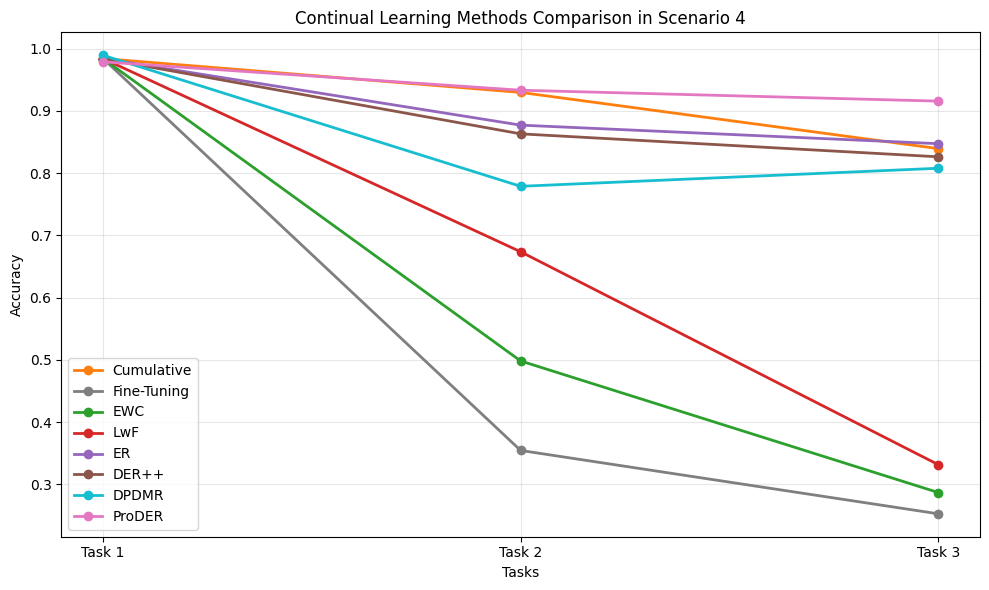

In [1]:
import matplotlib.pyplot as plt

def plot_taskwise_accuracy(
    method_accuracies,
    task_labels=None,
    title="Accuracy Across Tasks",
    colors=None
):
    plt.figure(figsize=(10, 6))

    for method, accuracies in method_accuracies.items():
        tasks = list(range(1, len(accuracies) + 1))
        color = colors[method] if colors and method in colors else None

        plt.plot(
            tasks,
            accuracies,
            marker='o',
            linewidth=2,
            label=method,
            color=color
        )

    if task_labels is None:
        task_labels = [
            f"Task {i}"
            for i in range(
                1,
                len(next(iter(method_accuracies.values()))) + 1
            )
        ]

    plt.xlabel("Tasks")
    plt.ylabel("Accuracy")
    plt.title(title)

    plt.xticks(
        ticks=range(1, len(task_labels) + 1),
        labels=task_labels
    )

    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(
        "sc4_accuracy.pdf",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()


# ============================================================
# Scenario 4 — Task-wise Accuracy
# ============================================================

method_accuracies = {

    "Cumulative": [
        0.9842,
        0.9298,
        0.8395
    ],

    "Fine-Tuning": [
        0.9842,
        0.3544,
        0.2526
    ],

    "EWC": [
        0.9842,
        0.4982,
        0.2868
    ],

    "LwF": [
        0.9842,
        0.6737,
        0.3316
    ],

    "ER": [
        0.9842,
        0.8772,
        0.8474
    ],

    "DER++": [
        0.9842,
        0.8632,
        0.8263
    ],

    "DPDMR": [
        0.9895,
        0.7789,
        0.8079
    ],

    "ProDER": [
        0.9789,
        0.9333,
        0.9158
    ]
}


task_labels = [
    "Task 1",
    "Task 2",
    "Task 3"
]


colors = {
    "Cumulative": "#ff7f0e",
    "Fine-Tuning": "#7f7f7f",
    "EWC": "#2ca02c",
    "LwF": "#d62728",
    "ER": "#9467bd",
    "DER++": "#8c564b",
    "DPDMR": "#17becf",
    "ProDER": "#e377c2"
}


plot_taskwise_accuracy(
    method_accuracies,
    task_labels=task_labels,
    title="Continual Learning Methods Comparison in Scenario 4",
    colors=colors
)

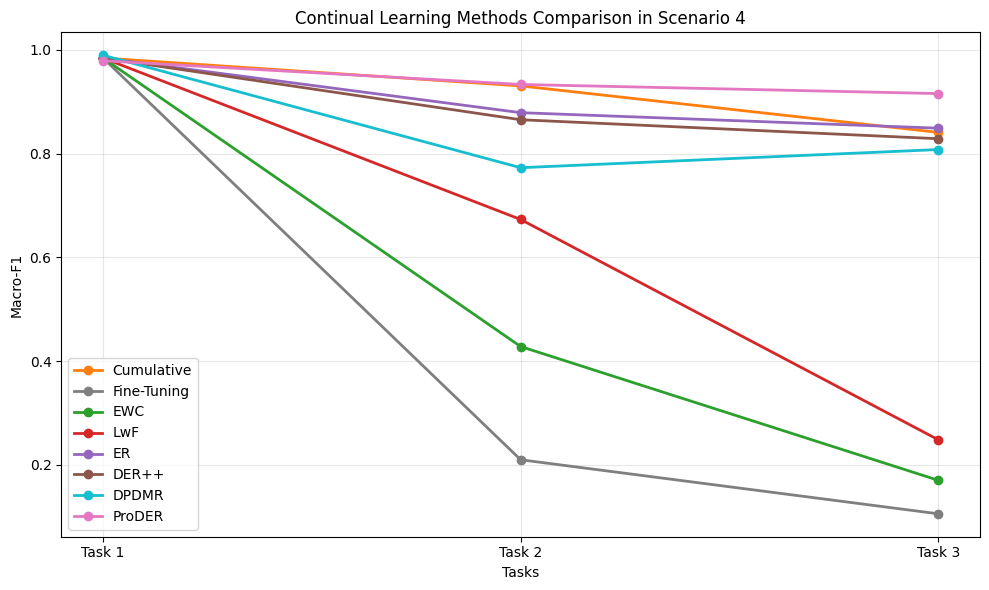

In [2]:
import matplotlib.pyplot as plt

def plot_taskwise_macro_f1(
    method_f1,
    task_labels=None,
    title="Macro-F1 Across Tasks",
    colors=None
):
    plt.figure(figsize=(10, 6))

    for method, values in method_f1.items():
        tasks = list(range(1, len(values) + 1))
        color = colors[method] if colors and method in colors else None

        plt.plot(
            tasks,
            values,
            marker='o',
            linewidth=2,
            label=method,
            color=color
        )

    if task_labels is None:
        task_labels = [
            f"Task {i}"
            for i in range(
                1,
                len(next(iter(method_f1.values()))) + 1
            )
        ]

    plt.xlabel("Tasks")
    plt.ylabel("Macro-F1")
    plt.title(title)

    plt.xticks(
        ticks=range(1, len(task_labels) + 1),
        labels=task_labels
    )

    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(
        "sc4_macro_f1.pdf",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()


# ============================================================
# Scenario 4 — Task-wise Macro-F1
# ============================================================

method_f1 = {

    "Cumulative": [
        0.9842,
        0.9304,
        0.8408
    ],

    "Fine-Tuning": [
        0.9842,
        0.2096,
        0.1054
    ],

    "EWC": [
        0.9842,
        0.4279,
        0.1700
    ],

    "LwF": [
        0.9842,
        0.6729,
        0.2482
    ],

    "ER": [
        0.9842,
        0.8788,
        0.8489
    ],

    "DER++": [
        0.9842,
        0.8652,
        0.8286
    ],

    "DPDMR": [
        0.9895,
        0.7727,
        0.8077
    ],

    "ProDER": [
        0.9789,
        0.9332,
        0.9156
    ]
}


task_labels = [
    "Task 1",
    "Task 2",
    "Task 3"
]


colors = {
    "Cumulative": "#ff7f0e",
    "Fine-Tuning": "#7f7f7f",
    "EWC": "#2ca02c",
    "LwF": "#d62728",
    "ER": "#9467bd",
    "DER++": "#8c564b",
    "DPDMR": "#17becf",
    "ProDER": "#e377c2"
}


plot_taskwise_macro_f1(
    method_f1,
    task_labels=task_labels,
    title="Continual Learning Methods Comparison in Scenario 4",
    colors=colors
)